## Project Overview

This project presents a comprehensive analysis of a large-scale e-commerce transaction dataset, with the goal of turning raw transactional data into meaningful business insights. The analysis explores key areas of e-commerce performance, including sales trends, customer behavior, product performance, payment methods, discounts, refunds, retention, and revenue concentration.

The dataset contains **584,524 transaction records**, representing **408,785 unique orders** and **115,326 customers**, covering transactions from **July 2016 to August 2018**.

The project begins with a structured data-cleaning and validation process to improve data quality and ensure the reliability of subsequent analysis. This includes handling missing values, validating data types, checking duplicate records, verifying order-level consistency, and identifying potential data-quality issues without removing legitimate business transactions.

Following the data-preparation stage, exploratory data analysis is used to uncover patterns in customer purchasing behavior, sales performance, product revenue, refund activity, payment preferences, customer retention, and other important business metrics.

The overall objective is not only to describe the dataset, but to understand **what the data reveals about the business**. The findings provide a data-driven perspective on customer value, revenue concentration, retention opportunities, refund behavior, product performance, and sales trends, creating a practical foundation for business decision-making.


# 1. Data Preparation and Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

print("All Data Analysis Libraries are Working!")

All Data Analysis Libraries are Working!


#First, we check whether all required libraries are working properly.

In [2]:
import pandas as pd

# Original dataset load kar rahe hain
df = pd.read_csv("../DATA/raw/NEW_DATA.csv")


print("Original Dataset Loaded:", df.shape)


C:\Users\123\AppData\Local\Temp\ipykernel_7952\4269266750.py:4: DtypeWarning: Columns (7: increment_id, 10: discount_amount) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../DATA/raw/NEW_DATA.csv")


Original Dataset Loaded: (584524, 21)


# Since our datasets are stored in CSV files, we use Pandas to load file into our project.

In [3]:
print("ORIGINAL DATASET:")
display(df.head())

ORIGINAL DATASET:


,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID
0,211131,complete,7/1/2016,kreations_YI 06-L,1950.0,1,1950.0,100147443,Women's Fashion,\N,...,cod,7/1/2016,#REF!,"1,950",2016,7,2016-7,Jul-16,FY17,1.0
1,211133,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1,240.0,100147444,Beauty & Grooming,\N,...,cod,7/1/2016,Gross,240,2016,7,2016-7,Jul-16,FY17,2.0
2,211134,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1,2450.0,100147445,Women's Fashion,\N,...,cod,7/1/2016,Gross,"2,450",2016,7,2016-7,Jul-16,FY17,3.0
3,211135,complete,7/1/2016,kcc_krone deal,360.0,1,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,cod,7/1/2016,Net,360,2016,7,2016-7,Jul-16,FY17,4.0
4,211136,order_refunded,7/1/2016,BK7010400AG,555.0,2,1110.0,100147447,Soghaat,\N,...,cod,7/1/2016,Valid,"1,110",2016,7,2016-7,Jul-16,FY17,5.0


# We use this command to display the first five rows of both datasets and understand their basic structure.

In [4]:

print(df.columns.tolist())

['item_id', 'status', 'created_at', 'sku', 'price', 'qty_ordered', 'grand_total', 'increment_id', 'category_name_1', 'sales_commission_code', 'discount_amount', 'payment_method', 'Working Date', 'BI Status', ' MV ', 'Year', 'Month', 'Customer Since', 'M-Y', 'FY', 'Customer ID']


# Display all column names of the dataset

In [5]:
# Dataset ki complete structure aur data types check kar rahe hain
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 584524 entries, 0 to 584523
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  int64  
 1   status                 584509 non-null  str    
 2   created_at             584524 non-null  str    
 3   sku                    584504 non-null  str    
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  int64  
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  object 
 8   category_name_1        584360 non-null  str    
 9   sales_commission_code  447346 non-null  str    
 10  discount_amount        584524 non-null  object 
 11  payment_method         584524 non-null  str    
 12  Working Date           584524 non-null  str    
 13  BI Status              584524 non-null  str    
 14   MV                    584524 non-null  str    

# Dataset ki complete structure aur data types check kar rahe hain

In [6]:
# Har column mein missing values ki total quantity check kar rahe hain
missing_values = df.isnull().sum()

print(missing_values)

item_id                       0
status                       15
created_at                    0
sku                          20
price                         0
qty_ordered                   0
grand_total                   0
increment_id                  0
category_name_1             164
sales_commission_code    137178
discount_amount               0
payment_method                0
Working Date                  0
BI Status                     0
 MV                           0
Year                          0
Month                         0
Customer Since               11
M-Y                           0
FY                            0
Customer ID                  11
dtype: int64


# Har column mein missing values ki total quantity check kar rahe hain

In [7]:
# Har column mein missing values ka percentage calculate kar rahe hain
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

item_id                   0.000000
status                    0.002566
created_at                0.000000
sku                       0.003422
price                     0.000000
qty_ordered               0.000000
grand_total               0.000000
increment_id              0.000000
category_name_1           0.028057
sales_commission_code    23.468326
discount_amount           0.000000
payment_method            0.000000
Working Date              0.000000
BI Status                 0.000000
 MV                       0.000000
Year                      0.000000
Month                     0.000000
Customer Since            0.001882
M-Y                       0.000000
FY                        0.000000
Customer ID               0.001882
dtype: float64


# Har column mein missing values ka percentage calculate kar rahe hain

In [8]:
# sales_commission_code mein unique values aur missing representation check kar rahe hain
df["sales_commission_code"].value_counts(dropna=False).head(20)

sales_commission_code
\N              339001
NaN             137178
40968             2710
C-LHW-50074       2434
C-RWP-31924       1720
cisb30211         1613
R-GUJ-105814      1446
CMUX33202         1444
R-Guj-51944       1395
C-LHC-30667       1350
C-MUX-33202       1329
C-HDD-45297       1328
R SKZ 106980      1230
c-lhc-30667       1159
C-PEW-31067       1113
R-MUX-104361      1092
R-FSD-52352       1074
R-GUJ-106946      1022
R-PEW-104414      1006
C-KHE-41912        974
Name: count, dtype: int64

# sales_commission_code mein unique values aur missing representation check kar rahe hain

In [9]:
# Dataset mein "\N" ko check kar rahe hain,
# taake pata chale ke ye missing-value representation sirf
# sales_commission_code mein hai ya doosre columns mein bhi use ho rahi hai.

for column in df.columns:
    count = (df[column] == r"\N").sum()
    
    if count > 0:
        print(f"{column}: {count}")

status: 4
category_name_1: 7850
sales_commission_code: 339001


# Dataset mein "\N" ko check kar rahe hain,
# taake pata chale ke ye missing-value representation sirf
# sales_commission_code mein hai ya doosre columns mein bhi use ho rahi hai.

In [10]:
# Important categorical columns ki unique values check kar rahe hain
# taake unusual, invalid ya placeholder values identify ki ja saken.

for column in ["status", "category_name_1", "BI Status", "payment_method"]:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False).head(20))


--- status ---
status
complete          233685
canceled          201249
received           77290
order_refunded     59529
refund              8050
cod                 2859
paid                1159
closed               494
payment_review        57
pending               48
processing            33
holded                31
NaN                   15
fraud                 10
pending_paypal         7
exchange               4
\N                     4
Name: count, dtype: int64

--- category_name_1 ---
category_name_1
Mobiles & Tablets     115710
Men's Fashion          92221
Women's Fashion        59721
Appliances             52413
Superstore             43613
Beauty & Grooming      41496
Soghaat                34011
Others                 29218
Home & Living          26504
Entertainment          26326
Health & Sports        17502
Kids & Baby            16494
Computing              15933
\N                      7850
School & Education      3478
Books                   1870
NaN                  

In [11]:
# BI Status ki values check kar rahe hain
# taake invalid ya placeholder values identify ki ja saken.

df["BI Status"].value_counts(dropna=False)

BI Status
Net      234178
Gross    201454
Valid    148891
#REF!         1
Name: count, dtype: int64

In [12]:
# BI Status mein #REF! wali exact row identify kar rahe hain
df[df["BI Status"] == "#REF!"].T

,0
item_id,211131
status,complete
created_at,7/1/2016
sku,kreations_YI 06-L
price,1950.0
qty_ordered,1
grand_total,1950.0
increment_id,100147443
category_name_1,Women's Fashion
sales_commission_code,\N


In [13]:
# Complete duplicate rows check kar rahe hain
duplicate_rows = df.duplicated().sum()

print("Complete Duplicate Rows:", duplicate_rows)

Complete Duplicate Rows: 0


In [14]:
# Order ID (increment_id) mein duplicate values check kar rahe hain
duplicate_order_ids = df["increment_id"].duplicated().sum()

print("Duplicate Order IDs:", duplicate_order_ids)

Duplicate Order IDs: 175739


In [15]:
# We count how many rows belong to each Order ID
order_id_counts = df["increment_id"].value_counts()

# Display the Order IDs that appear most frequently
print(order_id_counts.head(10))

increment_id
100266667    72
100286851    47
100346364    45
100476608    43
100535753    41
100299466    40
100535739    40
100535744    40
100535749    40
100333210    39
Name: count, dtype: int64


In [16]:
# We inspect all records belonging to the most repeated Order ID
df[df["increment_id"] == "100266667"].T

,148856,148857,148858,148859,148860,148861,148862,148863,148864,148865,...,148918,148919,148920,148921,148922,148923,148924,148925,148926,148927
item_id,398812,398813,398814,398815,398816,398817,398818,398819,398820,398821,...,398876,398877,398878,398879,398881,398882,398883,398884,398885,398886
status,complete,complete,complete,complete,complete,complete,complete,complete,complete,complete,...,complete,complete,complete,complete,complete,complete,complete,complete,complete,complete
created_at,2/6/2017,2/6/2017,2/6/2017,2/6/2017,2/6/2017,2/6/2017,2/6/2017,2/6/2017,2/6/2017,2/6/2017,...,2/6/2017,2/6/2017,2/6/2017,2/6/2017,2/6/2017,2/6/2017,2/6/2017,2/6/2017,2/6/2017,2/6/2017
sku,alrafa_Ajwa-Dates-400g,RS_Coconut Bites,BK1040200CF,BK1110200CF,cr_CHANA SWEET MIX SUPER-500 GM,BK1080200CF,RS_Nimcolia-5pack,PC_3P COMBED-009,PC_5P COMBED-004,Acro_Cufflink 15-B,...,shahi_Pack of 3 Shahi Dal Moong,shahi_Pack of 3 Shahi Chewra,shahi_Pack of 3 Shahi Savory Mix,mardaz_mardaz-00052-Standard Sixe,Little Big Shots_Pack of 6 Mixed,Little Big Shots_Pack of 6 Apple Kiwi and Lime,mva_Super-Punjab-Rewari-250gm,mva_Mayvaa-Rewari-250gm,edukaan_5023,edukaan_5021
price,1285.0,140.0,175.0,175.0,235.0,144.0,435.0,450.0,1000.0,699.0,...,255.0,255.0,255.0,699.0,510.0,510.0,130.0,95.0,480.0,480.0
qty_ordered,1,1,1,1,2,1,1,1,1,1,...,1,1,1,1,1,1,4,2,2,1
grand_total,44402.0,44402.0,44402.0,44402.0,44402.0,44402.0,44402.0,44402.0,44402.0,44402.0,...,44402.0,44402.0,44402.0,44402.0,44402.0,44402.0,44402.0,44402.0,44402.0,44402.0
increment_id,100266667,100266667,100266667,100266667,100266667,100266667,100266667,100266667,100266667,100266667,...,100266667,100266667,100266667,100266667,100266667,100266667,100266667,100266667,100266667,100266667
category_name_1,Soghaat,Soghaat,Soghaat,Soghaat,Soghaat,Soghaat,Soghaat,Men's Fashion,Men's Fashion,Men's Fashion,...,Soghaat,Soghaat,Soghaat,Women's Fashion,Superstore,Superstore,Soghaat,Soghaat,Home & Living,Home & Living
sales_commission_code,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [17]:
# We check whether any item ID appears more than once
duplicate_item_ids = df["item_id"].duplicated().sum()

print("Duplicate Item IDs:", duplicate_item_ids)

Duplicate Item IDs: 0


In [18]:
# We count the special "\N" value in every column
backslash_n_counts = (df == r"\N").sum()

# Display only columns where "\N" exists
print(backslash_n_counts[backslash_n_counts > 0])

status                        4
category_name_1            7850
sales_commission_code    339001
dtype: int64


In [19]:
# We compare the missing representations in sales_commission_code
print(df["sales_commission_code"].value_counts(dropna=False).head(5))

sales_commission_code
\N             339001
NaN            137178
40968            2710
C-LHW-50074      2434
C-RWP-31924      1720
Name: count, dtype: int64


In [20]:
import numpy as np

# Convert the special "\N" value into a standard missing value
df = df.replace(r"\N", np.nan)

# Check the missing values after replacement
print(df[["status", "category_name_1", "sales_commission_code"]].isnull().sum())

status                       19
category_name_1            8014
sales_commission_code    476179
dtype: int64


In [21]:
# We inspect the unique value patterns in discount_amount
print(df["discount_amount"].value_counts(dropna=False).head(15))

discount_amount
0.0       346934
0          29371
1000.0      5364
2000.0      4141
500.0       3525
200.0       3441
3000.0      2361
7000.0      2289
1500.0      1625
4000.0      1429
2200.0      1409
50.0        1369
100.0       1356
111.0       1254
2030.0      1204
Name: count, dtype: int64


In [22]:
# Convert discount_amount into a numeric column
df["discount_amount"] = pd.to_numeric(df["discount_amount"], errors="coerce")

# Check the new data type
print("discount_amount dtype:", df["discount_amount"].dtype)

discount_amount dtype: float64


In [23]:
# We inspect the MV column to understand its current values
print(df[" MV "].head(10))
print("\nData Type:", df[" MV "].dtype)

0     1,950
1       240
2     2,450
3       360
4     1,110
5        80
6       360
7       170
8    96,499
9    96,499
Name:  MV , dtype: str

Data Type: str


In [24]:
# Remove commas from MV values and convert the column to numeric
df[" MV "] = pd.to_numeric(
    df[" MV "].str.replace(",", "", regex=False),
    errors="coerce"
)

# Check the new data type
print("MV dtype:", df[" MV "].dtype)

MV dtype: float64


In [25]:
# Convert created_at from text into a proper datetime column
df["created_at"] = pd.to_datetime(
    df["created_at"],
    errors="coerce"
)

# Check the new data type
print("created_at dtype:", df["created_at"].dtype)

created_at dtype: datetime64[us]


In [26]:
# Convert Working Date from text into a proper datetime column
df["Working Date"] = pd.to_datetime(
    df["Working Date"],
    errors="coerce"
)

# Check the new data type
print("Working Date dtype:", df["Working Date"].dtype)

Working Date dtype: datetime64[us]


In [27]:
# We inspect Customer Since to understand its year-month format
print(df["Customer Since"].value_counts(dropna=False).head(15))

Customer Since
2016-11    82714
2017-11    70785
2016-7     57069
2016-9     46746
2017-5     35356
2018-3     32052
2018-2     23989
2016-8     21051
2017-8     19088
2017-3     18234
2016-10    17546
2017-4     16826
2018-5     16076
2017-6     15593
2017-10    14618
Name: count, dtype: int64


In [28]:
# Convert Customer Since into a monthly period
df["Customer Since"] = pd.to_datetime(
    df["Customer Since"],
    format="%Y-%m",
    errors="coerce"
).dt.to_period("M")

# Check the new data type
print("Customer Since dtype:", df["Customer Since"].dtype)

Customer Since dtype: period[M]


In [29]:
# Check the most frequent Customer ID values, including missing values
# This helps us understand the distribution of customer IDs
# and identify whether missing Customer IDs are present
print(df["Customer ID"].value_counts(dropna=False).head(10))

# Check the current data type of Customer ID
print("\nData Type:", df["Customer ID"].dtype)

Customer ID
85775.0    2524
163.0      2349
35.0       1877
33.0       1397
31025.0    1369
806.0      1310
1404.0     1269
767.0      1234
820.0      1190
58.0       1182
Name: count, dtype: int64

Data Type: float64


In [30]:
# Convert Customer ID from float to nullable integer
# Nullable integer allows us to keep missing Customer IDs as <NA>
df["Customer ID"] = df["Customer ID"].astype("Int64")

# Check the updated data type
print("Customer ID dtype:", df["Customer ID"].dtype)

# Check missing Customer IDs after conversion
print("Missing Customer IDs:", df["Customer ID"].isnull().sum())

Customer ID dtype: Int64
Missing Customer IDs: 11


In [31]:
# Check the unique values and frequency of each BI Status
# This helps us identify valid categories and any invalid values
print(df["BI Status"].value_counts(dropna=False))

BI Status
Net      234178
Gross    201454
Valid    148891
#REF!         1
Name: count, dtype: int64


In [32]:
# Replace the invalid #REF! value with NaN
# We do not assign it to another BI Status category because
# its correct business classification is unknown
df["BI Status"] = df["BI Status"].replace("#REF!", np.nan)

# Check the missing values after replacement
print("Missing BI Status:", df["BI Status"].isnull().sum())

Missing BI Status: 1


In [33]:
# Check the frequency of each order status, including missing values
# This helps us understand the available order-status categories
# and identify any remaining missing values
print(df["status"].value_counts(dropna=False))

status
complete          233685
canceled          201249
received           77290
order_refunded     59529
refund              8050
cod                 2859
paid                1159
closed               494
payment_review        57
pending               48
processing            33
holded                31
NaN                   19
fraud                 10
pending_paypal         7
exchange               4
Name: count, dtype: int64


In [34]:
# Select rows where order status is missing
# This helps us inspect the affected records before deciding
# how to handle the missing status values
missing_status = df[df["status"].isna()]

# Display the missing-status records
print(missing_status)

        item_id status created_at                              sku    price  \
255520   526623    NaN 2017-07-03                   test-product-3      3.0   
255521   526624    NaN 2017-07-03                     test-product     75.0   
255624   526754    NaN 2017-07-03                   test-product-3      3.0   
255625   526755    NaN 2017-07-03                     test-product     75.0   
477519   783751    NaN 2018-03-15              OTHPCB5A7D8A0BD10E8   8000.0   
513736   827187    NaN 2018-04-16           KABOXF5ABCC75C7E2F7-32    370.0   
513737   827189    NaN 2018-04-16  KABSHO5AA77C331466F-11-13 Years    473.0   
513738   827191    NaN 2018-04-16    KABBIN5A93E074C501A-8-9 Years    749.0   
513739   827193    NaN 2018-04-16  KABLIT59AC117FD51C4-12-13 Years    692.0   
513740   827195    NaN 2018-04-16    KABCOL5AB2B8019805C-8-9 Years    423.0   
518706   832777    NaN 2018-04-30              ENTCLI5A5DD7D800D6E   6042.0   
532965   848003    NaN 2018-05-14              MATIN

# The 19 missing status values were inspected.
# Since their correct order status cannot be reliably determined
# from the available data, we keep them as NaN instead of guessing.

In [35]:
# Check missing SKU values
# This helps us identify records where the product identifier is missing
print("Missing SKU:", df["sku"].isnull().sum())

Missing SKU: 20


In [36]:
# Select rows where SKU is missing
# This helps us inspect the affected product records
# before deciding how to handle the missing SKU values
missing_sku = df[df["sku"].isna()]

# Display the records with missing SKU
print(missing_sku)

        item_id          status created_at  sku    price  qty_ordered  \
14846    230008        canceled 2016-08-13  NaN      0.0            1   
20676    236830        canceled 2016-09-01  NaN      0.0            1   
39838    260006        canceled 2016-10-07  NaN      0.0            1   
39839    260007        canceled 2016-10-07  NaN      0.0            3   
39880    260061        canceled 2016-10-07  NaN      0.0            3   
124968   367292          refund 2016-12-10  NaN      0.0            1   
125636   368122          refund 2016-12-12  NaN      0.0            1   
125811   368362          refund 2016-12-13  NaN      0.0            1   
149597   399798          refund 2017-02-07  NaN      0.0            1   
170249   426105        canceled 2017-03-21  NaN      0.0            1   
170401   426302        canceled 2017-03-22  NaN      0.0            1   
173040   429392          refund 2017-03-23  NaN      0.0            1   
173045   429393          refund 2017-03-23  NaN    

# The 20 missing SKU values were inspected.
# Since the correct product SKU cannot be reliably determined,
# we keep these values as NaN instead of guessing or deleting the records.

In [37]:
# Check the number of missing product categories
# This helps us understand how many records lack category information
print("Missing Categories:", df["category_name_1"].isnull().sum())

Missing Categories: 8014


In [38]:
# Select rows where product category is missing
# This helps us inspect whether the missing categories
# are related to specific order statuses or product records
missing_category = df[df["category_name_1"].isna()]

# Display the records with missing categories
print(missing_category)

        item_id          status created_at                    sku   price  \
24       211157  order_refunded 2016-07-01  D Lend a Helping Hand  1000.0   
72       211214        canceled 2016-07-01     sentiments_WRK1612     1.0   
79       211222        canceled 2016-07-01     sentiments_WRK1612     1.0   
80       211223        canceled 2016-07-01     sentiments_WRK1612     1.0   
81       211225        canceled 2016-07-01     sentiments_WRK1612     1.0   
...         ...             ...        ...                    ...     ...   
535572   850761        received 2018-05-16    KABASA5ABC763F62E76   506.0   
541927   857600        received 2018-05-25    WOFASA5AE962A6DD038   199.0   
549314   865823        canceled 2018-06-04  MEFQMO59B0942707B79-M    99.0   
568069   886699        canceled 2018-07-18     COMWD5AA8FF5851E73   314.0   
580564   900744        received 2018-08-15     COMWD5AA8FF5851E73   314.0   

        qty_ordered  grand_total increment_id category_name_1  \
24        

# The 8,014 missing category values were inspected.
# Missing categories occur across different order statuses and products.
# Since the correct category cannot be reliably determined,
# we keep these values as NaN instead of guessing or deleting the records.

In [39]:
# Check the most frequent sales commission codes, including missing values
# This helps us understand the available commission codes
# and the proportion of missing commission information
print(df["sales_commission_code"].value_counts(dropna=False).head(15))

sales_commission_code
NaN             476179
40968             2710
C-LHW-50074       2434
C-RWP-31924       1720
cisb30211         1613
R-GUJ-105814      1446
CMUX33202         1444
R-Guj-51944       1395
C-LHC-30667       1350
C-MUX-33202       1329
C-HDD-45297       1328
R SKZ 106980      1230
c-lhc-30667       1159
C-PEW-31067       1113
R-MUX-104361      1092
Name: count, dtype: int64


In [40]:
# Compare missing and available commission codes by order status
# This helps us understand whether missing commission codes
# are associated with particular order statuses
print(
    df.groupby(
        df["sales_commission_code"].isna()
    )["status"].value_counts()
)

sales_commission_code  status        
False                  complete           56903
                       canceled           21871
                       order_refunded     14619
                       received           12940
                       refund              1392
                       cod                  390
                       paid                 104
                       closed                86
                       payment_review        26
                       pending                9
                       pending_paypal         3
                       processing             2
True                   canceled          179378
                       complete          176782
                       received           64350
                       order_refunded     44910
                       refund              6658
                       cod                 2469
                       paid                1055
                       closed               408
  

# The missing commission codes occur across multiple order statuses.
# Since their original commission codes cannot be reliably determined,
# we keep the missing values as NaN instead of guessing or deleting rows.

In [41]:
# 1-step
# Check for negative values in important numerical columns
# Negative values may indicate data-entry errors or unusual transactions
numeric_columns = [
    "price",
    "qty_ordered",
    "grand_total",
    "discount_amount",
    " MV "
]

for column in numeric_columns:
    print(f"{column}: {(df[column] < 0).sum()} negative values")

price: 0 negative values
qty_ordered: 0 negative values
grand_total: 76 negative values
discount_amount: 3 negative values
 MV : 0 negative values


In [42]:
#2-step
# Select records where grand_total is negative
# This helps us understand whether negative totals
# represent refunds/adjustments or possible data errors
negative_grand_total = df[df["grand_total"] < 0]

# Display the negative grand_total records
print(negative_grand_total)

        item_id    status created_at                       sku   price  \
209940   473144  complete 2017-05-19           lalassc_SSP-07A  1200.0   
242331   510950  received 2017-06-12         SN_Muzadati-500gm   170.0   
242332   510951  received 2017-06-12  Nimcos_Namak-Paray-200gm    98.0   
242333   510952  received 2017-06-12  Nimcos_Crunchy-Mix-400gm   216.0   
242334   510953  received 2017-06-12     RS_Sohan Halwa 1000gm   660.0   
...         ...       ...        ...                       ...     ...   
571270   890219  complete 2018-07-27     MEFOXF5B39EF5CC541E-M   420.0   
571271   890221  complete 2018-07-27          VIT5AC4A6E65D6C6   180.0   
571272   890222  complete 2018-07-27          HIJ5B2204D154E0F   450.0   
571273   890223  complete 2018-07-27       HASQAR5A53699375950    98.0   
571274   890224  complete 2018-07-27       SOGALM5A8BD55B70D5F   475.0   

        qty_ordered  grand_total increment_id  category_name_1  \
209940            1        -10.0    100306233

# The negative grand_total records were inspected.
# Negative totals appear in multiple order items and can represent
# order-level adjustments or other valid transaction effects.
# Since their exact business meaning cannot be confirmed from the dataset,
# we keep these values unchanged instead of deleting or replacing them.

In [43]:
# Select records where discount amount is negative
# This helps us determine whether negative discounts are valid
# adjustments or possible data-quality issues
negative_discount = df[df["discount_amount"] < 0]

# Display the negative discount records
print(negative_discount)

        item_id          status created_at                 sku   price  \
152474   403716        canceled 2017-02-13      akl-GFSU1265-M  5995.0   
152478   403730  order_refunded 2017-02-13        test-product     4.0   
152479   403731        canceled 2017-02-13  RB_HouseholdBundle  1000.0   

        qty_ordered  grand_total increment_id  category_name_1  \
152474            1       5395.5    100269243  Women's Fashion   
152478            2        156.0    100269252              NaN   
152479            5       4998.0    100269253       Superstore   

       sales_commission_code  ...  payment_method Working Date BI Status  \
152474                   NaN  ...         Payaxis   2017-02-13     Gross   
152478                   NaN  ...         Payaxis   2017-02-13     Valid   
152479                   NaN  ...         Payaxis   2017-02-13     Gross   

           MV   Year  Month  Customer Since     M-Y    FY Customer ID  
152474  5995.0  2017      2         2016-07  Feb-17  FY17    

In [44]:
# Check the number of zero values in important numerical columns
# This helps identify values that may require further investigation
# because zero can sometimes represent missing or invalid information

for column in numeric_columns:
    print(f"{column}: {(df[column] == 0).sum()} zero values")

price: 2232 zero values
qty_ordered: 0 zero values
grand_total: 9632 zero values
discount_amount: 376305 zero values
 MV : 40 zero values


In [45]:
# Select records where product price is zero
# This helps us determine whether zero prices represent
# canceled/refunded/test transactions or possible data errors
zero_price = df[df["price"] == 0]

# Display the zero-price records
print(zero_price)

        item_id    status created_at  \
6598     218538  canceled 2016-07-26   
6603     218542  canceled 2016-07-26   
7004     218988  canceled 2016-07-27   
8298     220494  canceled 2016-07-29   
8333     220540  canceled 2016-07-29   
...         ...       ...        ...   
584260   904901       cod 2018-08-27   
584261   904902       cod 2018-08-27   
584264   904906       cod 2018-08-27   
584270   904916       cod 2018-08-27   
584271   904917       cod 2018-08-27   

                                                      sku  price  qty_ordered  \
6598    west point_Deluxe Juicer, Blender & Grinder - ...    0.0            1   
6603    west point_Deluxe Juicer, Blender & Grinder - ...    0.0            1   
7004    west point_Deluxe Juicer, Blender & Grinder - ...    0.0            1   
8298                                         stinnos_1301    0.0            1   
8333                                         stinnos_1301    0.0           10   
...                              

# The zero-price records were inspected.
# Zero prices occur across different order statuses and products.
# Since the exact business reason for zero pricing cannot be confirmed,
# we keep these values unchanged instead of replacing or deleting them.

In [46]:
# Select records where grand total is zero
# This helps us determine whether zero totals are associated
# with canceled, refunded, test, or other transactions
zero_grand_total = df[df["grand_total"] == 0]

# Display the zero-grand-total records
print(zero_grand_total)

        item_id          status created_at                        sku  \
14       211146        complete 2016-07-01           kcc_glamour deal   
24       211157  order_refunded 2016-07-01      D Lend a Helping Hand   
27       211162        complete 2016-07-01            SKMT_Blood Test   
28       211163        complete 2016-07-01              SKMT_Medicine   
266      211422        complete 2016-07-01  sstop_3dcreenwithspeakers   
...         ...             ...        ...                        ...   
584263   904904            paid 2018-08-27      MEFRED5B445E6B94853-S   
584368   905028            paid 2018-08-27        ENTECO5A7FE80D6C830   
584405   905080            paid 2018-08-27      MEFC-T5A79B6E8346D9-M   
584514   905196            paid 2018-08-28     MEFGUL5A9F882AA5B99-36   
584515   905198            paid 2018-08-28        MEFPAK5B360B03C6B72   

          price  qty_ordered  grand_total increment_id    category_name_1  \
14        320.0            1          0.0    1

# The zero grand_total records were inspected.
# Zero totals occur across different order statuses and products,
# including complete and paid records.
# Since the exact business reason cannot be confirmed,
# we keep these values unchanged instead of replacing or deleting them.





In [47]:
# Select records where MV is zero
# This helps us determine whether zero MV values represent
# valid transactions or possible missing/incorrect values
zero_mv = df[df[" MV "] == 0]

# Display the zero-MV records
print(zero_mv)

        item_id          status created_at  \
3735     215353        complete 2016-07-16   
470770   775912  order_refunded 2018-03-08   
470926   776101        received 2018-03-08   
470988   776184        received 2018-03-08   
471001   776197  order_refunded 2018-03-08   
471007   776203  order_refunded 2018-03-08   
471024   776220  order_refunded 2018-03-08   
471031   776228  order_refunded 2018-03-08   
471036   776233  order_refunded 2018-03-08   
471041   776238  order_refunded 2018-03-08   
471261   776510  order_refunded 2018-03-08   
471328   776589  order_refunded 2018-03-08   
471331   776592  order_refunded 2018-03-08   
471342   776603  order_refunded 2018-03-08   
471666   776978  order_refunded 2018-03-09   
471673   776986  order_refunded 2018-03-09   
471754   777077  order_refunded 2018-03-09   
483276   789907  order_refunded 2018-03-17   
483638   790353  order_refunded 2018-03-17   
483652   790375  order_refunded 2018-03-17   
483654   790377  order_refunded 20

# The zero MV records were inspected.
# Zero MV values occur across different order statuses,
# including complete, received, and order-refunded transactions.
# Since the exact business meaning of MV cannot be confirmed,
# we keep these values unchanged instead of replacing or deleting them.



<!-- data validation of numeric columns has been started ok from down -->

In [48]:
# Check missing values in date-related columns
date_columns = ["created_at", "Working Date", "Customer Since"]

for column in date_columns:
    print(f"{column}: {df[column].isna().sum()} missing values")

created_at: 0 missing values
Working Date: 0 missing values
Customer Since: 11 missing values


In [49]:
# Check the original-looking values of Working Date
print(df["Working Date"].head(10))
print("\nData Type:", df["Working Date"].dtype)

0   2016-07-01
1   2016-07-01
2   2016-07-01
3   2016-07-01
4   2016-07-01
5   2016-07-01
6   2016-07-01
7   2016-07-01
8   2016-07-01
9   2016-07-01
Name: Working Date, dtype: datetime64[us]

Data Type: datetime64[us]


In [50]:
# Reload only the original Working Date column
original_dates = pd.read_csv(
    "../DATA/raw/NEW_DATA.csv",
    usecols=["Working Date"]
)

print(original_dates["Working Date"].head(10))
print("\nData Type:", original_dates["Working Date"].dtype)

0    7/1/2016
1    7/1/2016
2    7/1/2016
3    7/1/2016
4    7/1/2016
5    7/1/2016
6    7/1/2016
7    7/1/2016
8    7/1/2016
9    7/1/2016
Name: Working Date, dtype: str

Data Type: str


In [51]:
# Restore Working Date from the original CSV
df["Working Date"] = pd.to_datetime(
    original_dates["Working Date"],
    format="%m/%d/%Y",
    errors="coerce"
)

print(df["Working Date"].head(10))
print("\nData Type:", df["Working Date"].dtype)
print("Missing Working Date:", df["Working Date"].isna().sum())

0   2016-07-01
1   2016-07-01
2   2016-07-01
3   2016-07-01
4   2016-07-01
5   2016-07-01
6   2016-07-01
7   2016-07-01
8   2016-07-01
9   2016-07-01
Name: Working Date, dtype: datetime64[us]

Data Type: datetime64[us]
Missing Working Date: 0


In [52]:
# Inspect records with missing Customer Since
missing_customer_since = df[df["Customer Since"].isna()]

print(missing_customer_since[
    ["item_id", "increment_id", "created_at", "Customer ID", "Customer Since"]
])

        item_id increment_id created_at  Customer ID Customer Since
427377   726862    100443451 2018-01-05         <NA>            NaT
427378   726863    100443451 2018-01-05         <NA>            NaT
427379   726864    100443451 2018-01-05         <NA>            NaT
437567   738191    100449683 2018-01-31         <NA>            NaT
478699   784981    100480546 2018-03-15         <NA>            NaT
478779   785061    100480623 2018-03-15         <NA>            NaT
494278   804621    100496269 2018-03-27         <NA>            NaT
495340   805750    100497359 2018-03-27         <NA>            NaT
495945   807010    100498582 2018-03-27         <NA>            NaT
496921   808287    100499821 2018-03-27         <NA>            NaT
502446   814174    100505460 2018-03-28         <NA>            NaT


# The 11 missing Customer Since values were inspected.
# Customer ID is also missing for these records, so the original
# customer start period cannot be reliably determined.
# Therefore, the missing values are retained as NaT instead of guessing.

<!-- the validation of numeric columns has been endeed -->

<!-- the validation of categorical/text columns validation columns has been started from down -->

In [53]:
# Check unique values and missing values in categorical columns
categorical_columns = [
    "status",
    "sku",
    "category_name_1",
    "sales_commission_code",
    "payment_method",
    "BI Status",
    "M-Y",
    "FY"
]

for column in categorical_columns:
    print(f"\n{'='*60}")
    print(f"Column: {column}")
    print(f"Missing: {df[column].isna().sum()}")
    print(f"Unique Values: {df[column].nunique(dropna=True)}")
    print(df[column].dropna().astype(str).str.strip().value_counts().head(10))


Column: status
Missing: 19
Unique Values: 15
status
complete          233685
canceled          201249
received           77290
order_refunded     59529
refund              8050
cod                 2859
paid                1159
closed               494
payment_review        57
pending               48
Name: count, dtype: int64

Column: sku
Missing: 20
Unique Values: 84889
sku
MATSAM59DB75ADB2F80              3775
Al Muhafiz Sohan Halwa Almond    2258
emart_00-7                       2027
kcc_krone deal                   1894
infinix_Zero 4-Grey              1793
emart_00-1                       1391
MATSAM59DB757FB47A2              1273
Rubian_U8 Smart Watch            1233
unilever_Deal-6                  1213
APPNAT5A0A01860CE92              1173
Name: count, dtype: int64

Column: category_name_1
Missing: 8014
Unique Values: 15
category_name_1
Mobiles & Tablets    115710
Men's Fashion         92221
Women's Fashion       59721
Appliances            52413
Superstore            43613
Be

In [54]:
# Inspect payment method consistency
print("Missing:", df["payment_method"].isna().sum())
print("Unique Values:", df["payment_method"].nunique(dropna=True))

print("\nPayment Methods:")
print(df["payment_method"].value_counts(dropna=False))

Missing: 0
Unique Values: 18

Payment Methods:
payment_method
cod                  271960
Payaxis               97641
Easypay               82900
jazzwallet            35145
easypay_voucher       31176
bankalfalah           23065
jazzvoucher           15633
Easypay_MA            14028
customercredit         7555
apg                    1758
ublcreditcard           882
cashatdoorstep          732
mcblite                 723
mygateway               669
internetbanking         472
productcredit           125
marketingexpense         45
financesettlement        15
Name: count, dtype: int64


In [55]:
# Validate BI Status after cleaning the invalid #REF! value
print("Missing:", df["BI Status"].isna().sum())
print("Unique Values:", df["BI Status"].nunique(dropna=True))

print("\nBI Status Values:")
print(df["BI Status"].value_counts(dropna=False))

Missing: 1
Unique Values: 3

BI Status Values:
BI Status
Net      234178
Gross    201454
Valid    148891
NaN           1
Name: count, dtype: int64


# BI Status was validated after replacing the invalid #REF! value.
# The remaining single missing value is retained as NaN because
# its correct business classification cannot be reliably determined.

In [56]:
# Validate Month-Year labels
print("Missing:", df["M-Y"].isna().sum())
print("Unique Values:", df["M-Y"].nunique(dropna=True))

print("\nM-Y Values:")
print(df["M-Y"].value_counts().sort_index())

Missing: 0
Unique Values: 26

M-Y Values:
M-Y
Apr-17    21678
Apr-18    12413
Aug-16    11535
Aug-17    25083
Aug-18    11896
Dec-16    13452
Dec-17    15747
Feb-17    11861
Feb-18    26916
Jan-17    13195
Jan-18    12872
Jul-16     8837
Jul-17    19275
Jul-18    11039
Jun-17    19793
Jun-18    14737
Mar-17    19534
Mar-18    41955
May-17    34736
May-18    27867
Nov-16    71528
Nov-17    83928
Oct-16    13124
Oct-17    17499
Sep-16    15433
Sep-17     8591
Name: count, dtype: int64


In [57]:
# Validate Financial Year labels
print("Missing:", df["FY"].isna().sum())
print("Unique Values:", df["FY"].nunique(dropna=True))

print("\nFinancial Year Values:")
print(df["FY"].value_counts(dropna=False).sort_index())

Missing: 0
Unique Values: 3

Financial Year Values:
FY
FY17    254706
FY18    306883
FY19     22935
Name: count, dtype: int64


In [58]:
#The missing values in the Category column are already known (8,014). Now, we 
# will check whether the category names contain any **leading/trailing spaces or 
# formatting inconsistencies.
# Check category name formatting consistency
category_check = df["category_name_1"].dropna().astype(str)

print("Missing:", df["category_name_1"].isna().sum())
print("Unique Values:", df["category_name_1"].nunique(dropna=True))

print("\nCategories with leading/trailing spaces:")
print(category_check[category_check != category_check.str.strip()].unique())

print("\nTop Categories:")
print(category_check.value_counts().head(20))

Missing: 8014
Unique Values: 15

Categories with leading/trailing spaces:
<ArrowStringArray>
[]
Length: 0, dtype: str

Top Categories:
category_name_1
Mobiles & Tablets     115710
Men's Fashion          92221
Women's Fashion        59721
Appliances             52413
Superstore             43613
Beauty & Grooming      41496
Soghaat                34011
Others                 29218
Home & Living          26504
Entertainment          26326
Health & Sports        17502
Kids & Baby            16494
Computing              15933
School & Education      3478
Books                   1870
Name: count, dtype: int64


In [59]:
# Check sales commission code formatting consistency
commission_check = df["sales_commission_code"].dropna().astype(str)

print("Missing:", df["sales_commission_code"].isna().sum())
print("Unique Values:", df["sales_commission_code"].nunique(dropna=True))

print("\nCodes with leading/trailing spaces:")
print(
    commission_check[
        commission_check != commission_check.str.strip()
    ].unique()
)

print("\nTop Commission Codes:")
print(commission_check.value_counts().head(20))

Missing: 476179
Unique Values: 7223

Codes with leading/trailing spaces:
<ArrowStringArray>
[    ' R-LHC-104412',      ' R-MUX-90516',       ' LHW 103447',
     ' C LHE 100093',     ' R-HDD-106534',      ' C SKZ 70316',
           ' r 5848',     ' R-LHE-104412',     ' R SKZ 106980',
     ' R-LHE-104418',       ' C LHE 7905',       ' LHW 104417',
     ' C-GUJ-105901',      ' C MUX 45349',      ' C-HDD-40844',
   ' USS17-LAC-025A',      ' R-KHW-50744',     ' R-GUJ-105814',
      ' C-RWP-31924',     ' R-KHS-103986',           ' PAK338',
      ' CS2O_T8U615',  ' GRS - 2884207-1',        ' CMUX33202',
      ' CA_34J2D300', ' CA-10003D54­P200',  ' CA-10005P48V200',
     ' AO28_L4W3217',       ' cisb 30211',    ' C-KHI-1-52056',
      ' Yayvo_E78U6',     ' R-KHS-107999',      ' C-KHC-41396',
      ' C-KHS-40449',      ' c lhe 41938',       ' BF5030inoa',
      ' C HDD 44781',        ' CFSD51854',      ' C-LHC-30667',
     ' BFC-17_D82AG',      ' C-SGD-43409',      ' C-HDD-45297',
     ' BBB22

In [60]:
# Remove only leading and trailing whitespace from commission codes.
# Internal spaces, hyphens, and other characters are preserved.

df["sales_commission_code"] = (
    df["sales_commission_code"]
    .str.strip()
)

print("Remaining leading/trailing space issues:")

commission_check = df["sales_commission_code"].dropna().astype(str)

print(
    (commission_check != commission_check.str.strip()).sum()
)

Remaining leading/trailing space issues:
0


In [61]:
# Check the effect of whitespace cleaning
print("Missing:", df["sales_commission_code"].isna().sum())
print("Unique Values After Cleaning:", df["sales_commission_code"].nunique(dropna=True))

Missing: 476179
Unique Values After Cleaning: 7192


In [62]:
# Check status formatting consistency
status_check = df["status"].dropna().astype(str)

print("Missing:", df["status"].isna().sum())
print("Unique Values:", df["status"].nunique(dropna=True))

print("\nValues with leading/trailing spaces:")
print(
    status_check[
        status_check != status_check.str.strip()
    ].unique()
)

print("\nStatus Values:")
print(status_check.value_counts())

Missing: 19
Unique Values: 15

Values with leading/trailing spaces:
<ArrowStringArray>
[]
Length: 0, dtype: str

Status Values:
status
complete          233685
canceled          201249
received           77290
order_refunded     59529
refund              8050
cod                 2859
paid                1159
closed               494
payment_review        57
pending               48
processing            33
holded                31
fraud                 10
pending_paypal         7
exchange               4
Name: count, dtype: int64


In [63]:
# Check SKU formatting consistency
sku_check = df["sku"].dropna().astype(str)

print("Missing:", df["sku"].isna().sum())
print("Unique Values:", df["sku"].nunique(dropna=True))

print("\nSKUs with leading/trailing spaces:")
print(
    sku_check[
        sku_check != sku_check.str.strip()
    ].unique()
)

Missing: 20
Unique Values: 84889

SKUs with leading/trailing spaces:
<ArrowStringArray>
[                'Dany_AUK-650 ',      'RS_pheni Desi Ghee 1 kg ',
                  'Dany_AUK 55 ', 'Dany_Genius Tab G7 Metallica ',
                'Trans_LW 509B ',    'b&d_Citrus Juicer CJ650   ',
             'Audionic_ LT-480 ',        'Dany_Powerbank Pb- 42 ',
          'rute2_Coenzyme Q-10 ',                  'vitamin_265 ',
 ...
            'sanaulla_SN17E 08 ',      'lamp_Lamp Shade Round 3 ',
     'OAS_SUPERDELUXE-30Gallon ',            'sanaulla_SN17E 12 ',
            'sanaulla_SN17E 04 ',            'sanaulla_TM17L 4A ',
            'sanaulla_TM17L 2A ',          'MATHUA5A9E337FE5F09 ',
          'MATNOK5A7D4F55AC6F9 ',          'APPDAW5AC26A6C4DC3F ']
Length: 471, dtype: str


In [64]:
# Remove only leading and trailing whitespace from SKU values.
# Internal spaces, hyphens, and underscores are preserved.

df["sku"] = df["sku"].str.strip()

# Verify the cleaning
sku_check = df["sku"].dropna().astype(str)

print("Remaining leading/trailing space issues:")
print(
    (sku_check != sku_check.str.strip()).sum()
)

Remaining leading/trailing space issues:
0


In [65]:
# Check the effect of SKU whitespace cleaning
print("Missing:", df["sku"].isna().sum())
print("Unique Values After Cleaning:", df["sku"].nunique(dropna=True))

Missing: 20


Unique Values After Cleaning: 84799


In [66]:
# Check for possible case inconsistencies in category names
category_check = df["category_name_1"].dropna().astype(str)

case_check = category_check.groupby(category_check.str.lower()).nunique()

print("Case-inconsistent category groups:")
print(case_check[case_check > 1])

Case-inconsistent category groups:
Series([], Name: category_name_1, dtype: int64)


In [67]:
# Check for possible case inconsistencies in order status
status_check = df["status"].dropna().astype(str)

case_check = status_check.groupby(status_check.str.lower()).nunique()

print("Case-inconsistent status groups:")
print(case_check[case_check > 1])

Case-inconsistent status groups:
Series([], Name: status, dtype: int64)


In [68]:
# Check increment_id consistency
print("Missing:", df["increment_id"].isna().sum())
print("Unique Values:", df["increment_id"].nunique(dropna=True))

print("\nData Type:")
print(df["increment_id"].dtype)

print("\nSample Values:")
print(df["increment_id"].head(10).tolist())

Missing: 0
Unique Values: 408785

Data Type:
object

Sample Values:
[100147443, 100147444, 100147445, 100147446, 100147447, 100147448, 100147449, 100147450, 100147451, 100147452]


In [69]:
# Check whether all increment IDs contain only numeric values
increment_check = df["increment_id"].astype(str).str.strip()

non_numeric = increment_check[
    ~increment_check.str.fullmatch(r"\d+")
]

print("Non-numeric increment IDs:", len(non_numeric))

if len(non_numeric) > 0:
    print("\nExamples:")
    print(non_numeric.head(20).tolist())

Non-numeric increment IDs: 9

Examples:
['100264290-1', '100264290-1', '100264290-1', '100293148-1', '100468520-1', '100542843-1', '100546199-1', '100546199-1', '100549449-1']


In [70]:
# Inspect the non-numeric increment IDs
non_numeric_rows = df[
    df["increment_id"].astype(str).str.strip().str.contains("-", regex=False)
]

print(
    non_numeric_rows[
        ["item_id", "increment_id", "status", "created_at", "grand_total", "Customer ID"]
    ]
)

        item_id increment_id    status created_at  grand_total  Customer ID
145794   394524  100264290-1  canceled 2017-01-28       2188.0        32123
145795   394525  100264290-1  canceled 2017-01-28       2188.0        32123
145796   394526  100264290-1  canceled 2017-01-28       2188.0        32123
186880   446867  100293148-1  canceled 2017-04-15        500.0        14802
463649   767619  100468520-1  canceled 2018-02-27      29349.0        92075
555489   872703  100542843-1  canceled 2018-06-18       5789.0       111166
560472   879765  100546199-1       cod 2018-07-02        810.0       111867
560473   879766  100546199-1       cod 2018-07-02        810.0       111867
565157   883358  100549449-1    closed 2018-07-10        399.0        40853


# Increment ID was inspected for non-numeric values.
# Nine IDs contain a "-1" suffix and correspond to valid order records.
# Since increment_id is an identifier, the suffix is preserved
# instead of modifying or converting the values to numeric format.

In [71]:
# Final data type audit after cleaning
print(df.dtypes)

item_id                           int64
status                              str
created_at               datetime64[us]
sku                                 str
price                           float64
qty_ordered                       int64
grand_total                     float64
increment_id                     object
category_name_1                     str
sales_commission_code               str
discount_amount                 float64
payment_method                      str
Working Date             datetime64[us]
BI Status                           str
 MV                             float64
Year                              int64
Month                             int64
Customer Since                period[M]
M-Y                                 str
FY                                  str
Customer ID                       Int64
dtype: object


In [72]:
# Check consistency between Year and Month
year_month_check = df[
    (df["Year"] != df["created_at"].dt.year) |
    (df["Month"] != df["created_at"].dt.month)
]

print("Year/Month mismatched rows:", len(year_month_check))

if len(year_month_check) > 0:
    print(year_month_check[
        ["created_at", "Year", "Month", "M-Y", "FY"]
    ].head(20))

Year/Month mismatched rows: 0


In [73]:
# Check consistency between created_at and M-Y
expected_my = df["created_at"].dt.strftime("%b-%y")

my_mismatch = df[
    df["M-Y"] != expected_my
]

print("M-Y mismatched rows:", len(my_mismatch))

if len(my_mismatch) > 0:
    print(my_mismatch[
        ["created_at", "M-Y", "Year", "Month"]
    ].head(20))

M-Y mismatched rows: 0


In [74]:
# Check Financial Year consistency against the transaction date
expected_fy = "FY" + (
    df["created_at"].dt.year + (df["created_at"].dt.month >= 7)
).astype(int).astype(str).str[-2:]

fy_mismatch = df[
    df["FY"] != expected_fy
]

print("FY mismatched rows:", len(fy_mismatch))

if len(fy_mismatch) > 0:
    print(fy_mismatch[
        ["created_at", "FY", "Year", "Month", "M-Y"]
    ].head(20))

FY mismatched rows: 0


In [75]:
# Final missing-value audit after data cleaning
missing_summary = df.isna().sum()

print(missing_summary[missing_summary > 0])

status                       19
sku                          20
category_name_1            8014
sales_commission_code    476179
discount_amount               1
BI Status                     1
 MV                        2232
Customer Since               11
Customer ID                  11
dtype: int64


In [76]:
# Inspect the single missing discount value
missing_discount = df[df["discount_amount"].isna()]

print(missing_discount.T)

                                        13
item_id                             211145
status                            complete
created_at             2016-07-01 00:00:00
sku                           kcc_Sultanat
price                                120.0
qty_ordered                              1
grand_total                          120.0
increment_id                     100147455
category_name_1              Home & Living
sales_commission_code               105259
discount_amount                        NaN
payment_method               ublcreditcard
Working Date           2016-07-01 00:00:00
BI Status                              Net
 MV                                  120.0
Year                                  2016
Month                                    7
Customer Since                     2016-07
M-Y                                 Jul-16
FY                                    FY17
Customer ID                             11


# The single missing discount_amount value was inspected.
# The transaction is otherwise complete, but the original discount
# value cannot be reliably determined from the available columns.
# Therefore, the missing value is retained as NaN instead of guessing.

In [77]:
# Inspect rows where MV is missing
missing_mv = df[df[" MV "].isna()]

print(missing_mv.shape)
print(missing_mv[[
    "item_id",
    "status",
    "created_at",
    "price",
    "qty_ordered",
    "grand_total",
    "discount_amount",
    "BI Status",
    " MV "
]].head(20))

(2232, 21)
       item_id    status created_at  price  qty_ordered  grand_total  \
6598    218538  canceled 2016-07-26    0.0            1          0.0   
6603    218542  canceled 2016-07-26    0.0            1          0.0   
7004    218988  canceled 2016-07-27    0.0            1          0.0   
8298    220494  canceled 2016-07-29    0.0            1          0.0   
8333    220540  canceled 2016-07-29    0.0           10          0.0   
8343    220552  canceled 2016-07-29    0.0            1          0.0   
8347    220557  canceled 2016-07-29    0.0            1          0.0   
8358    220568  complete 2016-07-29    0.0            2        685.0   
8419    220637  canceled 2016-07-30    0.0            1          0.0   
8710    220970  canceled 2016-07-31    0.0            1          0.0   
8771    221032  complete 2016-07-31    0.0            1         55.0   
10330   223202  canceled 2016-08-04    0.0            1          0.0   
11054   224392  complete 2016-08-05    0.0           

# The 2,232 missing MV values were inspected.
# Missing MV values occur across different order statuses and transaction
# patterns, including both canceled and completed records.
# Since the exact business meaning of MV is not confirmed, the missing
# values are retained as NaN instead of guessing or calculating them.

In [78]:
# Final dataset overview after cleaning
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isna().sum()[df.isna().sum() > 0])

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (584524, 21)

Missing Values:


status                       19
sku                          20
category_name_1            8014
sales_commission_code    476179
discount_amount               1
BI Status                     1
 MV                        2232
Customer Since               11
Customer ID                  11
dtype: int64

Duplicate Rows: 0


In [79]:
# Create a final data-quality summary
quality_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isna().sum().values,
    "Missing %": (df.isna().mean() * 100).round(2).values,
    "Unique Values": df.nunique(dropna=True).values
})

print(quality_summary.to_string(index=False))

               Column      Data Type  Missing Values  Missing %  Unique Values
              item_id          int64               0       0.00         584524
               status            str              19       0.00             15
           created_at datetime64[us]               0       0.00            789
                  sku            str              20       0.00          84799
                price        float64               0       0.00           9121
          qty_ordered          int64               0       0.00             74
          grand_total        float64               0       0.00          36829
         increment_id         object               0       0.00         408785
      category_name_1            str            8014       1.37             15
sales_commission_code            str          476179      81.46           7192
      discount_amount        float64               1       0.00          28058
       payment_method            str               0

In [80]:
# Save the cleaned dataset
df.to_csv(
    "../DATA/processed/ecommerce_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# 2. Exploratory Data Analysis (EDA) start

## 2.1 Basic Dataset Overview

In [81]:
# Verify the saved cleaned dataset
cleaned_df = pd.read_csv("../DATA/processed/ecommerce_cleaned.csv")

print("Processed Dataset Shape:", cleaned_df.shape)
print("Original Dataset Shape:", df.shape)

C:\Users\123\AppData\Local\Temp\ipykernel_7952\769229235.py:2: DtypeWarning: Columns (7: increment_id) have mixed types. Specify dtype option on import or set low_memory=False.
  cleaned_df = pd.read_csv("../DATA/processed/ecommerce_cleaned.csv")


Processed Dataset Shape: (584524, 21)
Original Dataset Shape: (584524, 21)


In [82]:
# Basic dataset overview for EDA

print("Total Rows:", len(df))
print("Total Columns:", len(df.columns))
print("Total Customers:", df["Customer ID"].nunique())
print("Total Orders:", df["increment_id"].nunique())
print("Total Products/SKUs:", df["sku"].nunique())
print("Total Categories:", df["category_name_1"].nunique())

Total Rows: 584524
Total Columns: 21
Total Customers: 115326
Total Orders: 408785
Total Products/SKUs: 84799
Total Categories: 15


In [83]:
# Overall sales overview

print("Total Sales:", df["grand_total"].sum())
print("Average Transaction Value:", df["grand_total"].mean())
print("Minimum Transaction Value:", df["grand_total"].min())
print("Maximum Transaction Value:", df["grand_total"].max())

Total Sales: 4986351289.5665
Average Transaction Value: 8530.618570950894
Minimum Transaction Value: -1594.0
Maximum Transaction Value: 17888000.0


In [84]:
# Calculate sales at unique order level
order_sales = df.groupby("increment_id")["grand_total"].first()

print("Unique Orders:", order_sales.shape[0])
print("Total Order Value:", order_sales.sum())
print("Average Order Value:", order_sales.mean())
print("Minimum Order Value:", order_sales.min())
print("Maximum Order Value:", order_sales.max())

Unique Orders: 408785
Total Order Value: 3896453571.5959997
Average Order Value: 9531.791948324913
Minimum Order Value: -1594.0
Maximum Order Value: 17888000.0


In [85]:
# Check whether grand_total is consistent within each order

order_total_check = df.groupby("increment_id")["grand_total"].nunique()

inconsistent_orders = order_total_check[order_total_check > 1]

print("Orders with inconsistent grand_total:", len(inconsistent_orders))

if len(inconsistent_orders) > 0:
    print(inconsistent_orders.head(20))

Orders with inconsistent grand_total: 0


In [86]:
# Analyze order status distribution

order_status = df.groupby("increment_id")["status"].first()

print(order_status.value_counts(dropna=False))

status
complete          169503
canceled          148658
order_refunded     49067
received           35806
refund              4091
cod                  880
closed               332
paid                 294
pending               43
payment_review        39
holded                20
processing            20
NaN                   13
fraud                 10
pending_paypal         5
exchange               4
Name: count, dtype: int64


In [87]:
# Calculate order status distribution in percentage

order_status_percentage = (
    order_status
    .value_counts(dropna=False, normalize=True)
    .mul(100)
    .round(2)
)

print(order_status_percentage)

status
complete          41.47
canceled          36.37
order_refunded    12.00
received           8.76
refund             1.00
cod                0.22
closed             0.08
paid               0.07
pending            0.01
payment_review     0.01
holded             0.00
processing         0.00
NaN                0.00
fraud              0.00
pending_paypal     0.00
exchange           0.00
Name: proportion, dtype: float64


In [88]:
# Calculate total order value by order status

order_status_sales = (
    df.groupby("increment_id")
      .agg(
          status=("status", "first"),
          order_value=("grand_total", "first")
      )
)

status_sales_summary = (
    order_status_sales
    .groupby("status", dropna=False)["order_value"]
    .agg(["count", "sum", "mean"])
    .sort_values("sum", ascending=False)
)

print(status_sales_summary)

                 count           sum          mean
status                                            
canceled        148658  2.317697e+09  15590.795672
complete        169503  9.468770e+08   5586.196053
order_refunded   49067  3.450616e+08   7032.457852
received         35806  2.611079e+08   7292.295034
refund            4091  1.461358e+07   3572.129314
cod                880  2.836947e+06   3223.803830
closed             332  2.567800e+06   7734.336416
paid               294  1.845994e+06   6278.889934
holded              20  1.110266e+06  55513.325000
pending             43  1.091495e+06  25383.596512
processing          20  7.752658e+05  38763.288500
fraud               10  6.269440e+05  62694.400000
payment_review      39  1.789435e+05   4588.294872
NaN                 13  4.968800e+04   3822.153846
pending_paypal       5  7.865500e+03   1573.100000
exchange             4  5.764000e+03   1441.000000


In [89]:
# Monthly order volume

monthly_orders = (
    df.groupby(df["created_at"].dt.to_period("M"))["increment_id"]
      .nunique()
)

print(monthly_orders)

created_at
2016-07     7265
2016-08     9946
2016-09    13135
2016-10    10880
2016-11    55450
2016-12    10993
2017-01    10073
2017-02     8758
2017-03    13543
2017-04    12240
2017-05    20814
2017-06    10718
2017-07    10092
2017-08    13744
2017-09     5896
2017-10    12741
2017-11    57244
2017-12     9975
2018-01     8202
2018-02    19340
2018-03    35126
2018-04     7758
2018-05    19897
2018-06     9625
2018-07     7502
2018-08     7828
Freq: M, Name: increment_id, dtype: int64


In [90]:
# Create verified order-level dataset with order date and value

order_level = (
    df.groupby("increment_id")
      .agg(
          order_date=("created_at", "first"),
          order_value=("grand_total", "first")
      )
)

# Monthly order value
monthly_sales = (
    order_level
    .groupby(order_level["order_date"].dt.to_period("M"))["order_value"]
    .sum()
)

print(monthly_sales)

order_date
2016-07    3.480102e+07
2016-08    4.242457e+07
2016-09    7.567103e+07
2016-10    7.483826e+07
2016-11    2.094304e+08
2016-12    7.307514e+07
2017-01    9.756101e+07
2017-02    6.881323e+07
2017-03    1.046668e+08
2017-04    1.171919e+08
2017-05    1.816435e+08
2017-06    1.149457e+08
2017-07    5.066112e+07
2017-08    8.625869e+07
2017-09    5.016279e+07
2017-10    9.477182e+07
2017-11    6.671199e+08
2017-12    6.002062e+07
2018-01    6.756743e+07
2018-02    2.698817e+08
2018-03    3.639408e+08
2018-04    8.240195e+07
2018-05    3.774456e+08
2018-06    2.018600e+08
2018-07    2.096010e+08
2018-08    1.196976e+08
Freq: M, Name: order_value, dtype: float64


In [91]:
# Monthly Average Order Value (AOV)

monthly_aov = (
    order_level
    .groupby(order_level["order_date"].dt.to_period("M"))["order_value"]
    .mean()
)

print(monthly_aov)

order_date
2016-07     4790.229526
2016-08     4265.490520
2016-09     5761.022802
2016-10     6878.516517
2016-11     3776.923791
2016-12     6647.424584
2017-01     9685.397799
2017-02     7857.184923
2017-03     7728.479277
2017-04     9574.503902
2017-05     8726.987115
2017-06    10724.543025
2017-07     5019.929113
2017-08     6276.098155
2017-09     8507.935487
2017-10     7438.334407
2017-11    11653.970909
2017-12     6017.104903
2018-01     8237.921561
2018-02    13954.584413
2018-03    10361.009173
2018-04    10621.545619
2018-05    18969.976485
2018-06    20972.464787
2018-07    27939.352347
2018-08    15290.952858
Freq: M, Name: order_value, dtype: float64


In [92]:
# Yearly Sales Analysis

yearly_sales = (
    order_level
    .groupby(order_level["order_date"].dt.year)["order_value"]
    .agg(["sum", "mean", "count"])
)

yearly_sales.columns = [
    "Total Sales",
    "Average Order Value",
    "Total Orders"
]

print(yearly_sales)

             Total Sales  Average Order Value  Total Orders
order_date                                                 
2016        5.102404e+08          4738.972620        107669
2017        1.693817e+09          9114.481851        185838
2018        1.692396e+09         14680.997678        115278


In [93]:
# Year-over-Year Sales Growth

yearly_sales["Sales Growth %"] = (
    yearly_sales["Total Sales"]
    .pct_change()
    .mul(100)
    .round(2)
)

print(yearly_sales)

             Total Sales  Average Order Value  Total Orders  Sales Growth %
order_date                                                                 
2016        5.102404e+08          4738.972620        107669             NaN
2017        1.693817e+09          9114.481851        185838          231.96
2018        1.692396e+09         14680.997678        115278           -0.08


In [94]:
# Same-period comparison: January to August
# 2017 vs 2018

same_period_sales = (
    order_level[
        order_level["order_date"].dt.month <= 8
    ]
    .assign(
        year=order_level[
            order_level["order_date"].dt.month <= 8
        ]["order_date"].dt.year
    )
    .groupby("year")["order_value"]
    .sum()
)

print(same_period_sales)

# Calculate growth from 2017 Jan-Aug to 2018 Jan-Aug

growth_2018_vs_2017 = (
    (same_period_sales.loc[2018] - same_period_sales.loc[2017])
    / same_period_sales.loc[2017]
    * 100
)

print("\n2018 vs 2017 Jan-Aug Sales Growth:",
      round(growth_2018_vs_2017, 2), "%")

year
2016    7.722559e+07
2017    8.217419e+08
2018    1.692396e+09
Name: order_value, dtype: float64

2018 vs 2017 Jan-Aug Sales Growth: 105.95 %


In [95]:
# Compare Jan-Aug Orders and AOV
# 2017 vs 2018

same_period = order_level[
    order_level["order_date"].dt.month <= 8
].copy()

same_period["Year"] = same_period["order_date"].dt.year

jan_aug_summary = (
    same_period
    .groupby("Year")["order_value"]
    .agg(["sum", "count", "mean"])
)

jan_aug_summary.columns = [
    "Total Sales",
    "Total Orders",
    "Average Order Value"
]

print(jan_aug_summary)

# Growth calculations
orders_growth = (
    (jan_aug_summary.loc[2018, "Total Orders"]
     - jan_aug_summary.loc[2017, "Total Orders"])
    / jan_aug_summary.loc[2017, "Total Orders"]
    * 100
)

aov_growth = (
    (jan_aug_summary.loc[2018, "Average Order Value"]
     - jan_aug_summary.loc[2017, "Average Order Value"])
    / jan_aug_summary.loc[2017, "Average Order Value"]
    * 100
)

print("\nOrders Growth:", round(orders_growth, 2), "%")
print("AOV Growth:", round(aov_growth, 2), "%")

       Total Sales  Total Orders  Average Order Value
Year                                                 
2016  7.722559e+07         17211          4486.990077
2017  8.217419e+08         99982          8218.898800
2018  1.692396e+09        115278         14680.997678

Orders Growth: 15.3 %
AOV Growth: 78.62 %


In [96]:
# Sales by Product Category

category_sales = (
    df.groupby("category_name_1", dropna=False)[" MV "]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

category_name_1
Mobiles & Tablets     2.307710e+09
Appliances            6.120927e+08
Entertainment         5.277418e+08
Computing             1.856701e+08
Others                1.670231e+08
Women's Fashion       1.109952e+08
Men's Fashion         8.826238e+07
Beauty & Grooming     4.097757e+07
Superstore            4.040958e+07
NaN                   3.418895e+07
Home & Living         3.227892e+07
Health & Sports       1.962340e+07
Soghaat               1.340609e+07
Kids & Baby           1.204369e+07
School & Education    1.877279e+06
Books                 1.007973e+06
Name:  MV , dtype: float64


In [97]:
# Category Sales Contribution %

category_sales_percentage = (
    category_sales
    .div(category_sales.sum())
    .mul(100)
    .round(2)
)

print(category_sales_percentage)

category_name_1
Mobiles & Tablets     55.01
Appliances            14.59
Entertainment         12.58
Computing              4.43
Others                 3.98
Women's Fashion        2.65
Men's Fashion          2.10
Beauty & Grooming      0.98
Superstore             0.96
NaN                    0.81
Home & Living          0.77
Health & Sports        0.47
Soghaat                0.32
Kids & Baby            0.29
School & Education     0.04
Books                  0.02
Name:  MV , dtype: float64


In [98]:
# Category-wise item volume

category_volume = (
    df.groupby("category_name_1", dropna=False)
      .agg(
          Total_Items=("item_id", "count"),
          Total_Quantity=("qty_ordered", "sum"),
          Total_MV=(" MV ", "sum")
      )
      .sort_values("Total_MV", ascending=False)
)

print(category_volume)

                    Total_Items  Total_Quantity      Total_MV
category_name_1                                              
Mobiles & Tablets        115710          132695  2.307710e+09
Appliances                52413           58203  6.120927e+08
Entertainment             26326           27419  5.277418e+08
Computing                 15933           17251  1.856701e+08
Others                    29218           84916  1.670231e+08
Women's Fashion           59721           64216  1.109952e+08
Men's Fashion             92221          101424  8.826238e+07
Beauty & Grooming         41496           53790  4.097757e+07
Superstore                43613           82542  4.040958e+07
NaN                        8014           11069  3.418895e+07
Home & Living             26504           30065  3.227892e+07
Health & Sports           17502           21420  1.962340e+07
Soghaat                   34011           47418  1.340609e+07
Kids & Baby               16494           18565  1.204369e+07
School &

In [99]:
# Average Item Value by Category

category_volume["Average Item Value"] = (
    category_volume["Total_MV"]
    / category_volume["Total_Items"]
)

category_volume["Average Item Value"] = (
    category_volume["Average Item Value"].round(2)
)

print(
    category_volume[
        ["Total_Items", "Total_Quantity", "Total_MV", "Average Item Value"]
    ]
)

                    Total_Items  Total_Quantity      Total_MV  \
category_name_1                                                 
Mobiles & Tablets        115710          132695  2.307710e+09   
Appliances                52413           58203  6.120927e+08   
Entertainment             26326           27419  5.277418e+08   
Computing                 15933           17251  1.856701e+08   
Others                    29218           84916  1.670231e+08   
Women's Fashion           59721           64216  1.109952e+08   
Men's Fashion             92221          101424  8.826238e+07   
Beauty & Grooming         41496           53790  4.097757e+07   
Superstore                43613           82542  4.040958e+07   
NaN                        8014           11069  3.418895e+07   
Home & Living             26504           30065  3.227892e+07   
Health & Sports           17502           21420  1.962340e+07   
Soghaat                   34011           47418  1.340609e+07   
Kids & Baby              

In [100]:
# Average Quantity per Item by Category

category_volume["Average Quantity per Item"] = (
    category_volume["Total_Quantity"]
    / category_volume["Total_Items"]
)

category_volume["Average Quantity per Item"] = (
    category_volume["Average Quantity per Item"].round(2)
)

print(
    category_volume[
        [
            "Total_Items",
            "Total_Quantity",
            "Average Quantity per Item",
            "Total_MV",
            "Average Item Value"
        ]
    ]
)

                    Total_Items  Total_Quantity  Average Quantity per Item  \
category_name_1                                                              
Mobiles & Tablets        115710          132695                       1.15   
Appliances                52413           58203                       1.11   
Entertainment             26326           27419                       1.04   
Computing                 15933           17251                       1.08   
Others                    29218           84916                       2.91   
Women's Fashion           59721           64216                       1.08   
Men's Fashion             92221          101424                       1.10   
Beauty & Grooming         41496           53790                       1.30   
Superstore                43613           82542                       1.89   
NaN                        8014           11069                       1.38   
Home & Living             26504           30065                 

In [101]:
# Top 20 SKUs by Sales Value

top_skus = (
    df.groupby("sku", dropna=False)[" MV "]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

print(top_skus)

sku
MATSAM59DB757FB47A2             91638202.0
MATSAM5B10F7E2AC8C1             77289242.0
MATSAM59DB75ADB2F80             52316584.0
infinix_Zero 4-Grey             50373348.0
IDROID_BALRX7-Jet black         36142754.0
IDROID_BALRX7-Gold              35436559.0
MATSAM59D74470AD085             31418361.0
iphone-7-32gb-wof-Matt Black    30792002.0
MATSAM5B1509B4696EA             30037976.0
MATSAM5B10F91A9B6AB             27415250.0
MATSAM5B10F2272EBD9             26827499.0
MATSAM5A0BFFF19C40A             24378359.0
MATSAM5A7463EE3C1A5             24268492.0
MATSAM5A9F892ECDF73             22751168.0
ENTECO5A7FE80D6C830             21212164.0
MATSAM5A7DBC6689BE5             20124930.0
ENTSAM5A7BE6883BCB7             18162738.0
MATAPP59D4D1F18B52D             16887571.0
MATSAM59DB758C26262             16884591.0
APPGRE5A81C19C14F44             16689318.0
Name:  MV , dtype: float64


In [102]:
# Top 20 SKUs - Detailed Performance

top_sku_analysis = (
    df.groupby("sku", dropna=False)
      .agg(
          Total_Items=("item_id", "count"),
          Total_Quantity=("qty_ordered", "sum"),
          Total_MV=(" MV ", "sum")
      )
      .sort_values("Total_MV", ascending=False)
      .head(20)
)

top_sku_analysis["Average Item Value"] = (
    top_sku_analysis["Total_MV"]
    / top_sku_analysis["Total_Items"]
).round(2)

top_sku_analysis["Average Quantity per Item"] = (
    top_sku_analysis["Total_Quantity"]
    / top_sku_analysis["Total_Items"]
).round(2)

print(top_sku_analysis)

                              Total_Items  Total_Quantity    Total_MV  \
sku                                                                     
MATSAM59DB757FB47A2                  1273            1281  91638202.0   
MATSAM5B10F7E2AC8C1                   446             678  77289242.0   
MATSAM59DB75ADB2F80                  3775            3791  52316584.0   
infinix_Zero 4-Grey                  1793            2191  50373348.0   
IDROID_BALRX7-Jet black               722            3981  36142754.0   
IDROID_BALRX7-Gold                    715            3907  35436559.0   
MATSAM59D74470AD085                   331             332  31418361.0   
iphone-7-32gb-wof-Matt Black          365             367  30792002.0   
MATSAM5B1509B4696EA                   266             333  30037976.0   
MATSAM5B10F91A9B6AB                   170             237  27415250.0   
MATSAM5B10F2272EBD9                   239             328  26827499.0   
MATSAM5A0BFFF19C40A                   345          

In [103]:
# Payment Method Analysis

payment_analysis = (
    df.groupby("payment_method", dropna=False)
      .agg(
          Total_Items=("item_id", "count"),
          Total_Quantity=("qty_ordered", "sum"),
          Total_MV=(" MV ", "sum")
      )
      .sort_values("Total_MV", ascending=False)
)

payment_analysis["Sales Contribution %"] = (
    payment_analysis["Total_MV"]
    / payment_analysis["Total_MV"].sum()
    * 100
).round(2)

print(payment_analysis)

                   Total_Items  Total_Quantity     Total_MV  \
payment_method                                                
Payaxis                  97641          125889  972666644.0   
Easypay                  82900          121596  800415846.0   
cod                     271960          325192  748785115.0   
easypay_voucher          31176           38856  596560778.0   
bankalfalah              23065           33599  544307688.0   
jazzvoucher              15633           21685  215918139.0   
jazzwallet               35145           53952  122646366.0   
Easypay_MA               14028           21291   98073121.0   
customercredit            7555            8807   31826954.0   
apg                       1758            2139   19982087.0   
ublcreditcard              882            1042   18542329.0   
mygateway                  669             798   11026385.0   
mcblite                    723             786    6035131.0   
internetbanking            472             555    42868

In [104]:
# Payment Method vs Orders

payment_orders = (
    df.groupby("payment_method", dropna=False)["increment_id"]
      .nunique()
      .sort_values(ascending=False)
)

print(payment_orders)

payment_method
cod                  182449
Payaxis               67913
Easypay               60278
easypay_voucher       27505
jazzwallet            21614
bankalfalah           16913
jazzvoucher           12809
Easypay_MA            10050
customercredit         5120
apg                    1239
ublcreditcard           696
mcblite                 686
cashatdoorstep          644
mygateway               373
internetbanking         344
productcredit           100
marketingexpense         42
financesettlement        10
Name: increment_id, dtype: int64


In [105]:
# Average Order Value by Payment Method

payment_order_level = (
    df.groupby("increment_id")
      .agg(
          payment_method=("payment_method", "first"),
          order_value=("grand_total", "first")
      )
)

payment_aov = (
    payment_order_level
    .groupby("payment_method", dropna=False)["order_value"]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

payment_aov.columns = [
    "Total Orders",
    "Total Order Value",
    "Average Order Value"
]

payment_aov["Average Order Value"] = (
    payment_aov["Average Order Value"].round(2)
)

print(payment_aov)

                   Total Orders  Total Order Value  Average Order Value
payment_method                                                         
financesettlement            10       8.657410e+05             86574.10
bankalfalah               16913       5.379266e+08             31805.51
mygateway                   373       1.107194e+07             29683.49
ublcreditcard               696       1.853722e+07             26633.93
easypay_voucher           27505       5.276565e+08             19184.02
apg                        1239       1.922688e+07             15518.06
jazzvoucher               12809       1.957938e+08             15285.64
Payaxis                   67913       9.026239e+08             13290.89
internetbanking             344       4.313241e+06             12538.49
Easypay                   60278       7.469582e+08             12391.89
Easypay_MA                10050       8.910476e+07              8866.15
mcblite                     686       6.017631e+06              

In [106]:
# Orders per Customer

customer_orders = (
    df.groupby("Customer ID")["increment_id"]
      .nunique()
      .sort_values(ascending=False)
)

print("Total Customers:", customer_orders.shape[0])
print("Average Orders per Customer:", customer_orders.mean())
print("Maximum Orders by One Customer:", customer_orders.max())
print("\nTop 20 Customers by Number of Orders:")
print(customer_orders.head(20))

Total Customers: 115326
Average Orders per Customer: 3.544525952517212
Maximum Orders by One Customer: 2107

Top 20 Customers by Number of Orders:
Customer ID
163      2107
35       1872
806      1192
33       1151
820      1086
36       1069
58       1063
767      1034
43        986
1404      945
800       937
85775     928
56        764
31025     753
114       748
64        738
137       723
59        696
87724     692
44        637
Name: increment_id, dtype: int64


In [107]:
# Customer-level Revenue Analysis

customer_revenue = (
    df.groupby("Customer ID")
      .agg(
          Total_Orders=("increment_id", "nunique"),
          Total_Quantity=("qty_ordered", "sum"),
          Total_MV=(" MV ", "sum")
      )
      .sort_values("Total_MV", ascending=False)
)

customer_revenue["Average Order Value"] = (
    customer_revenue["Total_MV"]
    / customer_revenue["Total_Orders"]
).round(2)

print("Top 20 Customers by Sales Value:")
print(customer_revenue.head(20))

Top 20 Customers by Sales Value:
             Total_Orders  Total_Quantity    Total_MV  Average Order Value
Customer ID                                                               
5032                   38            4102  36202688.0            952702.32
109038                102             228  19795394.0            194072.49
50387                   1            2000  17888000.0          17888000.00
110215                 94             179  17520644.0            186389.83
113694                220             246  16154238.0             73428.35
39707                 503             539  16099104.0             32006.17
10654                 370             578  15923810.0             43037.32
111057                 76             174  15180206.0            199739.55
26527                 558             644  11339743.0             20322.12
8963                  420             626  11179803.0             26618.58
11305                 122             184  11143036.0             9

In [108]:
# True Customer-level AOV using Order Value

customer_order_level = (
    df.groupby(["Customer ID", "increment_id"])
      .agg(
          order_value=("grand_total", "first")
      )
      .reset_index()
)

customer_aov = (
    customer_order_level
    .groupby("Customer ID")["order_value"]
    .agg(["count", "sum", "mean"])
    .sort_values("sum", ascending=False)
)

customer_aov.columns = [
    "Total Orders",
    "Total Order Value",
    "Average Order Value"
]

customer_aov["Average Order Value"] = (
    customer_aov["Average Order Value"].round(2)
)

print("Top 20 Customers by True Order Value:")
print(customer_aov.head(20))

Top 20 Customers by True Order Value:
             Total Orders  Total Order Value  Average Order Value
Customer ID                                                      
5032                   38        36159289.45            951560.25
109038                102        19609353.57            192248.56
50387                   1        17888000.00          17888000.00
110215                 94        17528644.00            186474.94
113694                220        16201928.24             73645.13
39707                 503        16017053.80             31843.05
10654                 370        15874610.00             42904.35
111057                 76        15078014.00            198394.92
26527                 558        11350893.00             20342.10
11305                 122        11140251.76             91313.54
8963                  420        10904502.10             25963.10
28896                 410        10642805.00             25958.06
13793                 287        10013

## 2.3 Customer Analysis

In [109]:
# One-Time vs Repeat Customers

customer_frequency = (
    df.groupby("Customer ID")["increment_id"]
      .nunique()
)

one_time_customers = (customer_frequency == 1).sum()
repeat_customers = (customer_frequency > 1).sum()
total_customers = customer_frequency.shape[0]

print("Total Customers:", total_customers)
print("One-Time Customers:", one_time_customers)
print("Repeat Customers:", repeat_customers)

print(
    "One-Time Customer %:",
    round(one_time_customers / total_customers * 100, 2)
)

print(
    "Repeat Customer %:",
    round(repeat_customers / total_customers * 100, 2)
)

Total Customers: 115326
One-Time Customers: 62240
Repeat Customers: 53086
One-Time Customer %: 53.97
Repeat Customer %: 46.03


In [110]:
# One-Time vs Repeat Customer Revenue

customer_summary = (
    customer_aov
    .copy()
)

customer_summary["Customer Type"] = (
    customer_summary["Total Orders"]
    .apply(lambda x: "One-Time" if x == 1 else "Repeat")
)

customer_type_analysis = (
    customer_summary
    .groupby("Customer Type")
    .agg(
        Total_Customers=("Total Orders", "count"),
        Total_Orders=("Total Orders", "sum"),
        Total_Revenue=("Total Order Value", "sum"),
        Average_Order_Value=("Average Order Value", "mean")
    )
)

customer_type_analysis["Revenue Contribution %"] = (
    customer_type_analysis["Total_Revenue"]
    / customer_type_analysis["Total_Revenue"].sum()
    * 100
).round(2)

print(customer_type_analysis)

               Total_Customers  Total_Orders  Total_Revenue  \
Customer Type                                                 
One-Time                 62240         62240   4.260689e+08   
Repeat                   53086        346536   3.470326e+09   

               Average_Order_Value  Revenue Contribution %  
Customer Type                                               
One-Time               6845.580497                   10.93  
Repeat                 8781.180275                   89.07  


In [111]:
# Customer Revenue Segmentation

customer_segments = customer_aov.copy()

customer_segments["Customer Segment"] = pd.cut(
    customer_segments["Total Order Value"],
    bins=[-float("inf"), 5000, 25000, 100000, 500000, float("inf")],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

segment_analysis = (
    customer_segments
    .groupby("Customer Segment", observed=False)
    .agg(
        Total_Customers=("Total Orders", "count"),
        Total_Revenue=("Total Order Value", "sum"),
        Average_Revenue=("Total Order Value", "mean")
    )
)

segment_analysis["Customer %"] = (
    segment_analysis["Total_Customers"]
    / segment_analysis["Total_Customers"].sum()
    * 100
).round(2)

segment_analysis["Revenue %"] = (
    segment_analysis["Total_Revenue"]
    / segment_analysis["Total_Revenue"].sum()
    * 100
).round(2)

print(segment_analysis)

                  Total_Customers  Total_Revenue  Average_Revenue  Customer %  \
Customer Segment                                                                
Very Low                    65747   1.133630e+08     1.724231e+03       57.01   
Low                         27188   3.351281e+08     1.232632e+04       23.57   
Medium                      15740   7.945428e+08     5.047921e+04       13.65   
High                         5676   1.158676e+09     2.041360e+05        4.92   
Very High                     975   1.494686e+09     1.533011e+06        0.85   

                  Revenue %  
Customer Segment             
Very Low               2.91  
Low                    8.60  
Medium                20.39  
High                  29.74  
Very High             38.36  


In [112]:
# Customer Recency Analysis

customer_recency = (
    df.groupby("Customer ID")["created_at"]
      .max()
      .sort_values()
)

print("Earliest Last Order:", customer_recency.min())
print("Latest Last Order:", customer_recency.max())

print("\nTop 20 Customers by Most Recent Order:")
print(customer_recency.sort_values(ascending=False).head(20))

Earliest Last Order: 2016-07-01 00:00:00
Latest Last Order: 2018-08-28 00:00:00

Top 20 Customers by Most Recent Order:
Customer ID
115326   2018-08-28
89058    2018-08-28
115314   2018-08-28
115322   2018-08-28
115318   2018-08-28
115319   2018-08-28
115315   2018-08-28
115320   2018-08-28
115313   2018-08-28
115312   2018-08-28
115311   2018-08-28
115310   2018-08-28
115321   2018-08-28
115317   2018-08-28
114948   2018-08-28
115309   2018-08-28
83398    2018-08-28
115324   2018-08-28
114857   2018-08-28
46833    2018-08-28
Name: created_at, dtype: datetime64[us]


In [113]:
# created_at ko datetime format mein convert kar rahe hain
df["created_at"] = pd.to_datetime(
    df["created_at"],
    errors="coerce"
)

# Check kar rahe hain ke conversion successful hai
print("created_at dtype:", df["created_at"].dtype)

# RFM ke liye reference date
reference_date = df["created_at"].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

created_at dtype: datetime64[us]
Reference Date: 2018-08-29 00:00:00


In [114]:
# Har customer ka latest/last order date
customer_recency = (
    df.groupby("Customer ID")["created_at"]
      .max()
)

# Reference date se last order tak days calculate karna
customer_recency_days = (
    reference_date - customer_recency
).dt.days

print("Customer Recency in Days:")
print(customer_recency_days.head(20))

print("\nMinimum Recency:", customer_recency_days.min())
print("Maximum Recency:", customer_recency_days.max())
print("Average Recency:", round(customer_recency_days.mean(), 2))

Customer Recency in Days:
Customer ID
1     789
2     642
3     467
4       2
5     789
6     789
7     501
8     789
9     789
10    789
11    561
12    648
13    596
14    470
15    232
16    323
17    789
18    789
19    645
20      2
Name: created_at, dtype: int64

Minimum Recency: 1
Maximum Recency: 789
Average Recency: 355.7


In [115]:
# Customer-level RFM base table

# Frequency = customer ke unique orders
customer_orders = (
    df.groupby("Customer ID")["increment_id"]
      .nunique()
)

# Monetary = customer ki total order value
customer_monetary = (
    df.groupby(["Customer ID", "increment_id"])["grand_total"]
      .first()
      .groupby("Customer ID")
      .sum()
)

# Complete RFM table
rfm = pd.DataFrame({
    "Recency": customer_recency_days,
    "Frequency": customer_orders,
    "Monetary": customer_monetary
})

print(rfm.head(20))

print("\nRFM Shape:", rfm.shape)

             Recency  Frequency    Monetary
Customer ID                                
1                789          1     1950.00
2                642          2      510.00
3                467          2     3695.00
4                  2        387  2493024.45
5                789          1     1110.00
6                789          2      250.00
7                501          4      105.00
8                789          2   192998.00
9                789          1     5500.00
10               789          1      366.00
11               561          6     4595.00
12               648          3     3783.00
13               596        145   424743.30
14               470          2     4307.25
15               232         15    29463.99
16               323        139   424519.47
17               789          1     3826.00
18               789          1     3000.00
19               645         11     5726.00
20                 2        387  4230127.88

RFM Shape: (115326, 3)


In [116]:
# RFM Scoring: 1 to 5

rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

print(rfm.head(20))

             Recency  Frequency    Monetary R_Score F_Score M_Score
Customer ID                                                        
1                789          1     1950.00       1       1       2
2                642          2      510.00       1       3       1
3                467          2     3695.00       2       3       3
4                  2        387  2493024.45       5       5       5
5                789          1     1110.00       1       1       2
6                789          2      250.00       1       3       1
7                501          4      105.00       2       4       1
8                789          2   192998.00       1       3       5
9                789          1     5500.00       1       1       3
10               789          1      366.00       1       1       1
11               561          6     4595.00       2       5       3
12               648          3     3783.00       1       4       3
13               596        145   424743.30     

In [117]:
# Overall RFM Score calculate karna

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int)
    + rfm["F_Score"].astype(int)
    + rfm["M_Score"].astype(int)
)

print(rfm.head(20))

print("\nRFM Score Range:")
print("Minimum:", rfm["RFM_Score"].min())
print("Maximum:", rfm["RFM_Score"].max())

             Recency  Frequency    Monetary R_Score F_Score M_Score  RFM_Score
Customer ID                                                                   
1                789          1     1950.00       1       1       2          4
2                642          2      510.00       1       3       1          5
3                467          2     3695.00       2       3       3          8
4                  2        387  2493024.45       5       5       5         15
5                789          1     1110.00       1       1       2          4
6                789          2      250.00       1       3       1          5
7                501          4      105.00       2       4       1          7
8                789          2   192998.00       1       3       5          9
9                789          1     5500.00       1       1       3          5
10               789          1      366.00       1       1       1          3
11               561          6     4595.00       2 

In [118]:
# RFM Score distribution

rfm_score_distribution = (
    rfm["RFM_Score"]
    .value_counts()
    .sort_index()
)

rfm_score_percentage = (
    rfm_score_distribution
    / len(rfm)
    * 100
).round(2)

rfm_distribution = pd.DataFrame({
    "Customers": rfm_score_distribution,
    "Customer %": rfm_score_percentage
})

print(rfm_distribution)

           Customers  Customer %
RFM_Score                       
3               7920        6.87
4               5312        4.61
5               7382        6.40
6               9881        8.57
7               9865        8.55
8               9652        8.37
9              11945       10.36
10             11366        9.86
11             10824        9.39
12              9863        8.55
13              8721        7.56
14              7545        6.54
15              5050        4.38


In [119]:
# RFM Score ke according customer count aur revenue

rfm_score_analysis = (
    rfm.groupby("RFM_Score")
       .agg(
           Total_Customers=("Monetary", "count"),
           Total_Revenue=("Monetary", "sum"),
           Average_Revenue=("Monetary", "mean")
       )
)

rfm_score_analysis["Customer %"] = (
    rfm_score_analysis["Total_Customers"]
    / rfm_score_analysis["Total_Customers"].sum()
    * 100
).round(2)

rfm_score_analysis["Revenue %"] = (
    rfm_score_analysis["Total_Revenue"]
    / rfm_score_analysis["Total_Revenue"].sum()
    * 100
).round(2)

print(rfm_score_analysis.round(2))

           Total_Customers  Total_Revenue  Average_Revenue  Customer %  \
RFM_Score                                                                
3                     7920   4.241709e+06           535.57        6.87   
4                     5312   5.756299e+06          1083.64        4.61   
5                     7382   1.159682e+07          1570.96        6.40   
6                     9881   4.045569e+07          4094.29        8.57   
7                     9865   6.571919e+07          6661.85        8.55   
8                     9652   5.518983e+07          5717.97        8.37   
9                    11945   1.213693e+08         10160.68       10.36   
10                   11366   1.163665e+08         10238.12        9.86   
11                   10824   2.340092e+08         21619.47        9.39   
12                    9863   4.780464e+08         48468.66        8.55   
13                    8721   5.425930e+08         62216.83        7.56   
14                    7545   7.085532e

In [120]:
# RFM Customer Segments

rfm["Customer_Segment"] = pd.cut(
    rfm["RFM_Score"],
    bins=[0, 5, 8, 11, 13, 15],
    labels=[
        "Low Value",
        "Developing",
        "Potential",
        "High Value",
        "Top Value"
    ]
)

print(
    rfm["Customer_Segment"]
    .value_counts()
    .sort_index()
)

Customer_Segment
Low Value     20614
Developing    29398
Potential     34135
High Value    18584
Top Value     12595
Name: count, dtype: int64


In [121]:
# Customer segment ka revenue analysis

segment_analysis = (
    rfm.groupby("Customer_Segment", observed=False)
       .agg(
           Total_Customers=("Monetary", "count"),
           Total_Revenue=("Monetary", "sum"),
           Average_Revenue=("Monetary", "mean")
       )
)

segment_analysis["Customer %"] = (
    segment_analysis["Total_Customers"]
    / segment_analysis["Total_Customers"].sum()
    * 100
).round(2)

segment_analysis["Revenue %"] = (
    segment_analysis["Total_Revenue"]
    / segment_analysis["Total_Revenue"].sum()
    * 100
).round(2)

print(segment_analysis.round(2))

                  Total_Customers  Total_Revenue  Average_Revenue  Customer %  \
Customer_Segment                                                                
Low Value                   20614   2.159483e+07          1047.58       17.87   
Developing                  29398   1.613647e+08          5488.97       25.49   
Potential                   34135   4.717449e+08         13819.98       29.60   
High Value                  18584   1.020639e+09         54920.33       16.11   
Top Value                   12595   2.221052e+09        176343.91       10.92   

                  Revenue %  
Customer_Segment             
Low Value              0.55  
Developing             4.14  
Potential             12.11  
High Value            26.19  
Top Value             57.00  


In [122]:
# RFM Segment Profile

segment_profile = (
    rfm.groupby("Customer_Segment", observed=False)
       .agg(
           Customers=("Monetary", "count"),
           Average_Recency=("Recency", "mean"),
           Average_Frequency=("Frequency", "mean"),
           Average_Monetary=("Monetary", "mean")
       )
)

print(segment_profile.round(2))

                  Customers  Average_Recency  Average_Frequency  \
Customer_Segment                                                  
Low Value             20614           612.49               1.05   
Developing            29398           436.24               1.32   
Potential             34135           288.61               2.36   
High Value            18584           217.51               5.51   
Top Value             12595           133.14              13.12   

                  Average_Monetary  
Customer_Segment                    
Low Value                  1047.58  
Developing                 5488.97  
Potential                 13819.98  
High Value                54920.33  
Top Value                176343.91  


In [123]:
# Har customer segment ka total revenue calculate kar rahe hain
segment_revenue = (
    rfm.groupby("Customer_Segment", observed=False)["Monetary"]
       .sum()
       .sort_values(ascending=False)
)

# Har segment ka revenue percentage calculate kar rahe hain
segment_revenue_pct = (
    segment_revenue / segment_revenue.sum() * 100
)

# Result display kar rahe hain
segment_revenue_summary = pd.DataFrame({
    "Total Revenue": segment_revenue,
    "Revenue %": segment_revenue_pct
})

print(segment_revenue_summary.round(2))

                  Total Revenue  Revenue %
Customer_Segment                          
Top Value          2.221052e+09      57.00
High Value         1.020639e+09      26.19
Potential          4.717449e+08      12.11
Developing         1.613647e+08       4.14
Low Value          2.159483e+07       0.55


In [124]:
# Har RFM segment mein customers ki quantity count kar rahe hain
segment_customers = (
    rfm["Customer_Segment"]
    .value_counts()
    .sort_index()
)

# Har segment ka percentage calculate kar rahe hain
segment_customer_pct = (
    segment_customers / segment_customers.sum() * 100
)

# Final summary table bana rahe hain
segment_customer_summary = pd.DataFrame({
    "Customers": segment_customers,
    "Customer %": segment_customer_pct
})

print(segment_customer_summary.round(2))

                  Customers  Customer %
Customer_Segment                       
Low Value             20614       17.87
Developing            29398       25.49
Potential             34135       29.60
High Value            18584       16.11
Top Value             12595       10.92


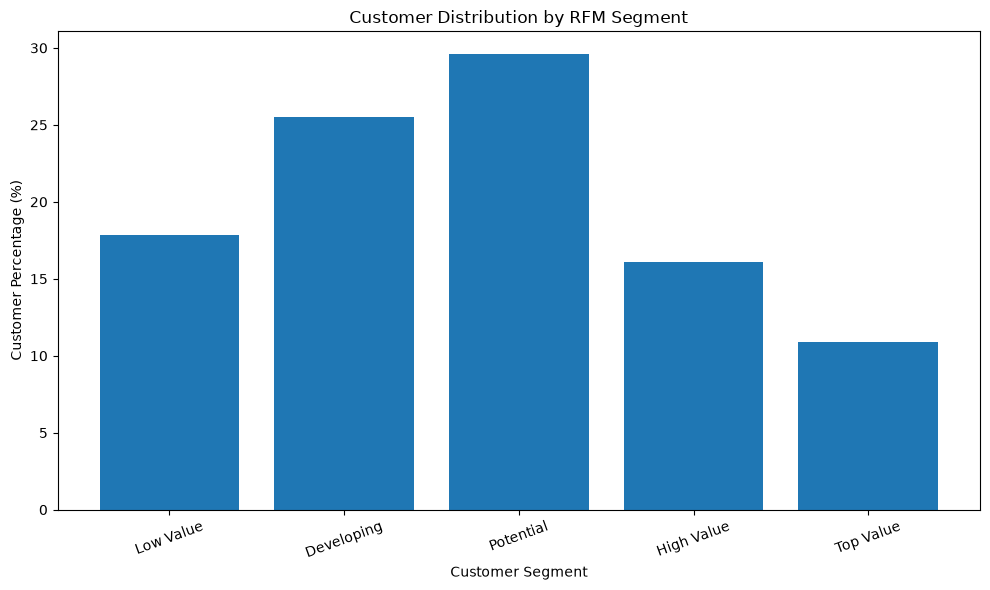

In [125]:
import matplotlib.pyplot as plt

# RFM segments ko customer percentage ke basis par visualize kar rahe hain
plt.figure(figsize=(10, 6))

plt.bar(
    segment_customer_summary.index.astype(str),
    segment_customer_summary["Customer %"]
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Customer Percentage (%)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

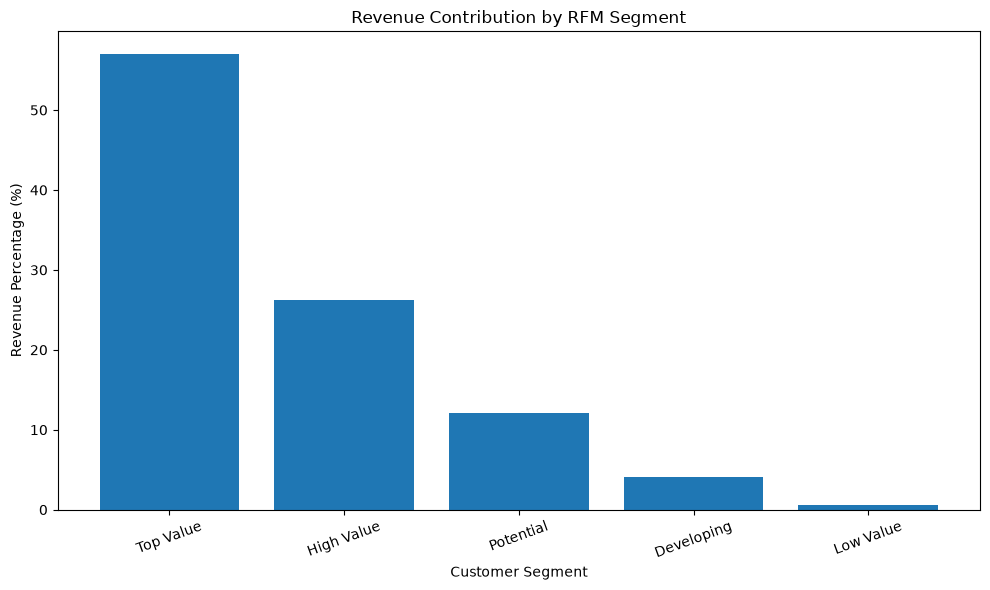

In [126]:
import matplotlib.pyplot as plt

# RFM segments ka revenue percentage visualize kar rahe hain
plt.figure(figsize=(10, 6))

plt.bar(
    segment_revenue_summary.index.astype(str),
    segment_revenue_summary["Revenue %"]
)

plt.title("Revenue Contribution by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue Percentage (%)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

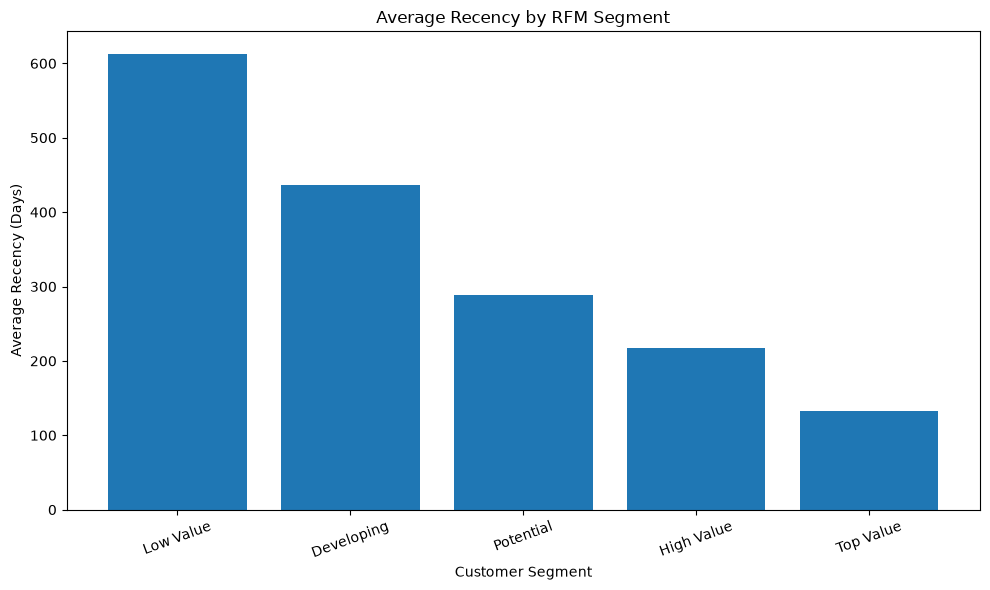

In [127]:
import matplotlib.pyplot as plt

# Har RFM segment ka average recency visualize kar rahe hain
plt.figure(figsize=(10, 6))

plt.bar(
    segment_profile.index.astype(str),
    segment_profile["Average_Recency"]
)

plt.title("Average Recency by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Recency (Days)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

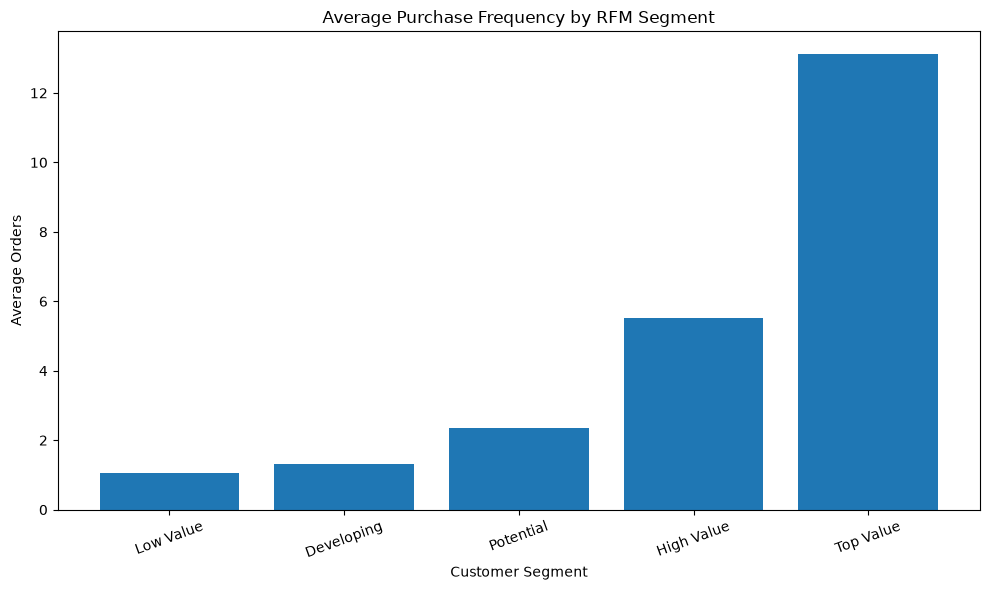

In [128]:
import matplotlib.pyplot as plt

# Har RFM segment ki average purchase frequency visualize kar rahe hain
plt.figure(figsize=(10, 6))

plt.bar(
    segment_profile.index.astype(str),
    segment_profile["Average_Frequency"]
)

plt.title("Average Purchase Frequency by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Orders")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

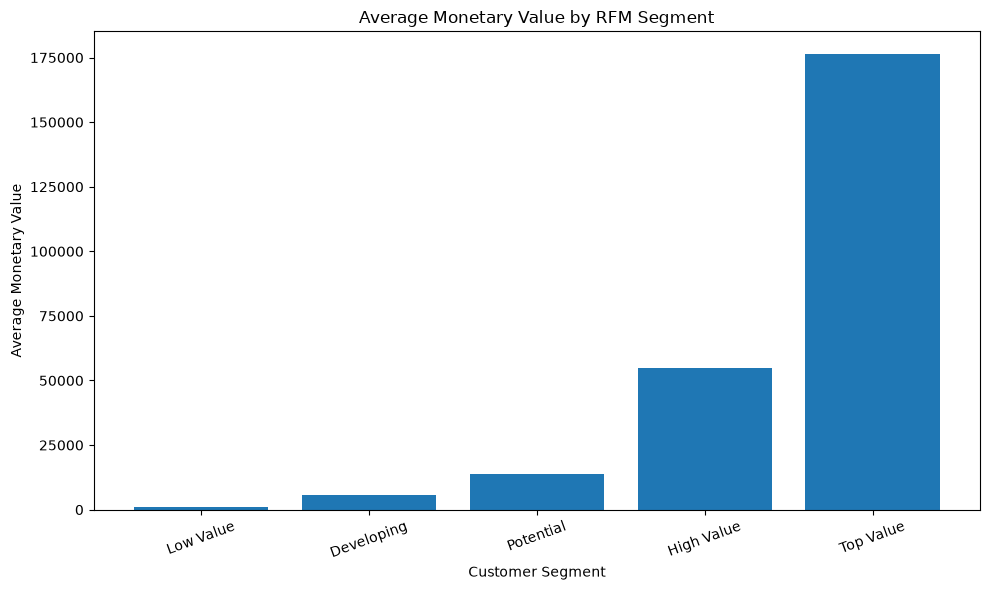

In [129]:
import matplotlib.pyplot as plt

# Har RFM segment ka average monetary value visualize kar rahe hain
plt.figure(figsize=(10, 6))

plt.bar(
    segment_profile.index.astype(str),
    segment_profile["Average_Monetary"]
)

plt.title("Average Monetary Value by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Monetary Value")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [130]:
# RFM segments ki complete performance summary dekh rahe hain

rfm_summary = pd.DataFrame({
    "Customers": segment_profile["Customers"],
    "Customer %": segment_customer_summary["Customer %"],
    "Revenue %": segment_revenue_summary["Revenue %"],
    "Avg Recency (Days)": segment_profile["Average_Recency"],
    "Avg Frequency": segment_profile["Average_Frequency"],
    "Avg Monetary": segment_profile["Average_Monetary"]
})

# Summary table display kar rahe hain
rfm_summary.round(2)

,Customers,Customer %,Revenue %,Avg Recency (Days),Avg Frequency,Avg Monetary
Customer_Segment,,,,,,
Low Value,20614,17.87,0.55,612.49,1.05,1047.58
Developing,29398,25.49,4.14,436.24,1.32,5488.97
Potential,34135,29.60,12.11,288.61,2.36,13819.98
High Value,18584,16.11,26.19,217.51,5.51,54920.33
Top Value,12595,10.92,57.00,133.14,13.12,176343.91


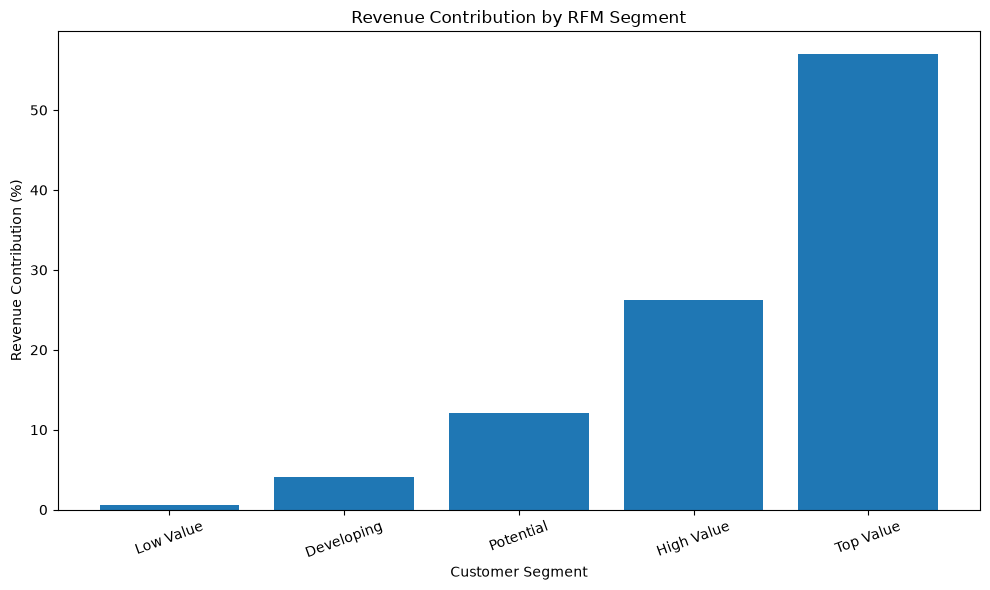

In [131]:
import matplotlib.pyplot as plt

# RFM segments ka revenue contribution percentage visualize kar rahe hain
plt.figure(figsize=(10, 6))

plt.bar(
    rfm_summary.index.astype(str),
    rfm_summary["Revenue %"]
)

plt.title("Revenue Contribution by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue Contribution (%)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [132]:
# High Value aur Top Value customers ka combined contribution calculate kar rahe hain

high_top_customers = rfm_summary.loc[
    ["High Value", "Top Value"],
    "Customers"
].sum()

high_top_customer_pct = rfm_summary.loc[
    ["High Value", "Top Value"],
    "Customer %"
].sum()

high_top_revenue_pct = rfm_summary.loc[
    ["High Value", "Top Value"],
    "Revenue %"
].sum()

print("High + Top Value Customers:", high_top_customers)
print("Customer Share:", round(high_top_customer_pct, 2), "%")
print("Revenue Contribution:", round(high_top_revenue_pct, 2), "%")

High + Top Value Customers: 31179
Customer Share: 27.04 %
Revenue Contribution: 83.2 %


In [133]:
# Low Value aur Developing customers ka combined contribution calculate kar rahe hain

low_developing_customers = rfm_summary.loc[
    ["Low Value", "Developing"],
    "Customers"
].sum()

low_developing_customer_pct = rfm_summary.loc[
    ["Low Value", "Developing"],
    "Customer %"
].sum()

low_developing_revenue_pct = rfm_summary.loc[
    ["Low Value", "Developing"],
    "Revenue %"
].sum()

print("Low + Developing Customers:", low_developing_customers)
print("Customer Share:", round(low_developing_customer_pct, 2), "%")
print("Revenue Contribution:", round(low_developing_revenue_pct, 2), "%")

Low + Developing Customers: 50012
Customer Share: 43.37 %
Revenue Contribution: 4.7 %


In [134]:
# Potential customers ka contribution calculate kar rahe hain

potential_customers = rfm_summary.loc[
    "Potential",
    "Customers"
]

potential_customer_pct = rfm_summary.loc[
    "Potential",
    "Customer %"
]

potential_revenue_pct = rfm_summary.loc[
    "Potential",
    "Revenue %"
]

print("Potential Customers:", potential_customers)
print("Customer Share:", round(potential_customer_pct, 2), "%")
print("Revenue Contribution:", round(potential_revenue_pct, 2), "%")

Potential Customers: 34135
Customer Share: 29.6 %
Revenue Contribution: 12.11 %


In [135]:
# RFM analysis ki final business summary create kar rahe hain

rfm_business_summary = pd.DataFrame({
    "Metric": [
        "High + Top Value Customers",
        "High + Top Value Customer Share",
        "High + Top Value Revenue Contribution",
        "Low + Developing Customers",
        "Low + Developing Customer Share",
        "Low + Developing Revenue Contribution",
        "Potential Customers",
        "Potential Customer Share",
        "Potential Revenue Contribution"
    ],
    
    "Value": [
        high_top_customers,
        high_top_customer_pct,
        high_top_revenue_pct,
        low_developing_customers,
        low_developing_customer_pct,
        low_developing_revenue_pct,
        potential_customers,
        potential_customer_pct,
        potential_revenue_pct
    ]
})

rfm_business_summary

,Metric,Value
0,High + Top Value Customers,31179.000000
1,High + Top Value Customer Share,27.035534
2,High + Top Value Revenue Contribution,83.197176
3,Low + Developing Customers,50012.000000
4,Low + Developing Customer Share,43.365763
5,Low + Developing Revenue Contribution,4.695610
6,Potential Customers,34135.000000
7,Potential Customer Share,29.598703
8,Potential Revenue Contribution,12.107213


#Cohort Analysis ka Step 1

In [136]:
# Har customer ki first purchase date find kar rahe hain
first_purchase = (
    df.groupby("Customer ID")["created_at"]
      .min()
)

# First purchase ko month mein convert kar rahe hain
customer_cohort = first_purchase.dt.to_period("M")

# Result check kar rahe hain
customer_cohort.head(10)

Customer ID
1     2016-07
2     2016-07
3     2016-07
4     2016-07
5     2016-07
6     2016-07
7     2016-07
8     2016-07
9     2016-07
10    2016-07
Name: created_at, dtype: period[M]

In [137]:
# Har transaction ka purchase month identify kar rahe hain
df["Purchase_Month"] = df["created_at"].dt.to_period("M")

# Customer ki first purchase cohort ko original dataset mein add kar rahe hain
df["Cohort_Month"] = df["Customer ID"].map(customer_cohort)

# Check kar rahe hain ke columns correctly add hue hain
df[[
    "Customer ID",
    "Purchase_Month",
    "Cohort_Month"
]].head(10)

,Customer ID,Purchase_Month,Cohort_Month
0,1,2016-07,2016-07
1,2,2016-07,2016-07
2,3,2016-07,2016-07
3,4,2016-07,2016-07
4,5,2016-07,2016-07
5,6,2016-07,2016-07
6,7,2016-07,2016-07
7,6,2016-07,2016-07
8,8,2016-07,2016-07
9,8,2016-07,2016-07


In [138]:
# Har purchase ka cohort se month difference calculate kar rahe hain

df["Cohort_Index"] = (
    (df["Purchase_Month"].dt.year - df["Cohort_Month"].dt.year) * 12
    + (df["Purchase_Month"].dt.month - df["Cohort_Month"].dt.month)
)

# Result check kar rahe hain
df[[
    "Customer ID",
    "Cohort_Month",
    "Purchase_Month",
    "Cohort_Index"
]].head(20)

,Customer ID,Cohort_Month,Purchase_Month,Cohort_Index
0,1,2016-07,2016-07,0
1,2,2016-07,2016-07,0
2,3,2016-07,2016-07,0
3,4,2016-07,2016-07,0
4,5,2016-07,2016-07,0
5,6,2016-07,2016-07,0
6,7,2016-07,2016-07,0
7,6,2016-07,2016-07,0
8,8,2016-07,2016-07,0
9,8,2016-07,2016-07,0


In [139]:
# Har cohort mein har month kitne unique customers active thay,
# unka count calculate kar rahe hain

cohort_data = (
    df.groupby(
        ["Cohort_Month", "Cohort_Index"]
    )["Customer ID"]
    .nunique()
    .reset_index(name="Active Customers")
)

# Result check kar rahe hain
cohort_data.head(20)

,Cohort_Month,Cohort_Index,Active Customers
0,2016-07,0,2406
1,2016-07,1,468
2,2016-07,2,391
3,2016-07,3,325
4,2016-07,4,472
5,2016-07,5,277
6,2016-07,6,250
7,2016-07,7,212
8,2016-07,8,244
9,2016-07,9,251


In [140]:
# Har cohort ke first month ke customer count ko baseline bana rahe hain
cohort_sizes = (
    cohort_data[cohort_data["Cohort_Index"] == 0]
    [["Cohort_Month", "Active Customers"]]
    .rename(columns={"Active Customers": "Cohort Size"})
)

# Cohort size ko har cohort ke monthly customer count ke saath merge kar rahe hain
cohort_retention = cohort_data.merge(
    cohort_sizes,
    on="Cohort_Month"
)

# Retention percentage calculate kar rahe hain
cohort_retention["Retention %"] = (
    cohort_retention["Active Customers"]
    / cohort_retention["Cohort Size"]
    * 100
)

# Result check kar rahe hain
cohort_retention.head(20)

,Cohort_Month,Cohort_Index,Active Customers,Cohort Size,Retention %
0,2016-07,0,2406,2406,100.000000
1,2016-07,1,468,2406,19.451372
2,2016-07,2,391,2406,16.251039
3,2016-07,3,325,2406,13.507897
4,2016-07,4,472,2406,19.617623
5,2016-07,5,277,2406,11.512884
6,2016-07,6,250,2406,10.390690
7,2016-07,7,212,2406,8.811305
8,2016-07,8,244,2406,10.141313
9,2016-07,9,251,2406,10.432253


In [141]:
# Cohort retention data ko matrix format mein convert kar rahe hain

retention_matrix = cohort_retention.pivot(
    index="Cohort_Month",
    columns="Cohort_Index",
    values="Retention %"
)

# Retention matrix check kar rahe hain
retention_matrix.round(2)

Cohort_Index,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
Cohort_Month,,,,,,,,,,,,,,,,,,,,,
2016-07,100.0,19.45,16.25,13.51,19.62,11.51,10.39,8.81,10.14,10.43,...,8.85,3.87,2.95,2.37,3.66,2.49,3.74,2.87,2.12,2.29
2016-08,100.0,12.79,8.85,13.63,7.04,6.07,4.94,5.46,5.10,5.65,...,2.23,1.97,1.74,2.39,1.74,2.13,1.49,1.13,1.39,NaN
2016-09,100.0,13.83,23.84,7.19,6.08,4.78,7.90,7.27,10.31,5.13,...,2.47,2.43,3.42,1.97,3.67,1.76,1.51,2.10,NaN,NaN
2016-10,100.0,20.05,7.52,6.56,5.09,6.63,5.82,6.83,3.20,3.43,...,1.47,2.01,1.62,2.16,1.31,0.89,1.08,NaN,NaN,NaN
2016-11,100.0,8.38,4.32,3.65,4.39,4.23,6.29,3.38,3.67,3.62,...,2.18,1.23,2.10,1.07,0.80,1.00,NaN,NaN,NaN,NaN
2016-12,100.0,9.97,5.89,5.85,3.96,4.43,2.24,2.63,2.47,1.26,...,0.90,1.30,1.06,0.55,0.86,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,10.12,5.64,5.48,5.19,3.53,2.95,2.90,1.87,2.07,...,1.91,1.00,0.71,0.87,NaN,NaN,NaN,NaN,NaN,NaN
2017-02,100.0,9.88,5.10,4.40,2.99,3.06,2.67,1.27,1.44,3.90,...,1.06,0.84,0.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03,100.0,8.71,6.12,3.27,3.42,3.42,1.22,1.88,4.86,1.44,...,0.88,1.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


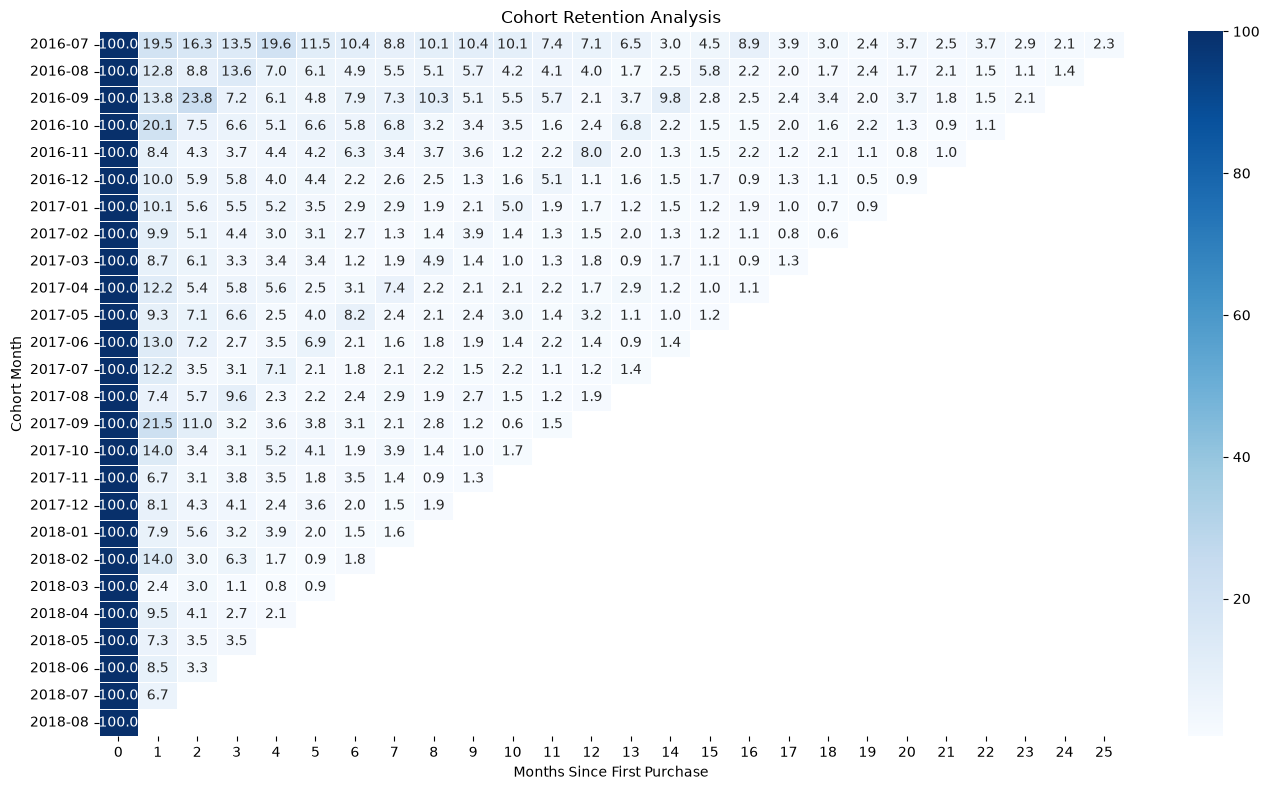

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cohort retention matrix ko heatmap ki form mein visualize kar rahe hain
plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5
)

# Chart ka title aur axis labels
plt.title("Cohort Retention Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

# Layout ko properly adjust kar rahe hain
plt.tight_layout()

# Heatmap display kar rahe hain
plt.show()

In [143]:
# Har Cohort Index par average retention calculate kar rahe hain
# Month 0 ko include kar rahe hain kyunki uski retention 100% hoti hai

overall_retention = retention_matrix.mean(axis=0)

# Result ko round karke display kar rahe hain
overall_retention.round(2)

Cohort_Index
0     100.00
1      10.96
2       6.53
3       5.32
4       4.63
5       3.93
6       3.79
7       3.54
8       3.35
9       3.00
10      2.88
11      2.69
12      2.80
13      2.53
14      2.38
15      2.14
16      2.31
17      1.77
18      1.78
19      1.63
20      2.01
21      1.65
22      1.95
23      2.03
24      1.75
25      2.29
dtype: float64

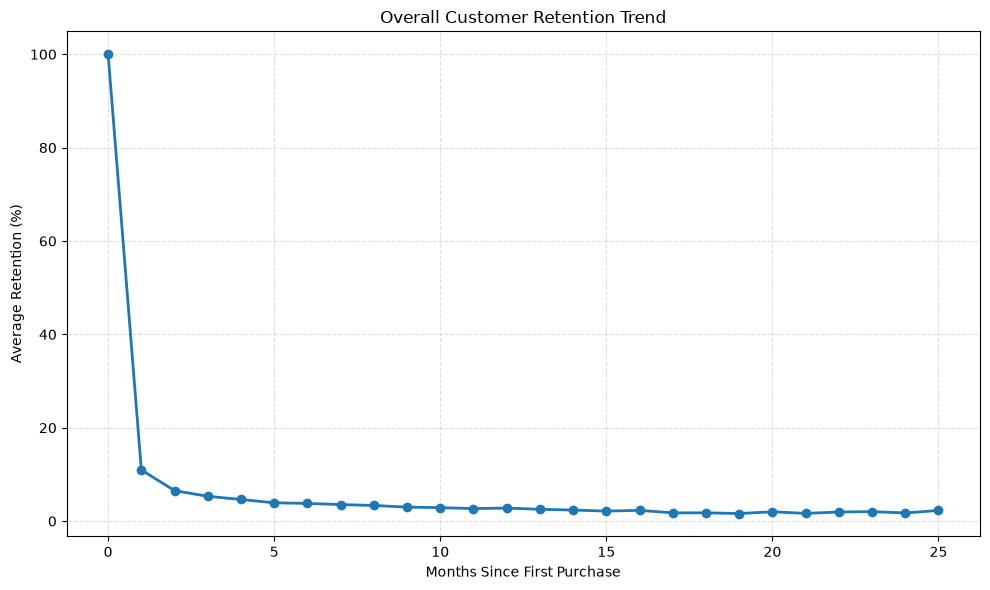

In [144]:
import matplotlib.pyplot as plt

# Overall retention trend ka line chart
plt.figure(figsize=(10, 6))

plt.plot(
    overall_retention.index,
    overall_retention.values,
    marker="o",
    linewidth=2
)

# Chart title aur labels
plt.title("Overall Customer Retention Trend")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Average Retention (%)")

# Grid add kar rahe hain
plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [145]:
# Important retention metrics ko ek summary table mein store kar rahe hain

cohort_summary = pd.DataFrame({
    "Metric": [
        "Month 1 Retention",
        "Month 2 Retention",
        "Month 3 Retention",
        "Month 6 Retention",
        "Month 12 Retention",
        "Month 25 Retention"
    ],
    "Retention %": [
        overall_retention.loc[1],
        overall_retention.loc[2],
        overall_retention.loc[3],
        overall_retention.loc[6],
        overall_retention.loc[12],
        overall_retention.loc[25]
    ]
})

# Values ko 2 decimal places tak round kar rahe hain
cohort_summary["Retention %"] = cohort_summary["Retention %"].round(2)

cohort_summary

,Metric,Retention %
0,Month 1 Retention,10.96
1,Month 2 Retention,6.53
2,Month 3 Retention,5.32
3,Month 6 Retention,3.79
4,Month 12 Retention,2.80
5,Month 25 Retention,2.29


In [146]:
# Har customer ki total lifetime revenue calculate kar rahe hain

customer_ltv = (
    df.groupby("Customer ID")["grand_total"]
      .sum()
      .sort_values(ascending=False)
)

# Top customers ki lifetime value check kar rahe hain
customer_ltv.head(10)

Customer ID
5032      72150379.65
50387     35776000.00
111057    31338185.00
109038    28341357.57
110215    21969066.00
10654     19496005.00
113694    16531260.24
39707     16463501.80
26527     12502191.00
8963      12421437.60
Name: grand_total, dtype: float64

In [147]:
# Pehle har order ki value sirf ek baar le rahe hain
customer_order_value = (
    df.groupby(["Customer ID", "increment_id"])["grand_total"]
      .first()
      .reset_index()
)

# Ab har customer ke tamam orders ki total value calculate kar rahe hain
customer_ltv = (
    customer_order_value
    .groupby("Customer ID")["grand_total"]
    .sum()
    .sort_values(ascending=False)
)

# Top 10 customers ki correct lifetime value check kar rahe hain
customer_ltv.head(10)

Customer ID
5032      36159289.45
109038    19609353.57
50387     17888000.00
110215    17528644.00
113694    16201928.24
39707     16017053.80
10654     15874610.00
111057    15078014.00
26527     11350893.00
11305     11140251.76
Name: grand_total, dtype: float64

In [148]:
# Har customer ki lifetime value ka average calculate kar rahe hain
average_clv = customer_ltv.mean()

# Median lifetime value bhi calculate kar rahe hain
median_clv = customer_ltv.median()

# Minimum aur maximum lifetime value
minimum_clv = customer_ltv.min()
maximum_clv = customer_ltv.max()

print("Average Customer Lifetime Value:", round(average_clv, 2))
print("Median Customer Lifetime Value:", round(median_clv, 2))
print("Minimum Customer Lifetime Value:", round(minimum_clv, 2))
print("Maximum Customer Lifetime Value:", round(maximum_clv, 2))

Average Customer Lifetime Value: 33785.92
Median Customer Lifetime Value: 3500.0
Minimum Customer Lifetime Value: 0.0
Maximum Customer Lifetime Value: 36159289.45


In [149]:
# Customers ko unki lifetime value ke basis par segments mein divide kar rahe hain

clv_segments = pd.cut(
    customer_ltv,
    bins=[-float("inf"), 5000, 25000, 100000, 500000, float("inf")],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

# Har CLV segment mein customers ki count calculate kar rahe hain
clv_summary = (
    clv_segments
    .value_counts()
    .sort_index()
    .to_frame("Customers")
)

# Customer percentage calculate kar rahe hain
clv_summary["Customer %"] = (
    clv_summary["Customers"]
    / len(customer_ltv)
    * 100
)

# Result display kar rahe hain
clv_summary.round(2)

,Customers,Customer %
grand_total,,
Very Low,65747,57.01
Low,27188,23.57
Medium,15740,13.65
High,5676,4.92
Very High,975,0.85


In [150]:
# Har customer ke saath uska CLV segment attach kar rahe hain
customer_clv_analysis = pd.DataFrame({
    "CLV": customer_ltv,
    "CLV Segment": clv_segments
})

# Har segment ki total revenue aur average CLV calculate kar rahe hain
clv_revenue_summary = (
    customer_clv_analysis
    .groupby("CLV Segment", observed=False)
    .agg(
        Customers=("CLV", "count"),
        Total_Revenue=("CLV", "sum"),
        Average_CLV=("CLV", "mean")
    )
)

# Har segment ka revenue contribution calculate kar rahe hain
clv_revenue_summary["Revenue %"] = (
    clv_revenue_summary["Total_Revenue"]
    / clv_revenue_summary["Total_Revenue"].sum()
    * 100
)

# Result ko readable format mein display kar rahe hain
clv_revenue_summary.round(2)

,Customers,Total_Revenue,Average_CLV,Revenue %
CLV Segment,,,,
Very Low,65747,1.133630e+08,1724.23,2.91
Low,27188,3.351281e+08,12326.32,8.60
Medium,15740,7.945428e+08,50479.21,20.39
High,5676,1.158676e+09,204135.97,29.74
Very High,975,1.494686e+09,1533010.91,38.36


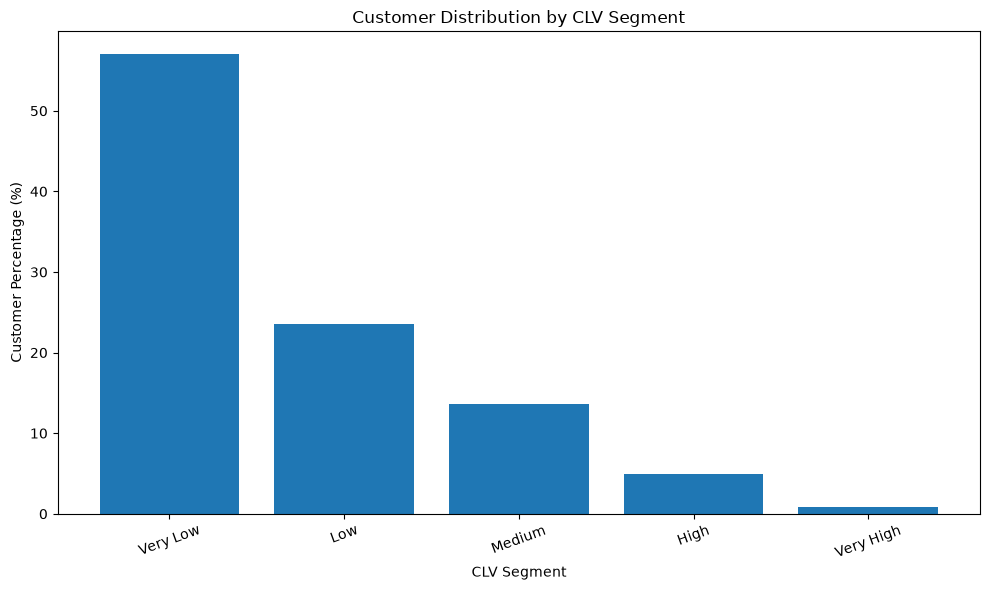

In [151]:
import matplotlib.pyplot as plt

# Har CLV segment ka customer percentage calculate kar rahe hain
customer_percentage = (
    clv_revenue_summary["Customers"]
    / clv_revenue_summary["Customers"].sum()
    * 100
)

# Customer distribution ka chart bana rahe hain
plt.figure(figsize=(10, 6))

plt.bar(
    clv_revenue_summary.index.astype(str),
    customer_percentage
)

plt.title("Customer Distribution by CLV Segment")
plt.xlabel("CLV Segment")
plt.ylabel("Customer Percentage (%)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

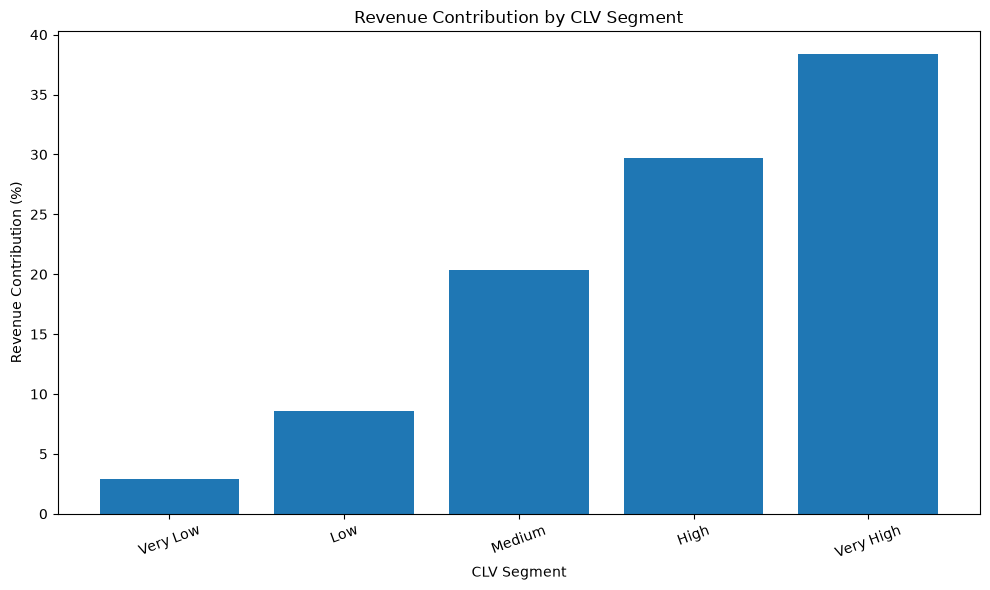

In [152]:
import matplotlib.pyplot as plt

# CLV segments ki revenue contribution visualize kar rahe hain
plt.figure(figsize=(10, 6))

plt.bar(
    clv_revenue_summary.index.astype(str),
    clv_revenue_summary["Revenue %"]
)

plt.title("Revenue Contribution by CLV Segment")
plt.xlabel("CLV Segment")
plt.ylabel("Revenue Contribution (%)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [153]:
# Final CLV summary table prepare kar rahe hain

clv_final_summary = clv_revenue_summary.copy()

# Customer percentage calculate kar rahe hain
clv_final_summary["Customer %"] = (
    clv_final_summary["Customers"]
    / clv_final_summary["Customers"].sum()
    * 100
)

# Important columns ko proper order mein arrange kar rahe hain
clv_final_summary = clv_final_summary[
    [
        "Customers",
        "Customer %",
        "Total_Revenue",
        "Revenue %",
        "Average_CLV"
    ]
]

# Values ko round karke display kar rahe hain
clv_final_summary.round(2)

,Customers,Customer %,Total_Revenue,Revenue %,Average_CLV
CLV Segment,,,,,
Very Low,65747,57.01,1.133630e+08,2.91,1724.23
Low,27188,23.57,3.351281e+08,8.60,12326.32
Medium,15740,13.65,7.945428e+08,20.39,50479.21
High,5676,4.92,1.158676e+09,29.74,204135.97
Very High,975,0.85,1.494686e+09,38.36,1533010.91


#Product / SKU Analysis start

In [154]:
# Product/SKU analysis start kar rahe hain

# Total unique SKUs
total_skus = df["sku"].nunique()

# Total quantity sold
total_quantity = df["qty_ordered"].sum()

# Total product transaction rows
total_product_rows = df["sku"].notna().sum()

# Average quantity per product row
average_quantity = df["qty_ordered"].mean()

print("Total Unique SKUs:", total_skus)
print("Total Quantity Sold:", total_quantity)
print("Total Product Rows:", total_product_rows)
print("Average Quantity per Product Row:", round(average_quantity, 2))

Total Unique SKUs: 84799
Total Quantity Sold: 757770
Total Product Rows: 584504
Average Quantity per Product Row: 1.3


In [155]:
# Har SKU ki total quantity calculate kar rahe hain
top_skus_quantity = (
    df.groupby("sku")["qty_ordered"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

# Top 20 SKUs display kar rahe hain
top_skus_quantity

sku
OTHOTH5A0945D0A72F4              6842
IDROID_BALRX7-Jet black          3981
VIT5ABCCF7FDF973                 3914
IDROID_BALRX7-Gold               3907
MATSAM59DB75ADB2F80              3791
Al Muhafiz Sohan Halwa Almond    2685
KNO59D64DAF36939                 2489
emart_00-7                       2397
infinix_Zero 4-Grey              2191
kcc_krone deal                   2131
OTHPCB5AB351EF2864B              2036
BAGLUX5A099F4DDC6A7              1859
OTHPCB5ABB207927CA9              1831
BAGLUX5A099F4E3D5CF              1782
OTHPCB5ABB2073BDF0C              1730
RB_Veet-bf                       1628
OTHPCB5AB351EEA6010              1608
OTHPCB5ABB206B9F4F8              1602
OTHPCB5AB351EA62FCE              1596
emart_00-1                       1591
Name: qty_ordered, dtype: int64

In [156]:
# Har SKU ki total revenue calculate kar rahe hain
top_skus_revenue = (
    df.groupby("sku")[" MV "]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

# Top 20 revenue-generating SKUs display kar rahe hain
top_skus_revenue

sku
MATSAM59DB757FB47A2             91638202.0
MATSAM5B10F7E2AC8C1             77289242.0
MATSAM59DB75ADB2F80             52316584.0
infinix_Zero 4-Grey             50373348.0
IDROID_BALRX7-Jet black         36142754.0
IDROID_BALRX7-Gold              35436559.0
MATSAM59D74470AD085             31418361.0
iphone-7-32gb-wof-Matt Black    30792002.0
MATSAM5B1509B4696EA             30037976.0
MATSAM5B10F91A9B6AB             27415250.0
MATSAM5B10F2272EBD9             26827499.0
MATSAM5A0BFFF19C40A             24378359.0
MATSAM5A7463EE3C1A5             24268492.0
MATSAM5A9F892ECDF73             22751168.0
ENTECO5A7FE80D6C830             21212164.0
MATSAM5A7DBC6689BE5             20124930.0
ENTSAM5A7BE6883BCB7             18162738.0
MATAPP59D4D1F18B52D             16887571.0
MATSAM59DB758C26262             16884591.0
APPGRE5A81C19C14F44             16689318.0
Name:  MV , dtype: float64

In [157]:
# MV column ka data type check kar rahe hain
print("MV Data Type:", df[" MV "].dtype)

# MV ki basic statistics check kar rahe hain
print("\nMV Statistics:")
print(df[" MV "].describe())

# Sab se bari MV values check kar rahe hain
print("\nTop 10 Largest MV Values:")
print(
    df[["sku", " MV "]]
    .sort_values(" MV ", ascending=False)
    .head(10)
)

MV Data Type: float64

MV Statistics:
count    5.822920e+05
mean     7.204820e+03
std      3.400942e+04
min      0.000000e+00
25%      3.990000e+02
50%      9.990000e+02
75%      5.000000e+03
max      8.944000e+06
Name:  MV , dtype: float64

Top 10 Largest MV Values:
                                sku        MV 
240079      IDROID_BALRX7-Jet black  8944000.0
239381      IDROID_BALRX7-Jet black  8944000.0
239382           IDROID_BALRX7-Gold  8944000.0
239376           IDROID_BALRX7-Gold  8944000.0
239377      IDROID_BALRX7-Jet black  8944000.0
240078           IDROID_BALRX7-Gold  8944000.0
199381  GMZV_PS4 Pro 1TB - Region 2  1315875.0
5699     Huawei Mate 8 With 4GB Ram  1279980.0
949                      Lenovo Zuk  1155966.0
190608              Samsung_40K5000  1039479.0


In [158]:
# MV column ko numeric format mein convert kar rahe hain
df[" MV "] = pd.to_numeric(
    df[" MV "],
    errors="coerce"
)

# Conversion verify kar rahe hain
print("MV Data Type:", df[" MV "].dtype)

print("\nMV Statistics:")
print(df[" MV "].describe())

MV Data Type: float64

MV Statistics:
count    5.822920e+05
mean     7.204820e+03
std      3.400942e+04
min      0.000000e+00
25%      3.990000e+02
50%      9.990000e+02
75%      5.000000e+03
max      8.944000e+06
Name:  MV , dtype: float64


In [159]:
# MV mein missing values count kar rahe hain
mv_missing = df[" MV "].isna().sum()

# MV mein valid values count kar rahe hain
mv_valid = df[" MV "].notna().sum()

# MV ki total rows
mv_total = len(df)

print("Total MV Rows:", mv_total)
print("Valid MV Values:", mv_valid)
print("Missing MV Values:", mv_missing)

print(
    "Missing MV Percentage:",
    round(mv_missing / mv_total * 100, 2),
    "%"
)

Total MV Rows: 584524
Valid MV Values: 582292
Missing MV Values: 2232
Missing MV Percentage: 0.38 %


In [160]:
# Sirf un rows ko select kar rahe hain jahan MV missing hai
missing_mv = df[df[" MV "].isna()]

# Missing MV rows mein important columns ki availability check kar rahe hain
print("Missing MV Rows:", len(missing_mv))

print("\nMissing MV mein Price available:")
print(missing_mv["price"].notna().sum())

print("\nMissing MV mein Quantity available:")
print(missing_mv["qty_ordered"].notna().sum())

print("\nMissing MV mein SKU available:")
print(missing_mv["sku"].notna().sum())

print("\nSample Missing MV Rows:")
missing_mv[["sku", "price", "qty_ordered", "grand_total"]].head(10)

Missing MV Rows: 2232

Missing MV mein Price available:
2232

Missing MV mein Quantity available:
2232

Missing MV mein SKU available:
2215

Sample Missing MV Rows:


,sku,price,qty_ordered,grand_total
6598,"west point_Deluxe Juicer, Blender & Grinder - ...",0.0,1,0.0
6603,"west point_Deluxe Juicer, Blender & Grinder - ...",0.0,1,0.0
7004,"west point_Deluxe Juicer, Blender & Grinder - ...",0.0,1,0.0
8298,stinnos_1301,0.0,1,0.0
8333,stinnos_1301,0.0,10,0.0
8343,stinnos_1301,0.0,1,0.0
8347,stinnos_1301,0.0,1,0.0
8358,stinnos_1301,0.0,2,685.0
8419,stinnos_1500,0.0,1,0.0
8710,stinnos_1500,0.0,1,0.0


## 2.4 Product and SKU Analysis

In [161]:
# Product-level revenue calculate kar rahe hain
# Formula = Price × Quantity Ordered

df["Product_Revenue"] = (
    df["price"] * df["qty_ordered"]
)

# Basic verification
print("Product Revenue Data Type:", df["Product_Revenue"].dtype)

print("\nProduct Revenue Statistics:")
print(df["Product_Revenue"].describe())

print("\nMissing Product Revenue:")
print(df["Product_Revenue"].isna().sum())

Product Revenue Data Type: float64

Product Revenue Statistics:
count    5.845240e+05
mean     7.177307e+03
std      3.394733e+04
min      0.000000e+00
25%      3.990000e+02
50%      9.990000e+02
75%      5.000000e+03
max      8.944000e+06
Name: Product_Revenue, dtype: float64

Missing Product Revenue:
0


In [162]:
# Har SKU ki total product revenue calculate kar rahe hain
top_skus_revenue = (
    df.groupby("sku")["Product_Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

print("Top 20 SKUs by Revenue:")
print(top_skus_revenue)

Top 20 SKUs by Revenue:
sku
MATSAM59DB757FB47A2             91638202.0
MATSAM5B10F7E2AC8C1             77289242.0
MATSAM59DB75ADB2F80             52316584.0
infinix_Zero 4-Grey             50373348.0
IDROID_BALRX7-Jet black         36142754.0
IDROID_BALRX7-Gold              35436559.0
MATSAM59D74470AD085             31418361.0
iphone-7-32gb-wof-Matt Black    30792002.0
MATSAM5B1509B4696EA             30037976.0
MATSAM5B10F91A9B6AB             27415250.0
MATSAM5B10F2272EBD9             26827499.0
MATSAM5A0BFFF19C40A             24378359.0
MATSAM5A7463EE3C1A5             24268492.0
MATSAM5A9F892ECDF73             22751168.0
ENTECO5A7FE80D6C830             21212164.0
MATSAM5A7DBC6689BE5             20124930.0
ENTSAM5A7BE6883BCB7             18162738.0
MATAPP59D4D1F18B52D             16887571.0
MATSAM59DB758C26262             16884591.0
APPGRE5A81C19C14F44             16689318.0
Name: Product_Revenue, dtype: float64


In [163]:
# Top 20 revenue-generating SKUs ki quantity aur revenue combine kar rahe hain
sku_performance = (
    df.groupby("sku")
      .agg(
          Total_Quantity=("qty_ordered", "sum"),
          Total_Revenue=("Product_Revenue", "sum")
      )
      .sort_values("Total_Revenue", ascending=False)
      .head(20)
)

# Average selling price calculate kar rahe hain
sku_performance["Average_Selling_Price"] = (
    sku_performance["Total_Revenue"]
    / sku_performance["Total_Quantity"]
)

print("Top 20 SKU Performance:")
print(sku_performance)

Top 20 SKU Performance:
                              Total_Quantity  Total_Revenue  \
sku                                                           
MATSAM59DB757FB47A2                     1281     91638202.0   
MATSAM5B10F7E2AC8C1                      678     77289242.0   
MATSAM59DB75ADB2F80                     3791     52316584.0   
infinix_Zero 4-Grey                     2191     50373348.0   
IDROID_BALRX7-Jet black                 3981     36142754.0   
IDROID_BALRX7-Gold                      3907     35436559.0   
MATSAM59D74470AD085                      332     31418361.0   
iphone-7-32gb-wof-Matt Black             367     30792002.0   
MATSAM5B1509B4696EA                      333     30037976.0   
MATSAM5B10F91A9B6AB                      237     27415250.0   
MATSAM5B10F2272EBD9                      328     26827499.0   
MATSAM5A0BFFF19C40A                      346     24378359.0   
MATSAM5A7463EE3C1A5                     1437     24268492.0   
MATSAM5A9F892ECDF73            

In [164]:
# Top 20 SKUs ki total revenue
top_20_revenue = sku_performance["Total_Revenue"].sum()

# Complete dataset ki total product revenue
total_product_revenue = df["Product_Revenue"].sum()

# Top 20 revenue contribution
top_20_revenue_percentage = (
    top_20_revenue / total_product_revenue * 100
)

print("Top 20 SKU Revenue:", round(top_20_revenue, 2))
print("Total Product Revenue:", round(total_product_revenue, 2))
print(
    "Top 20 Revenue Contribution:",
    round(top_20_revenue_percentage, 2),
    "%"
)

Top 20 SKU Revenue: 671047108.0
Total Product Revenue: 4195307997.08
Top 20 Revenue Contribution: 16.0 %


In [165]:
# Har SKU ki total quantity aur total revenue calculate kar rahe hain
sku_analysis = (
    df.groupby("sku")
      .agg(
          Total_Quantity=("qty_ordered", "sum"),
          Total_Revenue=("Product_Revenue", "sum")
      )
      .reset_index()
)

# SKU-level correlation calculate kar rahe hain
correlation = sku_analysis["Total_Quantity"].corr(
    sku_analysis["Total_Revenue"]
)

print("Total SKUs Analyzed:", len(sku_analysis))
print("Quantity vs Revenue Correlation:", round(correlation, 3))

Total SKUs Analyzed: 84799
Quantity vs Revenue Correlation: 0.407


In [166]:
# Har SKU ki total quantity calculate kar rahe hain
sku_quantity = (
    df.groupby("sku")["qty_ordered"]
      .sum()
)

# Sold aur unsold SKUs count kar rahe hain
sold_skus = (sku_quantity > 0).sum()
zero_quantity_skus = (sku_quantity == 0).sum()

print("Total SKUs:", len(sku_quantity))
print("SKUs with Quantity > 0:", sold_skus)
print("SKUs with Quantity = 0:", zero_quantity_skus)

print(
    "Sold SKU Percentage:",
    round(sold_skus / len(sku_quantity) * 100, 2),
    "%"
)

Total SKUs: 84799
SKUs with Quantity > 0: 84799
SKUs with Quantity = 0: 0
Sold SKU Percentage: 100.0 %


In [167]:
                                  # Customer Churn / Inactive Customer Analysis start from down

In [168]:
# Har customer ki last purchase date find kar rahe hain
customer_last_purchase = (
    df.groupby("Customer ID")["created_at"]
      .max()
      .sort_values()
)

# Result check kar rahe hain
print("Total Customers:", customer_last_purchase.shape[0])
print("\nLast Purchase Date:")
print(customer_last_purchase.head())
print("\nMost Recent Purchases:")
print(customer_last_purchase.tail())

Total Customers: 115326

Last Purchase Date:
Customer ID
1     2016-07-01
157   2016-07-01
84    2016-07-01
158   2016-07-01
164   2016-07-01
Name: created_at, dtype: datetime64[us]

Most Recent Purchases:
Customer ID
106822   2018-08-28
114062   2018-08-28
114151   2018-08-28
109697   2018-08-28
115326   2018-08-28
Name: created_at, dtype: datetime64[us]


In [169]:
# Dataset ki latest purchase date ko reference point bana rahe hain
reference_date = df["created_at"].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2018-08-29 00:00:00


In [170]:
# Har customer ki last purchase ke baad kitne din guzre,
# ye calculate kar rahe hain
customer_recency = (
    reference_date - customer_last_purchase
).dt.days

print("Recency Statistics:")
print(customer_recency.describe())

Recency Statistics:
count    115326.000000
mean        355.696781
std         207.107491
min           1.000000
25%         173.000000
50%         290.000000
75%         531.000000
max         789.000000
Name: created_at, dtype: float64


In [171]:
# Customers ko unki last purchase ke gap ke according groups mein divide kar rahe hain
recency_bands = pd.cut(
    customer_recency,
    bins=[0, 30, 90, 180, 365, 730, float("inf")],
    labels=[
        "0-30 Days",
        "31-90 Days",
        "91-180 Days",
        "181-365 Days",
        "366-730 Days",
        "730+ Days"
    ]
)

# Har recency group mein customers ki count
recency_distribution = (
    recency_bands
    .value_counts()
    .sort_index()
)

print("Customer Recency Distribution:")
print(recency_distribution)

print("\nCustomer Recency Percentage:")
print(
    (recency_distribution / len(customer_recency) * 100)
    .round(2)
)

Customer Recency Distribution:
created_at
0-30 Days        3424
31-90 Days       5589
91-180 Days     21387
181-365 Days    33875
366-730 Days    47817
730+ Days        3234
Name: count, dtype: int64

Customer Recency Percentage:
created_at
0-30 Days        2.97
31-90 Days       4.85
91-180 Days     18.54
181-365 Days    29.37
366-730 Days    41.46
730+ Days        2.80
Name: count, dtype: float64


In [172]:
# Customer-level recency data ko DataFrame mein convert kar rahe hain
customer_recency_df = (
    customer_recency
    .rename("Days_Since_Last_Purchase")
    .reset_index()
)

print("Customer Recency DataFrame:")
print(customer_recency_df.head())

print("\nShape:")
print(customer_recency_df.shape)

Customer Recency DataFrame:
   Customer ID  Days_Since_Last_Purchase
0            1                       789
1          157                       789
2           84                       789
3          158                       789
4          164                       789

Shape:
(115326, 2)


In [173]:
import numpy as np

In [174]:
# 180 days se zyada purane customers ko inactive mark kar rahe hain
customer_recency_df["Customer_Status"] = np.where(
    customer_recency_df["Days_Since_Last_Purchase"] > 180,
    "Inactive",
    "Active"
)

# Active aur Inactive customers ki count
status_distribution = (
    customer_recency_df["Customer_Status"]
    .value_counts()
)

print("Customer Status Distribution:")
print(status_distribution)

print("\nCustomer Status Percentage:")
print(
    (status_distribution / len(customer_recency_df) * 100)
    .round(2)
)

Customer Status Distribution:
Customer_Status
Inactive    84926
Active      30400
Name: count, dtype: int64

Customer Status Percentage:
Customer_Status
Inactive    73.64
Active      26.36
Name: count, dtype: float64


In [175]:
# Har customer ki total historical order value calculate kar rahe hain
customer_revenue = (
    df.groupby("Customer ID")["increment_id"]
    .nunique()
    .to_frame("Total Orders")
)

customer_revenue["Total Revenue"] = (
    df.groupby(["Customer ID", "increment_id"])["grand_total"]
    .first()
    .groupby("Customer ID")
    .sum()
)

# Recency status ke saath revenue information merge kar rahe hain
customer_analysis = customer_recency_df.merge(
    customer_revenue,
    on="Customer ID",
    how="left"
)

# Active vs Inactive customers ki revenue compare kar rahe hain
status_revenue = (
    customer_analysis
    .groupby("Customer_Status")["Total Revenue"]
    .agg(["sum", "mean"])
)

print("Revenue by Customer Status:")
print(status_revenue)

print("\nRevenue Percentage:")
print(
    (status_revenue["sum"] / status_revenue["sum"].sum() * 100)
    .round(2)
)

Revenue by Customer Status:
                          sum          mean
Customer_Status                            
Active           2.005907e+09  65983.786103
Inactive         1.890488e+09  22260.417435

Revenue Percentage:
Customer_Status
Active      51.48
Inactive    48.52
Name: sum, dtype: float64


In [176]:
# Sirf inactive customers ko filter kar rahe hain
inactive_customers = customer_analysis[
    customer_analysis["Customer_Status"] == "Inactive"
].copy()

# Inactive customers ko unki historical revenue ke according groups mein divide kar rahe hain
inactive_value_segments = pd.cut(
    inactive_customers["Total Revenue"],
    bins=[-float("inf"), 5000, 25000, 100000, 500000, float("inf")],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

# Har value segment mein inactive customers ki count
inactive_segment_distribution = (
    inactive_value_segments
    .value_counts()
    .sort_index()
)

print("Inactive Customer Value Distribution:")
print(inactive_segment_distribution)

print("\nInactive Customer Value Percentage:")
print(
    (inactive_segment_distribution / len(inactive_customers) * 100)
    .round(2)
)

Inactive Customer Value Distribution:
Total Revenue
Very Low     52546
Low          19118
Medium       10078
High          2870
Very High      314
Name: count, dtype: int64

Inactive Customer Value Percentage:
Total Revenue
Very Low     61.87
Low          22.51
Medium       11.87
High          3.38
Very High     0.37
Name: count, dtype: float64


In [177]:
# Inactive customers ke value segments ko customer data ke saath attach kar rahe hain
inactive_customers["Value_Segment"] = inactive_value_segments

# Har inactive segment ki total revenue calculate kar rahe hain
inactive_segment_revenue = (
    inactive_customers
    .groupby("Value_Segment", observed=False)["Total Revenue"]
    .agg(["count", "sum", "mean"])
)

print("Inactive Customer Segment Revenue:")
print(inactive_segment_revenue)

print("\nRevenue Contribution (%):")
print(
    (
        inactive_segment_revenue["sum"]
        / inactive_segment_revenue["sum"].sum()
        * 100
    ).round(2)
)

Inactive Customer Segment Revenue:
               count           sum          mean
Value_Segment                                   
Very Low       52546  8.615756e+07  1.639660e+03
Low            19118  2.340340e+08  1.224155e+04
Medium         10078  5.048123e+08  5.009052e+04
High            2870  5.635547e+08  1.963605e+05
Very High        314  5.019297e+08  1.598502e+06

Revenue Contribution (%):
Value_Segment
Very Low      4.56
Low          12.38
Medium       26.70
High         29.81
Very High    26.55
Name: sum, dtype: float64


In [178]:
# High aur Very High value wale inactive customers ko filter kar rahe hain
high_value_inactive = inactive_customers[
    inactive_customers["Value_Segment"].isin(["High", "Very High"])
].copy()

print("High-Value Inactive Customers:", len(high_value_inactive))

print("\nTotal Historical Revenue:")
print(high_value_inactive["Total Revenue"].sum())

print("\nAverage Historical Revenue per Customer:")
print(high_value_inactive["Total Revenue"].mean())

print("\nAverage Orders per Customer:")
print(high_value_inactive["Total Orders"].mean())

print("\nRecency Statistics:")
print(
    high_value_inactive["Days_Since_Last_Purchase"].describe()
)

High-Value Inactive Customers: 3184

Total Historical Revenue:
1065484369.223

Average Historical Revenue per Customer:
334637.0506353643

Average Orders per Customer:
18.593278894472363

Recency Statistics:
count    3184.000000
mean      352.982412
std       149.703249
min       181.000000
25%       273.000000
50%       283.000000
75%       464.000000
max       789.000000
Name: Days_Since_Last_Purchase, dtype: float64


In [179]:
# High-value inactive customers ko recency ke according groups mein divide kar rahe hain
high_value_recency_bands = pd.cut(
    high_value_inactive["Days_Since_Last_Purchase"],
    bins=[180, 270, 365, 545, 730, float("inf")],
    labels=[
        "181-270 Days",
        "271-365 Days",
        "366-545 Days",
        "546-730 Days",
        "730+ Days"
    ]
)

# Har recency group mein high-value inactive customers ki count
high_value_recency_distribution = (
    high_value_recency_bands
    .value_counts()
    .sort_index()
)

print("High-Value Inactive Customer Recency:")
print(high_value_recency_distribution)

print("\nPercentage:")
print(
    (
        high_value_recency_distribution
        / len(high_value_inactive)
        * 100
    ).round(2)
)

High-Value Inactive Customer Recency:
Days_Since_Last_Purchase
181-270 Days     760
271-365 Days    1344
366-545 Days     630
546-730 Days     394
730+ Days         56
Name: count, dtype: int64

Percentage:
Days_Since_Last_Purchase
181-270 Days    23.87
271-365 Days    42.21
366-545 Days    19.79
546-730 Days    12.37
730+ Days        1.76
Name: count, dtype: float64


In [180]:
# Recency groups ko high-value inactive customer data ke saath attach kar rahe hain
high_value_inactive["Recency_Group"] = high_value_recency_bands

# Har recency group ki customer count, orders aur revenue analyze kar rahe hain
high_value_recency_analysis = (
    high_value_inactive
    .groupby("Recency_Group", observed=False)
    .agg(
        Customers=("Customer ID", "count"),
        Total_Orders=("Total Orders", "sum"),
        Total_Revenue=("Total Revenue", "sum"),
        Average_Orders=("Total Orders", "mean"),
        Average_Revenue=("Total Revenue", "mean")
    )
)

print("High-Value Inactive Customer Recency Analysis:")
print(high_value_recency_analysis)

High-Value Inactive Customer Recency Analysis:
               Customers  Total_Orders  Total_Revenue  Average_Orders  \
Recency_Group                                                           
181-270 Days         760         12380   1.917217e+08       16.289474   
271-365 Days        1344         17800   3.774351e+08       13.244048   
366-545 Days         630         21337   3.434056e+08       33.868254   
546-730 Days         394          7375   1.365346e+08       18.718274   
730+ Days             56           309   1.638734e+07        5.517857   

               Average_Revenue  
Recency_Group                   
181-270 Days     252265.397994  
271-365 Days     280829.675898  
366-545 Days     545088.236175  
546-730 Days     346534.640990  
730+ Days        292631.160714  


In [181]:
# High-value inactive customers ko historical revenue ke according sort kar rahe hain
top_inactive_customers = (
    high_value_inactive
    .sort_values("Total Revenue", ascending=False)
    .head(20)
)

print("Top 20 High-Value Inactive Customers:")
print(
    top_inactive_customers[
        [
            "Customer ID",
            "Days_Since_Last_Purchase",
            "Total Orders",
            "Total Revenue"
        ]
    ].to_string(index=False)
)

Top 20 High-Value Inactive Customers:
 Customer ID  Days_Since_Last_Purchase  Total Orders  Total Revenue
        5032                       278            38    36159289.45
       50387                       446             1    17888000.00
       10654                       444           370    15874610.00
       26527                       522           558    11350893.00
        8963                       373           420    10904502.10
       28896                       311           410    10642805.00
       13793                       283           287    10013108.00
       37999                       330           242     7148379.25
        9548                       485           148     6399446.00
         225                       210           295     6086365.42
       28952                       407           202     6017881.00
       38117                       495           143     5573519.00
        1061                       292           287     5428592.00
       125

In [182]:
# Top 20 inactive high-value customers ki total historical revenue
top_20_revenue = top_inactive_customers["Total Revenue"].sum()

# Sabhi high-value inactive customers ki total historical revenue
total_high_value_revenue = high_value_inactive["Total Revenue"].sum()

# Top 20 ka revenue contribution
top_20_revenue_percentage = (
    top_20_revenue / total_high_value_revenue * 100
)

print("Top 20 Revenue:")
print(round(top_20_revenue, 2))

print("\nTotal High-Value Inactive Revenue:")
print(round(total_high_value_revenue, 2))

print("\nTop 20 Revenue Contribution:")
print(round(top_20_revenue_percentage, 2), "%")

Top 20 Revenue:
180263869.79

Total High-Value Inactive Revenue:
1065484369.22

Top 20 Revenue Contribution:
16.92 %


In [183]:
# Inactive customers ko unke total orders ke according groups mein divide kar rahe hain
inactive_frequency = pd.cut(
    inactive_customers["Total Orders"],
    bins=[0, 1, 2, 5, 10, 20, float("inf")],
    labels=[
        "1 Order",
        "2 Orders",
        "3-5 Orders",
        "6-10 Orders",
        "11-20 Orders",
        "21+ Orders"
    ]
)

# Har frequency group mein inactive customers ki count
inactive_frequency_distribution = (
    inactive_frequency
    .value_counts()
    .sort_index()
)

print("Inactive Customer Order Frequency:")
print(inactive_frequency_distribution)

print("\nInactive Customer Order Frequency Percentage:")
print(
    (
        inactive_frequency_distribution
        / len(inactive_customers)
        * 100
    ).round(2)
)

Inactive Customer Order Frequency:
Total Orders
1 Order         49214
2 Orders        14521
3-5 Orders      13888
6-10 Orders      4746
11-20 Orders     1705
21+ Orders        852
Name: count, dtype: int64

Inactive Customer Order Frequency Percentage:
Total Orders
1 Order         57.95
2 Orders        17.10
3-5 Orders      16.35
6-10 Orders      5.59
11-20 Orders     2.01
21+ Orders       1.00
Name: count, dtype: float64


In [184]:
# Inactive customers ko one-time aur repeat customers mein divide kar rahe hain
inactive_customer_type = np.where(
    inactive_customers["Total Orders"] == 1,
    "One-Time",
    "Repeat"
)

inactive_customers["Customer_Type"] = inactive_customer_type

# One-Time vs Repeat inactive customers ki revenue analysis
inactive_type_analysis = (
    inactive_customers
    .groupby("Customer_Type")
    .agg(
        Customers=("Customer ID", "count"),
        Total_Revenue=("Total Revenue", "sum"),
        Average_Revenue=("Total Revenue", "mean"),
        Average_Orders=("Total Orders", "mean")
    )
)

print("Inactive Customer Type Analysis:")
print(inactive_type_analysis)

print("\nCustomer Percentage:")
print(
    (
        inactive_type_analysis["Customers"]
        / inactive_type_analysis["Customers"].sum()
        * 100
    ).round(2)
)

print("\nRevenue Percentage:")
print(
    (
        inactive_type_analysis["Total_Revenue"]
        / inactive_type_analysis["Total_Revenue"].sum()
        * 100
    ).round(2)
)

Inactive Customer Type Analysis:
               Customers  Total_Revenue  Average_Revenue  Average_Orders
Customer_Type                                                           
One-Time           49214   3.153795e+08      6408.329830        1.000000
Repeat             35712   1.575109e+09     44105.865446        5.375196

Customer Percentage:
Customer_Type
One-Time    57.95
Repeat      42.05
Name: Customers, dtype: Float64

Revenue Percentage:
Customer_Type
One-Time    16.68
Repeat      83.32
Name: Total_Revenue, dtype: float64


In [185]:
# Sirf repeat inactive customers ko filter kar rahe hain
repeat_inactive = inactive_customers[
    inactive_customers["Customer_Type"] == "Repeat"
].copy()

# Repeat inactive customers ki overall statistics
print("Repeat Inactive Customers:", len(repeat_inactive))

print("\nTotal Historical Revenue:")
print(round(repeat_inactive["Total Revenue"].sum(), 2))

print("\nAverage Historical Revenue:")
print(round(repeat_inactive["Total Revenue"].mean(), 2))

print("\nAverage Orders:")
print(round(repeat_inactive["Total Orders"].mean(), 2))

print("\nRecency Statistics:")
print(repeat_inactive["Days_Since_Last_Purchase"].describe())

Repeat Inactive Customers: 35712

Total Historical Revenue:
1575108666.81

Average Historical Revenue:
44105.87

Average Orders:
5.38

Recency Statistics:
count    35712.000000
mean       412.350638
std        161.636340
min        181.000000
25%        278.000000
50%        380.000000
75%        548.000000
max        789.000000
Name: Days_Since_Last_Purchase, dtype: float64


In [186]:
# Repeat inactive customers ko historical revenue ke according groups mein divide kar rahe hain
repeat_value_segments = pd.cut(
    repeat_inactive["Total Revenue"],
    bins=[-float("inf"), 5000, 25000, 100000, 500000, float("inf")],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

# Har value segment ki customer count
repeat_segment_distribution = (
    repeat_value_segments
    .value_counts()
    .sort_index()
)

print("Repeat Inactive Customer Value Distribution:")
print(repeat_segment_distribution)

print("\nCustomer Percentage:")
print(
    (
        repeat_segment_distribution
        / len(repeat_inactive)
        * 100
    ).round(2)
)

Repeat Inactive Customer Value Distribution:
Total Revenue
Very Low     14252
Low          10598
Medium        7798
High          2761
Very High      303
Name: count, dtype: int64

Customer Percentage:
Total Revenue
Very Low     39.91
Low          29.68
Medium       21.84
High          7.73
Very High     0.85
Name: count, dtype: float64


In [187]:
# High aur Very High value wale repeat inactive customers ko filter kar rahe hain
high_value_repeat_inactive = repeat_inactive[
    repeat_value_segments.isin(["High", "Very High"])
].copy()

print("High-Value Repeat Inactive Customers:")
print(len(high_value_repeat_inactive))

print("\nTotal Historical Revenue:")
print(
    round(
        high_value_repeat_inactive["Total Revenue"].sum(),
        2
    )
)

print("\nAverage Historical Revenue per Customer:")
print(
    round(
        high_value_repeat_inactive["Total Revenue"].mean(),
        2
    )
)

print("\nAverage Orders per Customer:")
print(
    round(
        high_value_repeat_inactive["Total Orders"].mean(),
        2
    )
)

High-Value Repeat Inactive Customers:
3064

Total Historical Revenue:
1020200364.24

Average Historical Revenue per Customer:
332963.57

Average Orders per Customer:
19.28


In [188]:
# High-value repeat inactive customers ki recency statistics check kar rahe hain
print("Recency Statistics:")
print(
    high_value_repeat_inactive[
        "Days_Since_Last_Purchase"
    ].describe()
)

Recency Statistics:
count    3064.000000
mean      348.380875
std       145.598765
min       181.000000
25%       272.000000
50%       283.000000
75%       459.000000
max       789.000000
Name: Days_Since_Last_Purchase, dtype: float64


In [189]:
# High-value repeat inactive customers ko recency groups mein divide kar rahe hain
high_value_repeat_recency = pd.cut(
    high_value_repeat_inactive["Days_Since_Last_Purchase"],
    bins=[180, 270, 365, 545, 730, float("inf")],
    labels=[
        "181-270 Days",
        "271-365 Days",
        "366-545 Days",
        "546-730 Days",
        "730+ Days"
    ]
)

# Har recency group mein customers ki count
recency_distribution = (
    high_value_repeat_recency
    .value_counts()
    .sort_index()
)

print("High-Value Repeat Inactive Recency Distribution:")
print(recency_distribution)

print("\nCustomer Percentage:")
print(
    (
        recency_distribution
        / len(high_value_repeat_inactive)
        * 100
    ).round(2)
)

High-Value Repeat Inactive Recency Distribution:
Days_Since_Last_Purchase
181-270 Days     742
271-365 Days    1314
366-545 Days     605
546-730 Days     363
730+ Days         40
Name: count, dtype: int64

Customer Percentage:
Days_Since_Last_Purchase
181-270 Days    24.22
271-365 Days    42.89
366-545 Days    19.75
546-730 Days    11.85
730+ Days        1.31
Name: count, dtype: float64


In [190]:
# Recency groups ko original DataFrame mein attach kar rahe hain
high_value_repeat_inactive["Recency_Group"] = high_value_repeat_recency

# Har recency group ka detailed analysis
high_value_repeat_recency_analysis = (
    high_value_repeat_inactive
    .groupby("Recency_Group", observed=False)
    .agg(
        Customers=("Customer ID", "count"),
        Total_Orders=("Total Orders", "sum"),
        Total_Revenue=("Total Revenue", "sum"),
        Average_Orders=("Total Orders", "mean"),
        Average_Revenue=("Total Revenue", "mean")
    )
)

print("High-Value Repeat Inactive Recency Analysis:")
print(high_value_repeat_recency_analysis.round(2))

High-Value Repeat Inactive Recency Analysis:
               Customers  Total_Orders  Total_Revenue  Average_Orders  \
Recency_Group                                                           
181-270 Days         742         12362   1.887347e+08           16.66   
271-365 Days        1314         17770   3.731384e+08           13.52   
366-545 Days         605         21312   3.189424e+08           35.23   
546-730 Days         363          7344   1.301645e+08           20.23   
730+ Days             40           293   9.220345e+06            7.32   

               Average_Revenue  
Recency_Group                   
181-270 Days         254359.38  
271-365 Days         283971.40  
366-545 Days         527177.59  
546-730 Days         358579.87  
730+ Days            230508.62  


In [191]:
# High-value repeat inactive customers ko historical revenue ke
# according descending order mein arrange kar rahe hain
top_repeat_inactive_customers = (
    high_value_repeat_inactive
    .sort_values(
        "Total Revenue",
        ascending=False
    )
    .head(20)
)

print("Top 20 High-Value Repeat Inactive Customers:")
print(
    top_repeat_inactive_customers[
        [
            "Customer ID",
            "Days_Since_Last_Purchase",
            "Total Orders",
            "Total Revenue"
        ]
    ].to_string(index=False)
)

Top 20 High-Value Repeat Inactive Customers:
 Customer ID  Days_Since_Last_Purchase  Total Orders  Total Revenue
        5032                       278            38    36159289.45
       10654                       444           370    15874610.00
       26527                       522           558    11350893.00
        8963                       373           420    10904502.10
       28896                       311           410    10642805.00
       13793                       283           287    10013108.00
       37999                       330           242     7148379.25
        9548                       485           148     6399446.00
         225                       210           295     6086365.42
       28952                       407           202     6017881.00
       38117                       495           143     5573519.00
        1061                       292           287     5428592.00
       12535                       534           241     5220603.80
   

In [192]:
# Top 20 customers ka total historical revenue
top_20_repeat_revenue = (
    top_repeat_inactive_customers["Total Revenue"].sum()
)

# Pooray high-value repeat inactive group ka total revenue
total_repeat_high_value_revenue = (
    high_value_repeat_inactive["Total Revenue"].sum()
)

# Top 20 revenue contribution percentage
top_20_repeat_revenue_percentage = (
    top_20_repeat_revenue
    / total_repeat_high_value_revenue
    * 100
)

print("Top 20 Historical Revenue:")
print(round(top_20_repeat_revenue, 2))

print("\nTotal High-Value Repeat Inactive Revenue:")
print(round(total_repeat_high_value_revenue, 2))

print("\nTop 20 Revenue Contribution:")
print(round(top_20_repeat_revenue_percentage, 2), "%")

Top 20 Historical Revenue:
166127981.79

Total High-Value Repeat Inactive Revenue:
1020200364.24

Top 20 Revenue Contribution:
16.28 %


In [193]:
# Total inactive customers ka historical revenue
total_inactive_revenue = (
    inactive_customers["Total Revenue"].sum()
)

# High-value repeat inactive customers ka historical revenue
high_value_repeat_revenue = (
    high_value_repeat_inactive["Total Revenue"].sum()
)

# Inactive revenue mein high-value repeat customers ka contribution
high_value_repeat_revenue_percentage = (
    high_value_repeat_revenue
    / total_inactive_revenue
    * 100
)

print("Total Inactive Customer Revenue:")
print(round(total_inactive_revenue, 2))

print("\nHigh-Value Repeat Inactive Revenue:")
print(round(high_value_repeat_revenue, 2))

print("\nRevenue Contribution:")
print(round(high_value_repeat_revenue_percentage, 2), "%")

Total Inactive Customer Revenue:
1890488211.07

High-Value Repeat Inactive Revenue:
1020200364.24

Revenue Contribution:
53.96 %


In [194]:
# High-value repeat inactive customers ko final risk groups mein divide kar rahe hain
high_value_repeat_inactive["Risk_Group"] = pd.cut(
    high_value_repeat_inactive["Days_Since_Last_Purchase"],
    bins=[180, 270, 365, float("inf")],
    labels=[
        "Recent Inactive",
        "Moderately Inactive",
        "Long-Term Inactive"
    ]
)

# Har risk group ki customer count aur historical value
risk_group_analysis = (
    high_value_repeat_inactive
    .groupby("Risk_Group", observed=False)
    .agg(
        Customers=("Customer ID", "count"),
        Total_Orders=("Total Orders", "sum"),
        Total_Revenue=("Total Revenue", "sum"),
        Average_Revenue=("Total Revenue", "mean"),
        Average_Orders=("Total Orders", "mean")
    )
)

print("High-Value Repeat Inactive Risk Analysis:")
print(risk_group_analysis.round(2))

High-Value Repeat Inactive Risk Analysis:
                     Customers  Total_Orders  Total_Revenue  Average_Revenue  \
Risk_Group                                                                     
Recent Inactive            742         12362   1.887347e+08        254359.38   
Moderately Inactive       1314         17770   3.731384e+08        283971.40   
Long-Term Inactive        1008         28949   4.583273e+08        454689.76   

                     Average_Orders  
Risk_Group                           
Recent Inactive               16.66  
Moderately Inactive           13.52  
Long-Term Inactive            28.72  


In [195]:
# High-value repeat inactive customers ka total historical revenue
total_risk_revenue = (
    high_value_repeat_inactive["Total Revenue"].sum()
)

# Har risk group ka revenue percentage calculate kar rahe hain
risk_group_analysis["Revenue_Percentage"] = (
    risk_group_analysis["Total_Revenue"]
    / total_risk_revenue
    * 100
)

# Customer percentage bhi calculate kar rahe hain
risk_group_analysis["Customer_Percentage"] = (
    risk_group_analysis["Customers"]
    / len(high_value_repeat_inactive)
    * 100
)

print("Risk Group Contribution:")
print(
    risk_group_analysis[
        [
            "Customers",
            "Customer_Percentage",
            "Total_Revenue",
            "Revenue_Percentage"
        ]
    ].round(2)
)

Risk Group Contribution:
                     Customers  Customer_Percentage  Total_Revenue  \
Risk_Group                                                           
Recent Inactive            742                24.22   1.887347e+08   
Moderately Inactive       1314                42.89   3.731384e+08   
Long-Term Inactive        1008                 32.9   4.583273e+08   

                     Revenue_Percentage  
Risk_Group                               
Recent Inactive                   18.50  
Moderately Inactive               36.58  
Long-Term Inactive                44.93  


In [196]:
# Check kar rahe hain ke tamam risk groups mil kar 100% customers cover karte hain
total_customer_percentage = (
    risk_group_analysis["Customer_Percentage"].sum()
)

# Check kar rahe hain ke tamam risk groups mil kar 100% revenue cover karte hain
total_revenue_percentage = (
    risk_group_analysis["Revenue_Percentage"].sum()
)

print("Total Customer Percentage:")
print(round(total_customer_percentage, 2), "%")

print("\nTotal Revenue Percentage:")
print(round(total_revenue_percentage, 2), "%")

Total Customer Percentage:
100.0 %

Total Revenue Percentage:
100.0 %


                                            #churn/inactive-customer analysis completed

In [197]:
#Discount Analysis started

In [198]:
# Discount amount ka basic statistical overview
print("Discount Amount Statistics:")
print(df["discount_amount"].describe())

# Discount amount ke missing values check kar rahe hain
print("\nMissing Discount Values:")
print(df["discount_amount"].isna().sum())

# Zero discount wali rows
print("\nZero Discount Rows:")
print((df["discount_amount"] == 0).sum())

# Positive discount wali rows
print("\nPositive Discount Rows:")
print((df["discount_amount"] > 0).sum())

# Negative discount wali rows
print("\nNegative Discount Rows:")
print((df["discount_amount"] < 0).sum())

Discount Amount Statistics:
count    584523.000000
mean        499.493630
std        1506.944194
min        -599.500000
25%           0.000000
50%           0.000000
75%         160.500000
max       90300.000000
Name: discount_amount, dtype: float64

Missing Discount Values:
1

Zero Discount Rows:
376305

Positive Discount Rows:
208215

Negative Discount Rows:
3


In [199]:
# Pehle check kar rahe hain ke discount_amount ka current data type kya hai
print("Before Conversion:")
print(df["discount_amount"].dtype)

# Discount values ko numeric format mein convert kar rahe hain
# Jo value numeric nahi hogi, usay NaN bana diya jayega
df["discount_amount"] = pd.to_numeric(
    df["discount_amount"],
    errors="coerce"
)

# Conversion ke baad data type check kar rahe hain
print("\nAfter Conversion:")
print(df["discount_amount"].dtype)

# Ab dobara missing values check kar rahe hain
print("\nMissing Discount Values:")
print(df["discount_amount"].isna().sum())

Before Conversion:
float64

After Conversion:
float64

Missing Discount Values:
1


In [200]:
# Zero discount wali rows
zero_discount = (df["discount_amount"] == 0).sum()

# Positive discount wali rows
positive_discount = (df["discount_amount"] > 0).sum()

# Negative discount wali rows
negative_discount = (df["discount_amount"] < 0).sum()

print("Zero Discount Rows:", zero_discount)
print("Positive Discount Rows:", positive_discount)
print("Negative Discount Rows:", negative_discount)

# Percentages calculate kar rahe hain
total_rows = len(df)

print("\nZero Discount %:", round(zero_discount / total_rows * 100, 2))
print("Positive Discount %:", round(positive_discount / total_rows * 100, 2))
print("Negative Discount %:", round(negative_discount / total_rows * 100, 2))

Zero Discount Rows: 376305
Positive Discount Rows: 208215
Negative Discount Rows: 3

Zero Discount %: 64.38
Positive Discount %: 35.62
Negative Discount %: 0.0


In [201]:
# Sirf positive discount values ko select kar rahe hain
positive_discounts = df.loc[
    df["discount_amount"] > 0,
    "discount_amount"
]

# Discounted rows ki statistical summary
print("Positive Discount Statistics:")
print(positive_discounts.describe())

# Total discount amount
print("\nTotal Discount Amount:")
print(round(positive_discounts.sum(), 2))

# Average discount
print("\nAverage Discount:")
print(round(positive_discounts.mean(), 2))

# Median discount
print("\nMedian Discount:")
print(round(positive_discounts.median(), 2))

# Maximum discount
print("\nMaximum Discount:")
print(round(positive_discounts.max(), 2))

Positive Discount Statistics:
count    208215.000000
mean       1402.233837
std        2260.356722
min           0.080000
25%         123.000000
50%         480.000000
75%        1995.000000
max       90300.000000
Name: discount_amount, dtype: float64

Total Discount Amount:
291966118.43

Average Discount:
1402.23

Median Discount:
480.0

Maximum Discount:
90300.0


In [202]:
# Product ki original value calculate kar rahe hain
df["Product_Value"] = df["price"] * df["qty_ordered"]

# Discount percentage calculate kar rahe hain
df["Discount_Percentage"] = np.where(
    df["Product_Value"] > 0,
    (df["discount_amount"] / df["Product_Value"]) * 100,
    np.nan
)

# Sirf valid positive discount percentage values ki summary
discount_percentage = df.loc[
    df["Discount_Percentage"] > 0,
    "Discount_Percentage"
]

print("Discount Percentage Statistics:")
print(discount_percentage.describe())

print("\nMedian Discount Percentage:")
print(round(discount_percentage.median(), 2), "%")

print("\nMaximum Discount Percentage:")
print(round(discount_percentage.max(), 2), "%")

Discount Percentage Statistics:
count    208147.000000
mean         74.613800
std         888.017693
min           0.005597
25%          11.788056
50%          19.080000
75%          30.000000
max      165000.000000
Name: Discount_Percentage, dtype: float64

Median Discount Percentage:
19.08 %

Maximum Discount Percentage:
165000.0 %


In [203]:
# Sab se high discount percentage wali rows nikal rahe hain
extreme_discount = (
    df.loc[
        df["Discount_Percentage"] > 100,
        [
            "sku",
            "price",
            "qty_ordered",
            "discount_amount",
            "Product_Value",
            "Discount_Percentage"
        ]
    ]
    .sort_values(
        "Discount_Percentage",
        ascending=False
    )
)

# Top 20 extreme records display kar rahe hain
print(extreme_discount.head(20).to_string(index=False))

                   sku  price  qty_ordered  discount_amount  Product_Value  Discount_Percentage
   OTHYAY5A7194234131B    1.0            1          1650.00            1.0        165000.000000
   OTHOTH5A0945D0A72F4    2.0            1          3073.41            2.0        153670.500000
   OTHOTH5A0945D0A72F4    2.0            1          2743.10            2.0        137155.000000
   OTHOTH5A0945D0A72F4    2.0            3          7627.43            6.0        127123.833333
   OTHOTH5A0945D0A72F4    2.0            1          1835.91            2.0         91795.500000
   OTHOTH5A0945D0A72F4    2.0            1          1278.00            2.0         63900.000000
   OTHOTH5A0945D0A72F4    2.0            1          1255.50            2.0         62775.000000
   OTHOTH5A0945D0A72F4    2.0            5          3339.30           10.0         33393.000000
HASTEC5AF986D02EC8E-XL    1.0            1           327.40            1.0         32740.000000
   OTHPCB5A8AB4970979A    1.0           

In [204]:
# Different discount percentage thresholds check kar rahe hain

thresholds = [100, 200, 500, 1000, 5000]

for threshold in thresholds:
    count = (
        df["Discount_Percentage"] > threshold
    ).sum()

    percentage = count / len(df) * 100

    print(
        f"Above {threshold}%: "
        f"{count:,} rows "
        f"({percentage:.2f}%)"
    )

Above 100%: 9,645 rows (1.65%)
Above 200%: 6,723 rows (1.15%)
Above 500%: 3,947 rows (0.68%)
Above 1000%: 2,116 rows (0.36%)
Above 5000%: 400 rows (0.07%)


In [205]:
# Discount aur order total ko compare kar rahe hain
discount_check = df[
    ["discount_amount", "grand_total"]
].copy()

# Basic statistics
print("Discount Amount:")
print(discount_check["discount_amount"].describe())

print("\nGrand Total:")
print(discount_check["grand_total"].describe())

# Check kar rahe hain ke discount grand total se kitni rows mein zyada hai
discount_greater_than_total = (
    discount_check["discount_amount"]
    > discount_check["grand_total"]
).sum()

print("\nDiscount Greater Than Grand Total:")
print(discount_greater_than_total)

print(
    "Percentage:",
    round(
        discount_greater_than_total / len(df) * 100,
        2
    ),
    "%"
)

Discount Amount:
count    584523.000000
mean        499.493630
std        1506.944194
min        -599.500000
25%           0.000000
50%           0.000000
75%         160.500000
max       90300.000000
Name: discount_amount, dtype: float64

Grand Total:
count    5.845240e+05
mean     8.530619e+03
std      6.132081e+04
min     -1.594000e+03
25%      9.450000e+02
50%      1.960400e+03
75%      6.999000e+03
max      1.788800e+07
Name: grand_total, dtype: float64

Discount Greater Than Grand Total:
9946
Percentage: 1.7 %


In [206]:
# Negative discount wali tamam rows nikal rahe hain
negative_discount = df[
    df["discount_amount"] < 0
][
    [
        "sku",
        "price",
        "qty_ordered",
        "discount_amount",
        "grand_total",
        "Product_Value"
    ]
]

print("Negative Discount Records:")
print(negative_discount.to_string(index=False))

Negative Discount Records:
               sku  price  qty_ordered  discount_amount  grand_total  Product_Value
    akl-GFSU1265-M 5995.0            1           -599.5       5395.5         5995.0
      test-product    4.0            2             -2.0        156.0            8.0
RB_HouseholdBundle 1000.0            5             -2.0       4998.0         5000.0


In [207]:
# Discount status create kar rahe hain
df["Discount_Status"] = np.where(
    df["discount_amount"] > 0,
    "Discounted",
    "No Discount"
)

# Dono groups ka comparison
discount_analysis = (
    df.groupby("Discount_Status")
    .agg(
        Rows=("discount_amount", "size"),
        Total_Product_Revenue=("Product_Value", "sum"),
        Average_Product_Value=("Product_Value", "mean"),
        Average_Discount=("discount_amount", "mean")
    )
)

print("Discount vs No Discount Analysis:")
print(discount_analysis.round(2))

Discount vs No Discount Analysis:
                   Rows  Total_Product_Revenue  Average_Product_Value  \
Discount_Status                                                         
Discounted       208215           1.919870e+09                9220.61   
No Discount      376309           2.275438e+09                6046.73   

                 Average_Discount  
Discount_Status                    
Discounted                1402.23  
No Discount                 -0.00  


In [208]:
# Sirf discounted rows ko select kar rahe hain
discounted_data = df[
    (df["discount_amount"] > 0) &
    (df["Product_Value"] > 0)
].copy()

# Extreme values ko filhal exclude nahi kar rahe,
# sirf different percentile levels dekh rahe hain
print("Discount Percentage Percentiles:")

print(
    discounted_data["Discount_Percentage"]
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99])
)

Discount Percentage Percentiles:
0.50      19.080000
0.75      30.000000
0.90      50.680173
0.95     100.000000
0.99    1001.430615
Name: Discount_Percentage, dtype: float64


In [209]:
# Positive discounts ka total
total_discount = df.loc[
    df["discount_amount"] > 0,
    "discount_amount"
].sum()

# Positive discount wali rows ka total product value
discounted_product_value = df.loc[
    df["discount_amount"] > 0,
    "Product_Value"
].sum()

# Discount ko product value ke percentage ke taur par calculate kar rahe hain
overall_discount_rate = (
    total_discount / discounted_product_value
) * 100

print("Total Positive Discount:")
print(round(total_discount, 2))

print("\nTotal Product Value of Discounted Rows:")
print(round(discounted_product_value, 2))

print("\nOverall Discount Rate:")
print(round(overall_discount_rate, 2), "%")

Total Positive Discount:
291966118.43

Total Product Value of Discounted Rows:
1919870084.97

Overall Discount Rate:
15.21 %


In [210]:
# Sirf positive discount percentage wali rows
discounted_data["Discount_Band"] = pd.cut(
    discounted_data["Discount_Percentage"],
    bins=[0, 10, 20, 30, 50, 100, float("inf")],
    labels=[
        "0-10%",
        "10-20%",
        "20-30%",
        "30-50%",
        "50-100%",
        "100%+"
    ],
    include_lowest=True
)

# Har discount band mein rows count kar rahe hain
discount_band_analysis = (
    discounted_data["Discount_Band"]
    .value_counts()
    .sort_index()
)

print("Discount Band Distribution:")
print(discount_band_analysis)

print("\nDiscount Band Percentage:")
print(
    (
        discount_band_analysis
        / len(discounted_data)
        * 100
    ).round(2)
)

Discount Band Distribution:
Discount_Band
0-10%      40965
10-20%     85189
20-30%     33164
30-50%     27776
50-100%    11408
100%+       9645
Name: count, dtype: int64

Discount Band Percentage:
Discount_Band
0-10%      19.68
10-20%     40.93
20-30%     15.93
30-50%     13.34
50-100%     5.48
100%+       4.63
Name: count, dtype: float64


In [211]:
discount_band_impact = (
    discounted_data
    .groupby("Discount_Band", observed=False)
    .agg(
        Transactions=("Discount_Band", "size"),
        Product_Value=("Product_Value", "sum"),
        Total_Discount=("discount_amount", "sum")
    )
)

# Har band ka percentage contribution calculate kar rahe hain
discount_band_impact["Transaction_Percentage"] = (
    discount_band_impact["Transactions"]
    / discount_band_impact["Transactions"].sum()
    * 100
)

discount_band_impact["Discount_Percentage"] = (
    discount_band_impact["Total_Discount"]
    / discount_band_impact["Total_Discount"].sum()
    * 100
)

print(
    discount_band_impact.round(2)
)

               Transactions  Product_Value  Total_Discount  \
Discount_Band                                                
0-10%                 40965   7.131316e+08    5.317595e+07   
10-20%                85189   9.551006e+08    1.354781e+08   
20-30%                33164   1.717985e+08    4.204036e+07   
30-50%                27776   6.056785e+07    2.310904e+07   
50-100%               11408   1.278399e+07    9.442953e+06   
100%+                  9645   6.487528e+06    2.869693e+07   

               Transaction_Percentage  Discount_Percentage  
Discount_Band                                               
0-10%                           19.68                18.21  
10-20%                          40.93                46.41  
20-30%                          15.93                14.40  
30-50%                          13.34                 7.92  
50-100%                          5.48                 3.23  
100%+                            4.63                 9.83  


In [212]:
discount_band_average = (
    discounted_data
    .groupby("Discount_Band", observed=False)
    .agg(
        Transactions=("Discount_Band", "size"),
        Average_Product_Value=("Product_Value", "mean"),
        Average_Discount=("discount_amount", "mean")
    )
)

print("Average Value by Discount Band:")
print(discount_band_average.round(2))

Average Value by Discount Band:
               Transactions  Average_Product_Value  Average_Discount
Discount_Band                                                       
0-10%                 40965               17408.31           1298.08
10-20%                85189               11211.55           1590.32
20-30%                33164                5180.27           1267.65
30-50%                27776                2180.58            831.98
50-100%               11408                1120.62            827.75
100%+                  9645                 672.63           2975.32


In [213]:
category_discount_analysis = (
    df.groupby("category_name_1", dropna=False)
    .agg(
        Transactions=("discount_amount", "size"),
        Discounted_Transactions=(
            "discount_amount",
            lambda x: (x > 0).sum()
        ),
        Total_Discount=(
            "discount_amount",
            lambda x: x[x > 0].sum()
        ),
        Average_Discount=(
            "discount_amount",
            lambda x: x[x > 0].mean()
        )
    )
    .sort_values(
        "Total_Discount",
        ascending=False
    )
)

# Discounted transaction percentage calculate kar rahe hain
category_discount_analysis["Discounted_Percentage"] = (
    category_discount_analysis["Discounted_Transactions"]
    / category_discount_analysis["Transactions"]
    * 100
)

print(
    category_discount_analysis.round(2)
)

                    Transactions  Discounted_Transactions  Total_Discount  \
category_name_1                                                             
Mobiles & Tablets         115710                    53435    1.260218e+08   
Appliances                 52413                    29082    5.385235e+07   
Entertainment              26326                    18205    4.969988e+07   
Computing                  15933                     8253    1.363953e+07   
Women's Fashion            59721                    14885    1.147136e+07   
Superstore                 43613                    28295    9.568294e+06   
Men's Fashion              92221                    17483    7.149159e+06   
Home & Living              26504                     8029    5.863804e+06   
Beauty & Grooming          41496                    11896    5.399818e+06   
Kids & Baby                16494                     3978    2.812810e+06   
NaN                         8014                     2125    1.819514e+06   

In [214]:
discount_validation = pd.Series({
    "Valid_Discount": (
        (
            (df["discount_amount"] > 0) &
            (df["discount_amount"] <= df["Product_Value"])
        ).sum()
    ),
    "Discount_Greater_Than_Product_Value": (
        (
            (df["discount_amount"] > 0) &
            (df["discount_amount"] > df["Product_Value"])
        ).sum()
    )
})

discount_validation["Valid_Percentage"] = (
    discount_validation["Valid_Discount"]
    / (discount_validation["Valid_Discount"]
       + discount_validation["Discount_Greater_Than_Product_Value"])
    * 100
)

discount_validation["Extreme_Percentage"] = (
    discount_validation["Discount_Greater_Than_Product_Value"]
    / (discount_validation["Valid_Discount"]
       + discount_validation["Discount_Greater_Than_Product_Value"])
    * 100
)

print(discount_validation.round(2))

Valid_Discount                         198502.00
Discount_Greater_Than_Product_Value      9713.00
Valid_Percentage                           95.34
Extreme_Percentage                          4.66
dtype: float64


                             #Discount Analysis properly complete

Discount Analysis — final conclusion
           Most recorded discounts are within the product value (95.34%), while 4.66% of positive-discount records have discounts exceeding the recorded product value. Therefore, discount percentage should be interpreted carefully, especially in the extreme tail.

                     #Returns / Refund Analysis start

In [215]:
refund_status_analysis = (
    df.groupby("status", dropna=False)
    .agg(
        Transactions=("status", "size"),
        Unique_Orders=("increment_id", "nunique")
    )
    .sort_values("Transactions", ascending=False)
)

print(refund_status_analysis)

                Transactions  Unique_Orders
status                                     
complete              233685         169503
canceled              201249         148658
received               77290          35806
order_refunded         59529          49067
refund                  8050           4091
cod                     2859            880
paid                    1159            294
closed                   494            332
payment_review            57             39
pending                   48             43
processing                33             20
holded                    31             20
NaN                       19             13
fraud                     10             10
pending_paypal             7              5
exchange                   4              4


## 2.5 Refund and Returns Analysis

In [216]:
refund_statuses = ["order_refunded", "refund"]

refund_orders = (
    df[df["status"].isin(refund_statuses)]
    .groupby("increment_id")
    .agg(
        Refund_Statuses=("status", lambda x: ", ".join(x.dropna().unique())),
        Total_Rows=("increment_id", "size"),
        Order_Value=("grand_total", "first")
    )
)

print("Refund-related Unique Orders:", len(refund_orders))
print("\nRefund Status Breakdown:")
print(
    df[df["status"].isin(refund_statuses)]
    .groupby("status")["increment_id"]
    .nunique()
)

print("\nSample Refund Orders:")
print(refund_orders.head(10))

Refund-related Unique Orders: 53158

Refund Status Breakdown:
status
order_refunded    49067
refund             4091
Name: increment_id, dtype: int64

Sample Refund Orders:
             Refund_Statuses  Total_Rows  Order_Value
increment_id                                         
100147447     order_refunded           1       1110.0
100147461     order_refunded           1          0.0
100147462     order_refunded           2       3826.0
100147468             refund           2        300.0
100147472     order_refunded           1        899.0
100147482     order_refunded           1        360.0
100147485     order_refunded           1        360.0
100147486     order_refunded           1      30417.0
100147491     order_refunded           1        999.0
100147492             refund           1       4950.0


In [217]:
total_unique_orders = df["increment_id"].nunique()

refund_orders_count = len(refund_orders)

refund_rate = (
    refund_orders_count
    / total_unique_orders
    * 100
)

print("Total Unique Orders:", total_unique_orders)
print("Refund-related Orders:", refund_orders_count)
print("Refund Rate:", round(refund_rate, 2), "%")

Total Unique Orders: 408785
Refund-related Orders: 53158
Refund Rate: 13.0 %


In [218]:
refund_value = refund_orders["Order_Value"].sum()

total_order_value = (
    df.groupby("increment_id")["grand_total"]
    .first()
    .sum()
)

refund_value_percentage = (
    refund_value
    / total_order_value
    * 100
)

print("Total Order Value:", round(total_order_value, 2))
print("Refund-related Order Value:", round(refund_value, 2))
print("Refund Value Percentage:", round(refund_value_percentage, 2), "%")

Total Order Value: 3896453571.6
Refund-related Order Value: 359675190.44
Refund Value Percentage: 9.23 %


In [219]:
refund_order_ids = set(refund_orders.index)

order_level_data = (
    df.groupby("increment_id")["grand_total"]
    .first()
    .reset_index(name="Order_Value")
)

order_level_data["Refund_Status"] = np.where(
    order_level_data["increment_id"].isin(refund_order_ids),
    "Refund-related",
    "Non-refund"
)

refund_comparison = (
    order_level_data
    .groupby("Refund_Status")
    .agg(
        Orders=("increment_id", "count"),
        Total_Order_Value=("Order_Value", "sum"),
        Average_Order_Value=("Order_Value", "mean"),
        Median_Order_Value=("Order_Value", "median")
    )
)

print(refund_comparison.round(2))

                Orders  Total_Order_Value  Average_Order_Value  \
Refund_Status                                                    
Non-refund      355627       3.536778e+09              9945.19   
Refund-related   53158       3.596752e+08              6766.15   

                Median_Order_Value  
Refund_Status                       
Non-refund                  2100.0  
Refund-related              1237.5  


In [220]:
refund_monthly = (
    df[df["status"].isin(["order_refunded", "refund"])]
    .groupby(df["created_at"].dt.to_period("M"))
    .agg(
        Refund_Transactions=("status", "size"),
        Refund_Orders=("increment_id", "nunique"),
        Refund_Value=("grand_total", "first")
    )
)

print(refund_monthly.round(2))

            Refund_Transactions  Refund_Orders  Refund_Value
created_at                                                  
2016-07                    1469           1263        1110.0
2016-08                    2585           2343        3750.0
2016-09                    1679           1417       37235.0
2016-10                    1981           1761       15999.0
2016-11                    6897           5762      131994.0
2016-12                    2310           2024         125.0
2017-01                    1964           1651        1099.0
2017-02                    2040           1695        1748.0
2017-03                    2630           2258        3500.0
2017-04                    1916           1554        2750.0
2017-05                    3933           2985        1149.0
2017-06                    3014           2226         150.0
2017-07                    2666           1962        7500.0
2017-08                    3067           2323        7490.0
2017-09                 

In [221]:
monthly_total_orders = (
    df.groupby(df["created_at"].dt.to_period("M"))["increment_id"]
    .nunique()
)

monthly_refund_orders = (
    df[df["status"].isin(["order_refunded", "refund"])]
    .groupby(df["created_at"].dt.to_period("M"))["increment_id"]
    .nunique()
)

monthly_refund_rate = pd.DataFrame({
    "Total_Orders": monthly_total_orders,
    "Refund_Orders": monthly_refund_orders
})

monthly_refund_rate["Refund_Rate"] = (
    monthly_refund_rate["Refund_Orders"]
    / monthly_refund_rate["Total_Orders"]
    * 100
)

print(monthly_refund_rate.round(2))

            Total_Orders  Refund_Orders  Refund_Rate
created_at                                          
2016-07             7265           1263        17.38
2016-08             9946           2343        23.56
2016-09            13135           1417        10.79
2016-10            10880           1761        16.19
2016-11            55450           5762        10.39
2016-12            10993           2024        18.41
2017-01            10073           1651        16.39
2017-02             8758           1695        19.35
2017-03            13543           2258        16.67
2017-04            12240           1554        12.70
2017-05            20814           2985        14.34
2017-06            10718           2226        20.77
2017-07            10092           1962        19.44
2017-08            13744           2323        16.90
2017-09             5896           1751        29.70
2017-10            12741           2345        18.41
2017-11            57244           5402       

In [222]:
refund_status_comparison = (
    df[df["status"].isin(["order_refunded", "refund"])]
    .groupby("status")
    .agg(
        Transactions=("status", "size"),
        Unique_Orders=("increment_id", "nunique"),
        Total_Order_Value=("grand_total", "first")
    )
)

refund_status_comparison["Average_Order_Value"] = (
    refund_status_comparison["Total_Order_Value"]
    / refund_status_comparison["Unique_Orders"]
)

print(refund_status_comparison.round(2))

                Transactions  Unique_Orders  Total_Order_Value  \
status                                                           
order_refunded         59529          49067             1110.0   
refund                  8050           4091              300.0   

                Average_Order_Value  
status                               
order_refunded                 0.02  
refund                         0.07  


In [223]:
refund_status_orders = (
    df[df["status"].isin(["order_refunded", "refund"])]
    .groupby(["increment_id", "status"])
    .agg(
        Order_Value=("grand_total", "first")
    )
    .reset_index()
)

refund_status_comparison = (
    refund_status_orders
    .groupby("status")
    .agg(
        Unique_Orders=("increment_id", "nunique"),
        Total_Order_Value=("Order_Value", "sum"),
        Average_Order_Value=("Order_Value", "mean"),
        Median_Order_Value=("Order_Value", "median")
    )
)

print(refund_status_comparison.round(2))

                Unique_Orders  Total_Order_Value  Average_Order_Value  \
status                                                                  
order_refunded          49067       3.450616e+08              7032.46   
refund                   4091       1.461358e+07              3572.13   

                Median_Order_Value  
status                              
order_refunded              1249.0  
refund                      1149.0  


In [224]:
category_refund_analysis = (
    df[df["status"].isin(["order_refunded", "refund"])]
    .groupby("category_name_1", dropna=False)
    .agg(
        Refund_Transactions=("status", "size"),
        Refund_Orders=("increment_id", "nunique"),
        Refund_Value=("grand_total", "first")
    )
)

category_refund_analysis["Refund_Transactions_Percentage"] = (
    category_refund_analysis["Refund_Transactions"]
    / category_refund_analysis["Refund_Transactions"].sum()
    * 100
)

print(category_refund_analysis.round(2))

                    Refund_Transactions  Refund_Orders  Refund_Value  \
category_name_1                                                        
Appliances                         5229           4930       55850.0   
Beauty & Grooming                  4312           3415         300.0   
Books                               250            204        1500.0   
Computing                          1859           1775        1350.0   
Entertainment                      2236           2143       30417.0   
Health & Sports                    2457           2003         480.0   
Home & Living                      3058           2419         805.0   
Kids & Baby                        2190           1750         490.0   
Men's Fashion                     16909          13885        3826.0   
Mobiles & Tablets                 11655          11044        3950.0   
Others                             1526           1201           0.0   
School & Education                  551            418         9

In [225]:
category_total_orders = (
    df.groupby("category_name_1", dropna=False)["increment_id"]
    .nunique()
)

category_refund_orders = (
    df[df["status"].isin(["order_refunded", "refund"])]
    .groupby("category_name_1", dropna=False)["increment_id"]
    .nunique()
)

category_refund_rate = pd.DataFrame({
    "Total_Orders": category_total_orders,
    "Refund_Orders": category_refund_orders
}).fillna(0)

category_refund_rate["Refund_Rate"] = (
    category_refund_rate["Refund_Orders"]
    / category_refund_rate["Total_Orders"]
    * 100
)

print(
    category_refund_rate
    .sort_values("Refund_Rate", ascending=False)
    .round(2)
)

                    Total_Orders  Refund_Orders  Refund_Rate
category_name_1                                             
Men's Fashion              67576          13885        20.55
School & Education          2239            418        18.67
Women's Fashion            38877           7141        18.37
NaN                         7810           1300        16.65
Health & Sports            12565           2003        15.94
Kids & Baby                11138           1750        15.71
Books                       1546            204        13.20
Home & Living              18552           2419        13.04
Computing                  14872           1775        11.94
Beauty & Grooming          29187           3415        11.70
Appliances                 47908           4930        10.29
Mobiles & Tablets         107868          11044        10.24
Entertainment              25509           2143         8.40
Superstore                 21522           1656         7.69
Soghaat                 

In [226]:
category_refund_filtered = (
    category_refund_rate[
        category_refund_rate["Total_Orders"] >= 1000
    ]
    .sort_values("Refund_Rate", ascending=False)
)

print(category_refund_filtered.round(2))

                    Total_Orders  Refund_Orders  Refund_Rate
category_name_1                                             
Men's Fashion              67576          13885        20.55
School & Education          2239            418        18.67
Women's Fashion            38877           7141        18.37
NaN                         7810           1300        16.65
Health & Sports            12565           2003        15.94
Kids & Baby                11138           1750        15.71
Books                       1546            204        13.20
Home & Living              18552           2419        13.04
Computing                  14872           1775        11.94
Beauty & Grooming          29187           3415        11.70
Appliances                 47908           4930        10.29
Mobiles & Tablets         107868          11044        10.24
Entertainment              25509           2143         8.40
Superstore                 21522           1656         7.69
Soghaat                 

In [227]:
overall_refund_rate = (
    refund_orders_count
    / total_unique_orders
    * 100
)

category_refund_filtered["Difference_From_Overall"] = (
    category_refund_filtered["Refund_Rate"]
    - overall_refund_rate
)

print(
    category_refund_filtered[
        [
            "Total_Orders",
            "Refund_Orders",
            "Refund_Rate",
            "Difference_From_Overall"
        ]
    ].round(2)
)

                    Total_Orders  Refund_Orders  Refund_Rate  \
category_name_1                                                
Men's Fashion              67576          13885        20.55   
School & Education          2239            418        18.67   
Women's Fashion            38877           7141        18.37   
NaN                         7810           1300        16.65   
Health & Sports            12565           2003        15.94   
Kids & Baby                11138           1750        15.71   
Books                       1546            204        13.20   
Home & Living              18552           2419        13.04   
Computing                  14872           1775        11.94   
Beauty & Grooming          29187           3415        11.70   
Appliances                 47908           4930        10.29   
Mobiles & Tablets         107868          11044        10.24   
Entertainment              25509           2143         8.40   
Superstore                 21522        

In [228]:
refund_category_orders = (
    df[df["status"].isin(["order_refunded", "refund"])]
    .groupby(["category_name_1", "increment_id"])
    .agg(
        Order_Value=("grand_total", "first")
    )
    .reset_index()
)

category_refund_value = (
    refund_category_orders
    .groupby("category_name_1", dropna=False)
    .agg(
        Refund_Orders=("increment_id", "nunique"),
        Refund_Order_Value=("Order_Value", "sum"),
        Average_Refund_Order_Value=("Order_Value", "mean"),
        Median_Refund_Order_Value=("Order_Value", "median")
    )
    .sort_values("Refund_Order_Value", ascending=False)
)

print(category_refund_value.round(2))

                    Refund_Orders  Refund_Order_Value  \
category_name_1                                         
Mobiles & Tablets           11044        1.880148e+08   
Appliances                   4930        5.711318e+07   
Entertainment                2143        3.963130e+07   
Men's Fashion               13885        2.173231e+07   
Computing                    1775        2.066079e+07   
Women's Fashion              7141        1.952306e+07   
Home & Living                2419        6.758366e+06   
Beauty & Grooming            3415        6.139684e+06   
Health & Sports              2003        4.140911e+06   
Superstore                   1656        3.515297e+06   
Others                       1201        2.827686e+06   
Kids & Baby                  1750        2.651175e+06   
Soghaat                      1657        1.943585e+06   
School & Education            418        6.344008e+05   
Books                         204        2.988205e+05   

                    Average_Re

In [229]:
category_total_value = (
    df.groupby(["category_name_1", "increment_id"])["grand_total"]
    .first()
    .groupby(level=0)
    .sum()
)

category_refund_value_rate = pd.DataFrame({
    "Total_Order_Value": category_total_value,
    "Refund_Order_Value": category_refund_value["Refund_Order_Value"]
}).fillna(0)

category_refund_value_rate["Refund_Value_Rate"] = (
    category_refund_value_rate["Refund_Order_Value"]
    / category_refund_value_rate["Total_Order_Value"]
    * 100
)

print(
    category_refund_value_rate
    .sort_values("Refund_Value_Rate", ascending=False)
    .round(2)
)

                    Total_Order_Value  Refund_Order_Value  Refund_Value_Rate
category_name_1                                                             
Men's Fashion            1.141146e+08        2.173231e+07              19.04
School & Education       3.483671e+06        6.344008e+05              18.21
Women's Fashion          1.216064e+08        1.952306e+07              16.05
Books                    1.985689e+06        2.988205e+05              15.05
Health & Sports          2.756675e+07        4.140911e+06              15.02
Home & Living            4.995227e+07        6.758366e+06              13.53
Kids & Baby              2.148438e+07        2.651175e+06              12.34
Computing                1.863088e+08        2.066079e+07              11.09
Beauty & Grooming        5.893189e+07        6.139684e+06              10.42
Appliances               5.852375e+08        5.711318e+07               9.76
Mobiles & Tablets        2.207497e+09        1.880148e+08               8.52

In [230]:
total_refund_value = category_refund_value["Refund_Order_Value"].sum()

category_refund_value["Refund_Value_Share"] = (
    category_refund_value["Refund_Order_Value"]
    / total_refund_value
    * 100
)

print(
    category_refund_value[
        [
            "Refund_Orders",
            "Refund_Order_Value",
            "Refund_Value_Share"
        ]
    ]
    .sort_values("Refund_Value_Share", ascending=False)
    .round(2)
)

print("\nTotal Refund Value:", round(total_refund_value, 2))


                    Refund_Orders  Refund_Order_Value  Refund_Value_Share
category_name_1                                                          
Mobiles & Tablets           11044        1.880148e+08               50.06
Appliances                   4930        5.711318e+07               15.21
Entertainment                2143        3.963130e+07               10.55
Men's Fashion               13885        2.173231e+07                5.79
Computing                    1775        2.066079e+07                5.50
Women's Fashion              7141        1.952306e+07                5.20
Home & Living                2419        6.758366e+06                1.80
Beauty & Grooming            3415        6.139684e+06                1.63
Health & Sports              2003        4.140911e+06                1.10
Superstore                   1656        3.515297e+06                0.94
Others                       1201        2.827686e+06                0.75
Kids & Baby                  1750     

In [231]:
validation_check = category_refund_rate.copy()

validation_check["Refund_Order_Check"] = (
    validation_check["Refund_Orders"]
    <= validation_check["Total_Orders"]
)

print("All Refund Orders <= Total Orders:",
      validation_check["Refund_Order_Check"].all())

print("\nCategories with Invalid Counts:")
print(
    validation_check[
        ~validation_check["Refund_Order_Check"]
    ]
)

print("\nTotal Categories:",
      len(validation_check))

All Refund Orders <= Total Orders: True

Categories with Invalid Counts:
Empty DataFrame
Columns: [Total_Orders, Refund_Orders, Refund_Rate, Refund_Order_Check]
Index: []

Total Categories: 16


In [232]:
refund_customer_analysis = (
    df[df["status"].isin(["order_refunded", "refund"])]
    .groupby("Customer ID")["increment_id"]
    .nunique()
)

total_customers = df["Customer ID"].nunique()

refund_customers = refund_customer_analysis.index.nunique()

refund_customer_rate = (
    refund_customers
    / total_customers
    * 100
)

print("Total Customers:", total_customers)
print("Customers with Refunds:", refund_customers)
print("Refund Customer Rate:", round(refund_customer_rate, 2), "%")

Total Customers: 115326
Customers with Refunds: 28072
Refund Customer Rate: 24.34 %


In [233]:
refund_customer_frequency = (
    refund_customer_analysis
    .value_counts()
    .sort_index()
)

print("Refund Customer Frequency:")
print(refund_customer_frequency)

one_time_refund_customers = (
    refund_customer_analysis == 1
).sum()

repeat_refund_customers = (
    refund_customer_analysis > 1
).sum()

print("\nOne-Time Refund Customers:",
      one_time_refund_customers)

print("Repeat Refund Customers:",
      repeat_refund_customers)

print(
    "Repeat Refund Customer Rate:",
    round(
        repeat_refund_customers
        / refund_customers
        * 100,
        2
    ),
    "%"
)

Refund Customer Frequency:
increment_id
1      20739
2       3981
3       1404
4        739
5        342
       ...  
238        1
318        1
324        1
366        1
439        1
Name: count, Length: 85, dtype: int64

One-Time Refund Customers: 20739
Repeat Refund Customers: 7333
Repeat Refund Customer Rate: 26.12 %


In [234]:
refund_customer_values = (
    df[df["status"].isin(["order_refunded", "refund"])]
    .groupby(["Customer ID", "increment_id"])["grand_total"]
    .first()
    .reset_index()
)

refund_customer_value_summary = (
    refund_customer_values
    .groupby("Customer ID")
    .agg(
        Refund_Orders=("increment_id", "nunique"),
        Refund_Value=("grand_total", "sum")
    )
)

refund_customer_value_summary["Refund_Type"] = np.where(
    refund_customer_value_summary["Refund_Orders"] == 1,
    "One-Time",
    "Repeat"
)

refund_customer_value_comparison = (
    refund_customer_value_summary
    .groupby("Refund_Type")
    .agg(
        Customers=("Refund_Orders", "size"),
        Total_Refund_Value=("Refund_Value", "sum"),
        Average_Refund_Value=("Refund_Value", "mean"),
        Median_Refund_Value=("Refund_Value", "median"),
        Average_Refund_Orders=("Refund_Orders", "mean")
    )
)

print(refund_customer_value_comparison.round(2))

             Customers  Total_Refund_Value  Average_Refund_Value  \
Refund_Type                                                        
One-Time         20739        1.160108e+08               5593.85   
Repeat            7333        2.436612e+08              33228.03   

             Median_Refund_Value  Average_Refund_Orders  
Refund_Type                                              
One-Time                  1299.0                   1.00  
Repeat                    4215.0                   4.42  


In [235]:
top_refund_customers = (
    refund_customer_value_summary
    .sort_values("Refund_Value", ascending=False)
    .head(10)
)

print(top_refund_customers.round(2))

             Refund_Orders  Refund_Value Refund_Type
Customer ID                                         
163                    324    3897626.85      Repeat
225                     97    3512212.00      Repeat
1061                    62    3076151.00      Repeat
2745                    45    2819673.00      Repeat
48764                   44    2395403.00      Repeat
66                     109    1861646.25      Repeat
800                    366    1822053.70      Repeat
126                     21    1434019.00      Repeat
66210                   19    1388173.00      Repeat
49330                   16    1369365.00      Repeat


In [236]:
top_10_refund_value = (
    top_refund_customers["Refund_Value"].sum()
)

total_customer_refund_value = (
    refund_customer_value_summary["Refund_Value"].sum()
)

top_10_refund_share = (
    top_10_refund_value
    / total_customer_refund_value
    * 100
)

print("Top 10 Refund Customers Value:",
      round(top_10_refund_value, 2))

print("Total Customer Refund Value:",
      round(total_customer_refund_value, 2))

print("Top 10 Refund Value Share:",
      round(top_10_refund_share, 2), "%")

Top 10 Refund Customers Value: 23576322.8
Total Customer Refund Value: 359671927.44
Top 10 Refund Value Share: 6.55 %


In [237]:
customer_refund_status = (
    df.groupby(["Customer ID", "increment_id"])
    .agg(
        Order_Value=("grand_total", "first")
    )
    .reset_index()
)

customer_refund_status["Is_Refund"] = (
    customer_refund_status["increment_id"]
    .isin(refund_orders.index)
)

refund_customer_order_comparison = (
    customer_refund_status
    .groupby("Is_Refund")
    .agg(
        Customers=("Customer ID", "nunique"),
        Orders=("increment_id", "nunique"),
        Total_Order_Value=("Order_Value", "sum"),
        Average_Order_Value=("Order_Value", "mean"),
        Median_Order_Value=("Order_Value", "median")
    )
)

refund_customer_order_comparison.index = [
    "Non-Refund Customers",
    "Refund Customers"
]

print(refund_customer_order_comparison.round(2))

                      Customers  Orders  Total_Order_Value  \
Non-Refund Customers     104064  355621       3.536723e+09   
Refund Customers          28072   53155       3.596719e+08   

                      Average_Order_Value  Median_Order_Value  
Non-Refund Customers              9945.20              2100.0  
Refund Customers                  6766.47              1237.5  


In [238]:
refund_customer_frequency_analysis = (
    refund_customer_value_summary
    .groupby("Refund_Orders")
    .size()
    .sort_index()
)

print(refund_customer_frequency_analysis)

Refund_Orders
1      20739
2       3981
3       1404
4        739
5        342
       ...  
238        1
318        1
324        1
366        1
439        1
Length: 85, dtype: int64


In [239]:
frequency_bins = [0, 1, 2, 5, 10, 20, float("inf")]
frequency_labels = [
    "1 Refund",
    "2 Refunds",
    "3-5 Refunds",
    "6-10 Refunds",
    "11-20 Refunds",
    "21+ Refunds"
]

refund_customer_frequency_bands = pd.cut(
    refund_customer_analysis,
    bins=frequency_bins,
    labels=frequency_labels,
    right=True
)

frequency_band_summary = (
    refund_customer_frequency_bands
    .value_counts()
    .sort_index()
    .to_frame("Customers")
)

frequency_band_summary["Customer_Share"] = (
    frequency_band_summary["Customers"]
    / frequency_band_summary["Customers"].sum()
    * 100
)

print(frequency_band_summary.round(2))

               Customers  Customer_Share
increment_id                            
1 Refund           20739           73.88
2 Refunds           3981           14.18
3-5 Refunds         2485            8.85
6-10 Refunds         553            1.97
11-20 Refunds        196            0.70
21+ Refunds          118            0.42


In [240]:
refund_customer_value_summary["Refund_Frequency_Band"] = pd.cut(
    refund_customer_value_summary["Refund_Orders"],
    bins=[0, 1, 2, 5, 10, 20, float("inf")],
    labels=[
        "1 Refund",
        "2 Refunds",
        "3-5 Refunds",
        "6-10 Refunds",
        "11-20 Refunds",
        "21+ Refunds"
    ]
)

refund_frequency_value_summary = (
    refund_customer_value_summary
    .groupby("Refund_Frequency_Band", observed=False)
    .agg(
        Customers=("Refund_Orders", "size"),
        Total_Refund_Value=("Refund_Value", "sum"),
        Average_Refund_Value=("Refund_Value", "mean")
    )
)

total_refund_customer_value = refund_customer_value_summary["Refund_Value"].sum()

refund_frequency_value_summary["Value_Share"] = (
    refund_frequency_value_summary["Total_Refund_Value"]
    / total_refund_customer_value
    * 100
)

print(refund_frequency_value_summary.round(2))

                       Customers  Total_Refund_Value  Average_Refund_Value  \
Refund_Frequency_Band                                                        
1 Refund                   20739        1.160108e+08               5593.85   
2 Refunds                   3981        4.616196e+07              11595.57   
3-5 Refunds                 2485        8.331699e+07              33527.96   
6-10 Refunds                 553        2.599115e+07              47000.27   
11-20 Refunds                196        2.525195e+07             128836.47   
21+ Refunds                  118        6.293913e+07             533382.43   

                       Value_Share  
Refund_Frequency_Band               
1 Refund                     32.25  
2 Refunds                    12.83  
3-5 Refunds                  23.16  
6-10 Refunds                  7.23  
11-20 Refunds                 7.02  
21+ Refunds                  17.50  


In [241]:
high_frequency_refund_customers = (
    refund_customer_value_summary[
        refund_customer_value_summary["Refund_Orders"] >= 6
    ]
)

high_frequency_summary = {
    "Customers": high_frequency_refund_customers.shape[0],
    "Customer_Share": (
        high_frequency_refund_customers.shape[0]
        / refund_customer_value_summary.shape[0]
        * 100
    ),
    "Refund_Value": high_frequency_refund_customers["Refund_Value"].sum(),
    "Refund_Value_Share": (
        high_frequency_refund_customers["Refund_Value"].sum()
        / refund_customer_value_summary["Refund_Value"].sum()
        * 100
    )
}

print(pd.Series(high_frequency_summary).round(2))

Customers             8.670000e+02
Customer_Share        3.090000e+00
Refund_Value          1.141822e+08
Refund_Value_Share    3.175000e+01
dtype: float64


In [242]:
customer_total_orders = (
    df.groupby("Customer ID")["increment_id"]
    .nunique()
)

refund_intensity = pd.DataFrame({
    "Total_Orders": customer_total_orders,
    "Refund_Orders": refund_customer_analysis
}).fillna(0)

refund_intensity = refund_intensity[
    refund_intensity["Refund_Orders"] > 0
]

refund_intensity["Refund_Order_Rate"] = (
    refund_intensity["Refund_Orders"]
    / refund_intensity["Total_Orders"]
    * 100
)

print(refund_intensity["Refund_Order_Rate"].describe().round(2))

count    28072.00
mean        60.23
std         35.43
min          0.41
25%         25.78
50%         50.00
75%        100.00
max        100.00
Name: Refund_Order_Rate, dtype: float64


In [243]:
refund_intensity["Refund_Intensity"] = pd.cut(
    refund_intensity["Refund_Order_Rate"],
    bins=[0, 25, 50, 75, 100],
    labels=[
        "Low (0-25%)",
        "Moderate (26-50%)",
        "High (51-75%)",
        "Very High (76-100%)"
    ],
    include_lowest=True
)

refund_intensity_summary = (
    refund_intensity
    .groupby("Refund_Intensity", observed=False)
    .agg(
        Customers=("Refund_Order_Rate", "size"),
        Average_Refund_Rate=("Refund_Order_Rate", "mean"),
        Average_Total_Orders=("Total_Orders", "mean"),
        Average_Refund_Orders=("Refund_Orders", "mean")
    )
)

refund_intensity_summary["Customer_Share"] = (
    refund_intensity_summary["Customers"]
    / refund_intensity_summary["Customers"].sum()
    * 100
)

print(refund_intensity_summary.round(2))

                     Customers  Average_Refund_Rate  Average_Total_Orders  \
Refund_Intensity                                                            
Low (0-25%)               7011                15.74                 20.98   
Moderate (26-50%)         8468                43.00                  5.13   
High (51-75%)             1217                66.34                  5.27   
Very High (76-100%)      11376                99.82                  1.28   

                     Average_Refund_Orders  Customer_Share  
Refund_Intensity                                            
Low (0-25%)                           2.58           24.98  
Moderate (26-50%)                     1.96           30.17  
High (51-75%)                         3.41            4.34  
Very High (76-100%)                   1.26           40.52  


In [244]:
customer_order_value = (
    df.groupby(["Customer ID", "increment_id"])["grand_total"]
    .first()
    .reset_index()
)

customer_order_value_summary = (
    customer_order_value
    .groupby("Customer ID")
    .agg(
        Total_Order_Value=("grand_total", "sum"),
        Total_Orders=("increment_id", "nunique")
    )
)

customer_refund_value_summary = refund_customer_value_summary[
    ["Refund_Orders", "Refund_Value"]
].copy()

customer_refund_value_comparison = (
    customer_order_value_summary
    .join(customer_refund_value_summary, how="inner")
)

customer_refund_value_comparison["Refund_Value_Rate"] = (
    customer_refund_value_comparison["Refund_Value"]
    / customer_refund_value_comparison["Total_Order_Value"]
    * 100
)

print(
    customer_refund_value_comparison["Refund_Value_Rate"]
    .describe()
    .round(2)
)

count    27984.00
mean        60.44
std         38.11
min          0.00
25%         23.29
50%         59.60
75%        100.00
max        100.00
Name: Refund_Value_Rate, dtype: float64


In [245]:
customer_refund_value_comparison["Refund_Value_Intensity"] = pd.cut(
    customer_refund_value_comparison["Refund_Value_Rate"],
    bins=[0, 25, 50, 75, 100],
    labels=[
        "Low (0-25%)",
        "Moderate (26-50%)",
        "High (51-75%)",
        "Very High (76-100%)"
    ],
    include_lowest=True
)

refund_value_intensity_summary = (
    customer_refund_value_comparison
    .groupby("Refund_Value_Intensity", observed=False)
    .agg(
        Customers=("Refund_Value_Rate", "size"),
        Average_Refund_Value_Rate=("Refund_Value_Rate", "mean"),
        Average_Total_Order_Value=("Total_Order_Value", "mean"),
        Average_Refund_Value=("Refund_Value", "mean")
    )
)

refund_value_intensity_summary["Customer_Share"] = (
    refund_value_intensity_summary["Customers"]
    / refund_value_intensity_summary["Customers"].sum()
    * 100
)

print(refund_value_intensity_summary.round(2))

                        Customers  Average_Refund_Value_Rate  \
Refund_Value_Intensity                                         
Low (0-25%)                  7467                      10.75   
Moderate (26-50%)            5377                      39.04   
High (51-75%)                2499                      61.11   
Very High (76-100%)         12641                      98.76   

                        Average_Total_Order_Value  Average_Refund_Value  \
Refund_Value_Intensity                                                    
Low (0-25%)                             187865.14              13955.89   
Moderate (26-50%)                        38829.32              14078.37   
High (51-75%)                            34757.29              20769.99   
Very High (76-100%)                      10662.65              10114.68   

                        Customer_Share  
Refund_Value_Intensity                  
Low (0-25%)                      26.68  
Moderate (26-50%)                19.21  


In [246]:
refund_customer_categories = (
    df[df["status"].isin(["order_refunded", "refund"])]
    .groupby("Customer ID")["category_name_1"]
    .nunique()
)

refund_category_count_summary = (
    refund_customer_categories
    .value_counts()
    .sort_index()
    .to_frame("Customers")
)

refund_category_count_summary["Customer_Share"] = (
    refund_category_count_summary["Customers"]
    / refund_category_count_summary["Customers"].sum()
    * 100
)

print(refund_category_count_summary.round(2))

                 Customers  Customer_Share
category_name_1                           
0                      326            1.16
1                    22745           81.02
2                     3288           11.71
3                      946            3.37
4                      366            1.30
5                      175            0.62
6                       75            0.27
7                       43            0.15
8                       39            0.14
9                       22            0.08
10                      17            0.06
11                      17            0.06
12                       5            0.02
13                       7            0.02
14                       1            0.00


In [247]:
refund_customer_category_value = (
    df[df["status"].isin(["order_refunded", "refund"])]
    .groupby(["Customer ID", "category_name_1"])["grand_total"]
    .first()
    .reset_index()
)

customer_category_refund_value = (
    refund_customer_category_value
    .groupby("Customer ID")
    .agg(
        Refund_Categories=("category_name_1", "nunique"),
        Refund_Value=("grand_total", "sum")
    )
)

customer_category_refund_value["Category_Behavior"] = np.where(
    customer_category_refund_value["Refund_Categories"] == 1,
    "Single Category",
    "Multiple Categories"
)

category_behavior_summary = (
    customer_category_refund_value
    .groupby("Category_Behavior")
    .agg(
        Customers=("Refund_Categories", "size"),
        Total_Refund_Value=("Refund_Value", "sum"),
        Average_Refund_Value=("Refund_Value", "mean"),
        Median_Refund_Value=("Refund_Value", "median")
    )
)

category_behavior_summary["Customer_Share"] = (
    category_behavior_summary["Customers"]
    / category_behavior_summary["Customers"].sum()
    * 100
)

category_behavior_summary["Value_Share"] = (
    category_behavior_summary["Total_Refund_Value"]
    / category_behavior_summary["Total_Refund_Value"].sum()
    * 100
)

print(category_behavior_summary.round(2))

                     Customers  Total_Refund_Value  Average_Refund_Value  \
Category_Behavior                                                          
Multiple Categories       5001        7.688656e+07              15374.24   
Single Category          22745        1.399326e+08               6152.23   

                     Median_Refund_Value  Customer_Share  Value_Share  
Category_Behavior                                                      
Multiple Categories               3748.0           18.02        35.46  
Single Category                   1300.0           81.98        64.54  


In [248]:
multi_category_customers = (
    customer_category_refund_value[
        customer_category_refund_value["Refund_Categories"] > 1
    ].index
)

multi_category_refunds = df[
    (df["status"].isin(["order_refunded", "refund"])) &
    (df["Customer ID"].isin(multi_category_customers))
]

multi_category_category_summary = (
    multi_category_refunds
    .groupby("category_name_1", dropna=False)
    .agg(
        Refund_Transactions=("increment_id", "size"),
        Refund_Customers=("Customer ID", "nunique")
    )
    .sort_values("Refund_Customers", ascending=False)
)

print(multi_category_category_summary)

                    Refund_Transactions  Refund_Customers
category_name_1                                          
Men's Fashion                      7959              2441
Mobiles & Tablets                  5048              2002
Women's Fashion                    4081              1578
Appliances                         2762              1303
Beauty & Grooming                  2540              1081
Home & Living                      1867              1011
Kids & Baby                        1233               647
Soghaat                            1588               632
Health & Sports                    1102               631
Superstore                         1738               601
Computing                           880               584
Entertainment                      1010               574
Others                              806               246
NaN                                 676               191
School & Education                  240               149
Books         

In [249]:
multi_category_customer_summary = (
    customer_category_refund_value[
        customer_category_refund_value["Refund_Categories"] > 1
    ]
)

print(
    multi_category_customer_summary["Refund_Categories"]
    .describe()
    .round(2)
)

count    5001.00
mean        2.71
std         1.43
min         2.00
25%         2.00
50%         2.00
75%         3.00
max        14.00
Name: Refund_Categories, dtype: float64


In [250]:
multi_category_frequency_bands = pd.cut(
    multi_category_customer_summary["Refund_Categories"],
    bins=[1, 2, 5, 10, float("inf")],
    labels=[
        "2 Categories",
        "3-5 Categories",
        "6-10 Categories",
        "11+ Categories"
    ],
    right=True
)

multi_category_frequency_summary = (
    multi_category_frequency_bands
    .value_counts()
    .sort_index()
    .to_frame("Customers")
)

multi_category_frequency_summary["Customer_Share"] = (
    multi_category_frequency_summary["Customers"]
    / multi_category_frequency_summary["Customers"].sum()
    * 100
)

print(multi_category_frequency_summary.round(2))

                   Customers  Customer_Share
Refund_Categories                           
2 Categories            3288           65.75
3-5 Categories          1487           29.73
6-10 Categories          196            3.92
11+ Categories            30            0.60


In [251]:
multi_category_value_summary = (
    multi_category_customer_summary
    .copy()
)

multi_category_value_summary["Category_Band"] = pd.cut(
    multi_category_value_summary["Refund_Categories"],
    bins=[1, 2, 5, 10, float("inf")],
    labels=[
        "2 Categories",
        "3-5 Categories",
        "6-10 Categories",
        "11+ Categories"
    ],
    right=True
)

multi_category_value_analysis = (
    multi_category_value_summary
    .groupby("Category_Band", observed=False)
    .agg(
        Customers=("Refund_Categories", "size"),
        Total_Refund_Value=("Refund_Value", "sum"),
        Average_Refund_Value=("Refund_Value", "mean"),
        Median_Refund_Value=("Refund_Value", "median")
    )
)

total_multi_category_refund_value = (
    multi_category_value_analysis["Total_Refund_Value"].sum()
)

multi_category_value_analysis["Value_Share"] = (
    multi_category_value_analysis["Total_Refund_Value"]
    / total_multi_category_refund_value
    * 100
)

print(multi_category_value_analysis.round(2))

                 Customers  Total_Refund_Value  Average_Refund_Value  \
Category_Band                                                          
2 Categories          3288         33456914.18              10175.46   
3-5 Categories        1487         31211291.65              20989.44   
6-10 Categories        196          9586071.62              48908.53   
11+ Categories          30          2632279.39              87742.65   

                 Median_Refund_Value  Value_Share  
Category_Band                                      
2 Categories                 2778.50        43.51  
3-5 Categories               6122.50        40.59  
6-10 Categories             19141.05        12.47  
11+ Categories              46334.00         3.42  


In [252]:
customer_category_combinations = (
    df[df["status"].isin(["order_refunded", "refund"])]
    .dropna(subset=["Customer ID", "category_name_1"])
    .groupby("Customer ID")["category_name_1"]
    .unique()
)

customer_category_combinations = customer_category_combinations[
    customer_category_combinations.apply(len) > 1
]

category_combination_summary = (
    customer_category_combinations
    .apply(lambda x: " + ".join(sorted(x)))
    .value_counts()
    .to_frame("Customers")
)

category_combination_summary["Customer_Share"] = (
    category_combination_summary["Customers"]
    / category_combination_summary["Customers"].sum()
    * 100
)

print(category_combination_summary.head(20).round(2))

                                       Customers  Customer_Share
category_name_1                                                 
Men's Fashion + Mobiles & Tablets            327            6.54
Men's Fashion + Women's Fashion              325            6.50
Appliances + Mobiles & Tablets               142            2.84
Beauty & Grooming + Men's Fashion            124            2.48
Appliances + Men's Fashion                   110            2.20
Beauty & Grooming + Women's Fashion          107            2.14
Mobiles & Tablets + Women's Fashion          106            2.12
Computing + Mobiles & Tablets                 96            1.92
Home & Living + Men's Fashion                 95            1.90
Entertainment + Mobiles & Tablets             90            1.80
Kids & Baby + Men's Fashion                   89            1.78
Health & Sports + Men's Fashion               78            1.56
Home & Living + Women's Fashion               71            1.42
Appliances + Home & Livin

In [253]:
multi_category_refund_data = (
    df[
        (df["status"].isin(["order_refunded", "refund"])) &
        (df["Customer ID"].isin(multi_category_customers))
    ]
    .dropna(subset=["Customer ID", "category_name_1"])
)

customer_category_refund_values = (
    multi_category_refund_data
    .groupby(["Customer ID", "category_name_1"])["grand_total"]
    .first()
    .reset_index()
)

customer_category_lists = (
    customer_category_refund_values
    .groupby("Customer ID")["category_name_1"]
    .unique()
)

customer_category_lists = customer_category_lists[
    customer_category_lists.apply(len) > 1
]

top_combinations = (
    customer_category_lists
    .apply(lambda x: " + ".join(sorted(x)))
    .value_counts()
    .head(20)
)

print(top_combinations)

category_name_1
Men's Fashion + Mobiles & Tablets        327
Men's Fashion + Women's Fashion          325
Appliances + Mobiles & Tablets           142
Beauty & Grooming + Men's Fashion        124
Appliances + Men's Fashion               110
Beauty & Grooming + Women's Fashion      107
Mobiles & Tablets + Women's Fashion      106
Computing + Mobiles & Tablets             96
Home & Living + Men's Fashion             95
Entertainment + Mobiles & Tablets         90
Kids & Baby + Men's Fashion               89
Health & Sports + Men's Fashion           78
Home & Living + Women's Fashion           71
Appliances + Home & Living                68
Men's Fashion + Soghaat                   66
Appliances + Women's Fashion              64
Beauty & Grooming + Mobiles & Tablets     63
Appliances + Entertainment                53
Home & Living + Mobiles & Tablets         52
Health & Sports + Mobiles & Tablets       51
Name: count, dtype: int64


In [254]:
combination_value_summary = (
    multi_category_refund_data
    .groupby(["Customer ID", "category_name_1"])["grand_total"]
    .first()
    .reset_index()
)

combination_value_summary["Category_Combination"] = (
    combination_value_summary["Customer ID"]
    .map(
        customer_category_lists.apply(
            lambda x: " + ".join(sorted(x))
        )
    )
)

combination_value_analysis = (
    combination_value_summary[
        combination_value_summary["Category_Combination"].isin(
            top_combinations.index
        )
    ]
    .groupby("Category_Combination")
    .agg(
        Customers=("Customer ID", "nunique"),
        Refund_Value=("grand_total", "sum"),
        Average_Refund_Value=("grand_total", "mean")
    )
    .sort_values("Refund_Value", ascending=False)
)

print(combination_value_analysis.round(2))

                                       Customers  Refund_Value  \
Category_Combination                                             
Entertainment + Mobiles & Tablets             90    5595428.69   
Appliances + Mobiles & Tablets               142    3874440.55   
Computing + Mobiles & Tablets                 96    3356916.00   
Men's Fashion + Mobiles & Tablets            327    2811112.48   
Appliances + Entertainment                    53    2207479.14   
Mobiles & Tablets + Women's Fashion          106    1667073.80   
Men's Fashion + Women's Fashion              325    1269581.00   
Appliances + Men's Fashion                   110     979115.63   
Appliances + Women's Fashion                  64     619944.33   
Appliances + Home & Living                    68     497354.86   
Beauty & Grooming + Women's Fashion          107     414935.88   
Beauty & Grooming + Mobiles & Tablets         63     414693.49   
Health & Sports + Mobiles & Tablets           51     400706.65   
Beauty & G

In [255]:
combination_customer_check = (
    customer_category_lists
    .apply(lambda x: " + ".join(sorted(x)))
    .value_counts()
)

print(
    "Total Multi-Category Customers:",
    len(customer_category_lists)
)

print(
    "Total Customers Across Combinations:",
    combination_customer_check.sum()
)

print(
    "Counts Match:",
    len(customer_category_lists) == combination_customer_check.sum()
)

Total Multi-Category Customers: 5001
Total Customers Across Combinations: 5001
Counts Match: True


In [256]:
category_count_value_correlation = (
    multi_category_customer_summary[
        ["Refund_Categories", "Refund_Value"]
    ]
    .corr()
)

print(category_count_value_correlation.round(3))

                   Refund_Categories  Refund_Value
Refund_Categories              1.000         0.247
Refund_Value                   0.247         1.000


In [257]:
refund_category_breadth_summary = (
    refund_customer_categories
    .value_counts()
    .sort_index()
    .to_frame("Customers")
)

refund_category_breadth_summary["Customer_Share"] = (
    refund_category_breadth_summary["Customers"]
    / refund_category_breadth_summary["Customers"].sum()
    * 100
)

print(refund_category_breadth_summary.round(2))

                 Customers  Customer_Share
category_name_1                           
0                      326            1.16
1                    22745           81.02
2                     3288           11.71
3                      946            3.37
4                      366            1.30
5                      175            0.62
6                       75            0.27
7                       43            0.15
8                       39            0.14
9                       22            0.08
10                      17            0.06
11                      17            0.06
12                       5            0.02
13                       7            0.02
14                       1            0.00


In [258]:
refund_category_behavior = (
    customer_category_refund_value.copy()
)

refund_category_behavior["Category_Behavior"] = np.where(
    refund_category_behavior["Refund_Categories"] == 1,
    "Single Category",
    "Multiple Categories"
)

refund_category_behavior_summary = (
    refund_category_behavior
    .groupby("Category_Behavior")
    .agg(
        Customers=("Refund_Categories", "size"),
        Total_Refund_Value=("Refund_Value", "sum"),
        Average_Refund_Value=("Refund_Value", "mean"),
        Median_Refund_Value=("Refund_Value", "median")
    )
)

refund_category_behavior_summary["Customer_Share"] = (
    refund_category_behavior_summary["Customers"]
    / refund_category_behavior_summary["Customers"].sum()
    * 100
)

refund_category_behavior_summary["Value_Share"] = (
    refund_category_behavior_summary["Total_Refund_Value"]
    / refund_category_behavior_summary["Total_Refund_Value"].sum()
    * 100
)

print(refund_category_behavior_summary.round(2))

                     Customers  Total_Refund_Value  Average_Refund_Value  \
Category_Behavior                                                          
Multiple Categories       5001        7.688656e+07              15374.24   
Single Category          22745        1.399326e+08               6152.23   

                     Median_Refund_Value  Customer_Share  Value_Share  
Category_Behavior                                                      
Multiple Categories               3748.0           18.02        35.46  
Single Category                   1300.0           81.98        64.54  


In [259]:
customer_refund_total = (
    refund_customer_value_summary["Refund_Value"].sum()
)

unique_order_refund_total = (
    refund_orders["Order_Value"].sum()
)

print("Customer-Level Refund Value:",
      round(customer_refund_total, 2))

print("Unique-Order Refund Value:",
      round(unique_order_refund_total, 2))

print("Difference:",
      round(customer_refund_total - unique_order_refund_total, 2))

print(
    "Totals Match:",
    np.isclose(
        customer_refund_total,
        unique_order_refund_total
    )
)

Customer-Level Refund Value: 359671927.44
Unique-Order Refund Value: 359675190.44
Difference: -3263.0
Totals Match: True


In [260]:
customer_refund_status_analysis = (
    df[
        (df["status"].isin(["order_refunded", "refund"])) &
        (df["Customer ID"].notna())
    ]
    .groupby(["Customer ID", "status"])["increment_id"]
    .nunique()
    .unstack(fill_value=0)
)

customer_refund_status_analysis["Total_Refund_Orders"] = (
    customer_refund_status_analysis.get("order_refunded", 0)
    + customer_refund_status_analysis.get("refund", 0)
)

print(
    customer_refund_status_analysis[
        ["order_refunded", "refund", "Total_Refund_Orders"]
    ].describe().round(2)
)

status  order_refunded    refund  Total_Refund_Orders
count         28072.00  28072.00             28072.00
mean              1.75      0.15                 1.89
std               6.54      0.70                 6.99
min               0.00      0.00                 1.00
25%               1.00      0.00                 1.00
50%               1.00      0.00                 1.00
75%               1.00      0.00                 2.00
max             382.00     57.00               439.00


In [261]:
customer_refund_status_type = (
    customer_refund_status_analysis
    .copy()
)

customer_refund_status_type["Refund_Status_Type"] = np.select(
    [
        (customer_refund_status_type["order_refunded"] > 0) &
        (customer_refund_status_type["refund"] == 0),

        (customer_refund_status_type["order_refunded"] == 0) &
        (customer_refund_status_type["refund"] > 0),

        (customer_refund_status_type["order_refunded"] > 0) &
        (customer_refund_status_type["refund"] > 0)
    ],
    [
        "Order Refunded Only",
        "Refund Only",
        "Both Statuses"
    ],
    default="Unknown"
)

status_type_summary = (
    customer_refund_status_type["Refund_Status_Type"]
    .value_counts()
    .to_frame("Customers")
)

status_type_summary["Customer_Share"] = (
    status_type_summary["Customers"]
    / status_type_summary["Customers"].sum()
    * 100
)

print(status_type_summary.round(2))

                     Customers  Customer_Share
Refund_Status_Type                            
Order Refunded Only      24946           88.86
Refund Only               1735            6.18
Both Statuses             1391            4.96


In [262]:
customer_status_value_analysis = (
    customer_refund_status_type
    .join(
        refund_customer_value_summary[["Refund_Value"]],
        how="inner"
    )
    .groupby("Refund_Status_Type")
    .agg(
        Customers=("Refund_Value", "size"),
        Total_Refund_Value=("Refund_Value", "sum"),
        Average_Refund_Value=("Refund_Value", "mean"),
        Median_Refund_Value=("Refund_Value", "median")
    )
)

customer_status_value_analysis["Value_Share"] = (
    customer_status_value_analysis["Total_Refund_Value"]
    / customer_status_value_analysis["Total_Refund_Value"].sum()
    * 100
)

print(customer_status_value_analysis.round(2))

                     Customers  Total_Refund_Value  Average_Refund_Value  \
Refund_Status_Type                                                         
Both Statuses             1391        7.293468e+07              52433.27   
Order Refunded Only      24946        2.796290e+08              11209.37   
Refund Only               1735        7.108235e+06               4096.97   

                     Median_Refund_Value  Value_Share  
Refund_Status_Type                                     
Both Statuses                    5127.63        20.28  
Order Refunded Only              1692.00        77.75  
Refund Only                      1440.00         1.98  


In [263]:
refund_validation = {
    "Total_Orders": df["increment_id"].nunique(),
    "Refund_Orders": refund_orders.index.nunique(),
    "Refund_Rate": (
        refund_orders.index.nunique()
        / df["increment_id"].nunique()
        * 100
    ),
    "Total_Order_Value": (
        df.groupby("increment_id")["grand_total"].first().sum()
    ),
    "Refund_Order_Value": refund_orders["Order_Value"].sum(),
    "Refund_Value_Rate": (
        refund_orders["Order_Value"].sum()
        / df.groupby("increment_id")["grand_total"].first().sum()
        * 100
    ),
    "Refund_Customers": refund_customer_value_summary.shape[0],
    "Refund_Customer_Rate": (
        refund_customer_value_summary.shape[0]
        / df["Customer ID"].nunique()
        * 100
    )
}

print(pd.Series(refund_validation).round(2))

Total_Orders            4.087850e+05
Refund_Orders           5.315800e+04
Refund_Rate             1.300000e+01
Total_Order_Value       3.896454e+09
Refund_Order_Value      3.596752e+08
Refund_Value_Rate       9.230000e+00
Refund_Customers        2.807200e+04
Refund_Customer_Rate    2.434000e+01
dtype: float64


                             #Returns/Refund Analysis — CLOSED ✅

## 2.6 Payment Method Analysis

In [264]:
payment_order_analysis = (
    df.groupby(["increment_id", "payment_method"])
    .size()
    .reset_index(name="Rows")
)

payment_method_summary = (
    payment_order_analysis
    .groupby("payment_method")
    .agg(
        Orders=("increment_id", "nunique")
    )
    .sort_values("Orders", ascending=False)
)

payment_method_summary["Order_Share"] = (
    payment_method_summary["Orders"]
    / payment_method_summary["Orders"].sum()
    * 100
)

print(payment_method_summary.round(2))

                   Orders  Order_Share
payment_method                        
cod                182449        44.63
Payaxis             67913        16.61
Easypay             60278        14.75
easypay_voucher     27505         6.73
jazzwallet          21614         5.29
bankalfalah         16913         4.14
jazzvoucher         12809         3.13
Easypay_MA          10050         2.46
customercredit       5120         1.25
apg                  1239         0.30
ublcreditcard         696         0.17
mcblite               686         0.17
cashatdoorstep        644         0.16
mygateway             373         0.09
internetbanking       344         0.08
productcredit         100         0.02
marketingexpense       42         0.01
financesettlement      10         0.00


In [265]:
payment_order_values = (
    df.groupby(["increment_id", "payment_method"])
    .agg(
        Order_Value=("grand_total", "first")
    )
    .reset_index()
)

payment_value_summary = (
    payment_order_values
    .groupby("payment_method")
    .agg(
        Orders=("increment_id", "nunique"),
        Total_Order_Value=("Order_Value", "sum"),
        Average_Order_Value=("Order_Value", "mean"),
        Median_Order_Value=("Order_Value", "median")
    )
    .sort_values("Total_Order_Value", ascending=False)
)

payment_value_summary["Value_Share"] = (
    payment_value_summary["Total_Order_Value"]
    / payment_value_summary["Total_Order_Value"].sum()
    * 100
)

print(payment_value_summary.round(2))

                   Orders  Total_Order_Value  Average_Order_Value  \
payment_method                                                      
Payaxis             67913       9.026239e+08             13290.89   
Easypay             60278       7.469582e+08             12391.89   
cod                182449       7.269837e+08              3984.59   
bankalfalah         16913       5.379266e+08             31805.51   
easypay_voucher     27505       5.276565e+08             19184.02   
jazzvoucher         12809       1.957938e+08             15285.64   
jazzwallet          21614       1.061310e+08              4910.29   
Easypay_MA          10050       8.910476e+07              8866.15   
apg                  1239       1.922688e+07             15518.06   
ublcreditcard         696       1.853722e+07             26633.93   
mygateway             373       1.107194e+07             29683.49   
mcblite               686       6.017631e+06              8772.06   
internetbanking       344       4.

In [266]:
commission_order_summary = (
    df.groupby(["increment_id", "sales_commission_code"], dropna=False)
    .size()
    .reset_index(name="Rows")
)

commission_summary = (
    commission_order_summary
    .groupby("sales_commission_code", dropna=False)
    .agg(
        Orders=("increment_id", "nunique")
    )
    .sort_values("Orders", ascending=False)
)

commission_summary["Order_Share"] = (
    commission_summary["Orders"]
    / commission_summary["Orders"].sum()
    * 100
)

print(commission_summary.head(20).round(2))

                       Orders  Order_Share
sales_commission_code                     
NaN                    320031        78.29
40968                    1850         0.45
C-LHW-50074              1544         0.38
R-GUJ-105814             1441         0.35
C-RWP-31924              1262         0.31
R-Guj-51944              1255         0.31
C-HDD-45297              1228         0.30
CMUX33202                1221         0.30
cisb30211                1059         0.26
R-GUJ-106946             1022         0.25
R-FSD-52352              1009         0.25
c-lhc-30667               991         0.24
C-MUX-33202               964         0.24
C-LHC-30667               964         0.24
R-MUX-104361              933         0.23
C-PEW-31067               925         0.23
R SKZ 106980              925         0.23
R-PEW-104414              879         0.22
cfsd30642                 831         0.20
0                         823         0.20


                              #Sales Commission Analysis — CLOSED ✅

                               #Data Quality / Missing Values start

In [267]:
missing_summary = (
    df.isna()
    .sum()
    .to_frame("Missing_Values")
)

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Values"]
    / len(df)
    * 100
)

missing_summary = (
    missing_summary[missing_summary["Missing_Values"] > 0]
    .sort_values("Missing_Values", ascending=False)
)

print(missing_summary.round(2))

                       Missing_Values  Missing_Percentage
sales_commission_code          476179               81.46
category_name_1                  8014                1.37
Discount_Percentage              2233                0.38
 MV                              2232                0.38
sku                                20                0.00
status                             19                0.00
Customer Since                     11                0.00
Customer ID                        11                0.00
Cohort_Month                       11                0.00
BI Status                           1                0.00
discount_amount                     1                0.00


In [268]:
print("Exact Duplicate Rows:", df.duplicated().sum())
print("Duplicate item_id:", df["item_id"].duplicated().sum())
print("Total Rows:", len(df))

Exact Duplicate Rows: 0
Duplicate item_id: 0
Total Rows: 584524


In [269]:
#Data Quality Section — CLOSED ✅

#Business Performance Summary start

In [270]:
business_kpis = pd.Series({
    "Total Orders": df["increment_id"].nunique(),
    "Total Customers": df["Customer ID"].nunique(),
    "Total Product Rows": len(df),
    "Total Quantity Sold": df["qty_ordered"].sum(),
    "Total Order Value": df.groupby("increment_id")["grand_total"].first().sum(),
    "Average Order Value": df.groupby("increment_id")["grand_total"].first().mean(),
    "Refund Orders": refund_orders.index.nunique(),
    "Refund Rate (%)": (
        refund_orders.index.nunique()
        / df["increment_id"].nunique()
        * 100
    )
})

print(business_kpis.round(2))

Total Orders           4.087850e+05
Total Customers        1.153260e+05
Total Product Rows     5.845240e+05
Total Quantity Sold    7.577700e+05
Total Order Value      3.896454e+09
Average Order Value    9.531790e+03
Refund Orders          5.315800e+04
Refund Rate (%)        1.300000e+01
dtype: float64


<!-- KPI summary  validate also -->

#Final Analysis / Insights start

## 2.2 Sales Performance Analysis

In [271]:
monthly_sales_summary = (
    df.groupby(df["created_at"].dt.to_period("M"))
    .agg(
        Orders=("increment_id", "nunique"),
        Order_Value=("grand_total", lambda x: x.groupby(df.loc[x.index, "increment_id"]).first().sum())
    )
    .reset_index()
)

monthly_sales_summary["Month"] = (
    monthly_sales_summary["created_at"]
    .astype(str)
)

print(monthly_sales_summary.round(2))

   created_at  Orders   Order_Value    Month
0     2016-07    7265  3.480102e+07  2016-07
1     2016-08    9946  4.242457e+07  2016-08
2     2016-09   13135  7.567103e+07  2016-09
3     2016-10   10880  7.483826e+07  2016-10
4     2016-11   55450  2.094304e+08  2016-11
5     2016-12   10993  7.307514e+07  2016-12
6     2017-01   10073  9.756101e+07  2017-01
7     2017-02    8758  6.881323e+07  2017-02
8     2017-03   13543  1.046668e+08  2017-03
9     2017-04   12240  1.171919e+08  2017-04
10    2017-05   20814  1.816435e+08  2017-05
11    2017-06   10718  1.149457e+08  2017-06
12    2017-07   10092  5.066112e+07  2017-07
13    2017-08   13744  8.625869e+07  2017-08
14    2017-09    5896  5.016279e+07  2017-09
15    2017-10   12741  9.477182e+07  2017-10
16    2017-11   57244  6.671199e+08  2017-11
17    2017-12    9975  6.002062e+07  2017-12
18    2018-01    8202  6.756743e+07  2018-01
19    2018-02   19340  2.698817e+08  2018-02
20    2018-03   35126  3.639408e+08  2018-03
21    2018

C:\Users\123\AppData\Local\Temp\ipykernel_7952\4198248710.py:15: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(monthly_sales_summary.round(2))


In [272]:
# Monthly sales ke basis par highest aur lowest sales months find kar rahe hain

highest_sales_month = monthly_sales_summary.loc[
    monthly_sales_summary["Order_Value"].idxmax()
]

lowest_sales_month = monthly_sales_summary.loc[
    monthly_sales_summary["Order_Value"].idxmin()
]

print("Highest Sales Month:")
print(highest_sales_month)

print("\nLowest Sales Month:")
print(lowest_sales_month)

Highest Sales Month:
created_at           2017-11
Orders                 57244
Order_Value    667119910.711
Month                2017-11
Name: 16, dtype: object

Lowest Sales Month:
created_at         2016-07
Orders                7265
Order_Value    34801017.51
Month              2016-07
Name: 0, dtype: object


In [273]:
# Highest aur lowest sales months ka Average Order Value compare kar rahe hain

monthly_sales_summary["AOV"] = (
    monthly_sales_summary["Order_Value"]
    / monthly_sales_summary["Orders"]
)

comparison = monthly_sales_summary[
    monthly_sales_summary["Month"].isin(["2017-11", "2016-07"])
][["Month", "Orders", "Order_Value", "AOV"]]

print(comparison.round(2))

      Month  Orders   Order_Value       AOV
0   2016-07    7265  3.480102e+07   4790.23
16  2017-11   57244  6.671199e+08  11653.97


In [274]:
# November 2017 ke sales ko overall monthly average se compare kar rahe hain

average_monthly_sales = monthly_sales_summary["Order_Value"].mean()

november_2017_sales = monthly_sales_summary.loc[
    monthly_sales_summary["Month"] == "2017-11",
    "Order_Value"
].iloc[0]

difference_percent = (
    (november_2017_sales - average_monthly_sales)
    / average_monthly_sales
) * 100

print("Average Monthly Sales:", round(average_monthly_sales, 2))
print("November 2017 Sales:", round(november_2017_sales, 2))
print("Above Monthly Average (%):", round(difference_percent, 2))

Average Monthly Sales: 149863598.91
November 2017 Sales: 667119910.71
Above Monthly Average (%): 345.15


In [275]:
# Monthly sales total ko overall order value se validate kar rahe hain

monthly_total = monthly_sales_summary["Order_Value"].sum()

overall_total = (
    df.groupby("increment_id")["grand_total"]
    .first()
    .sum()
)

print("Monthly Total:", round(monthly_total, 2))
print("Overall Total:", round(overall_total, 2))
print("Match:", round(monthly_total, 2) == round(overall_total, 2))

Monthly Total: 3896453571.6
Overall Total: 3896453571.6
Match: True


              #monthly sales analysis officially complete

## 3. Business Insights

# Business Insights

## Insight 1 — Repeat Customers Drive Revenue

- 53.97% of customers were one-time customers.
- 46.03% of customers were repeat customers.
- Repeat customers generated approximately 89.07% of total revenue.
- Although repeat customers represented a smaller share of the customer base, they contributed the majority of revenue.

### Business Meaning

Customer retention is highly important for the business because repeat customers generate significantly more revenue than one-time customers.

## Insight 2 — A Small Group of High-Value Customers Generates Most Revenue

- Only 5.77% of customers belonged to the High and Very High value segments.
- These customers generated approximately 68.10% of total revenue.
- This indicates that a relatively small customer group contributes a major share of the business revenue.

### Business Meaning
High-value customers are extremely important for revenue generation. The business should focus on retaining these customers and maintaining their long-term relationship.


## Insight 3 — Refunds Represent a Significant Revenue Risk

- 13.00% of total orders were refund-related.
- Refund-related orders represented 9.23% of total order value.
- 24.34% of customers had at least one refund-related order.
- High-frequency refund customers (6+ refund orders) represented only 3.09% of refund customers but contributed approximately 31.75% of refund value.

### Business Meaning
Refund activity is concentrated among a relatively small group of customers. Understanding the reasons behind repeated refunds could help reduce revenue leakage and improve customer experience.


## Insight 4 — November 2017 Was the Strongest Sales Month

- November 2017 recorded the highest monthly order value.
- Total sales in November 2017 were approximately PKR 667.12 million.
- The month recorded 57,244 orders.
- The Average Order Value (AOV) was approximately PKR 11,653.97.
- November 2017 sales were 345.15% above the average monthly sales
 across the analyzed period.
### Business Meaning


November 2017 was an unusually strong sales period, driven by both high order volume and a higher Average Order Value. This month can be examined further to understand the products, categories, payment methods, and customer behavior associated with the sales peak.
## Insight 5 — Revenue Is Highly Concentrated in a Few Categories


- Mobiles & Tablets contributed approximately 55.01% of category revenue.
- Appliances contributed approximately 14.59% of category revenue.
- Entertainment contributed approximately 12.58% of category revenue.
- Together, these three categories contributed approximately 82.18% of total category revenue.
### Business Meaning


The business relies heavily on a small number of major categories. Strong performance in these categories has a significant impact onoverall revenue, while changes in customer demand within these categories could also have a noticeable effect on business performance.

## Insight 6 — Payment Methods Show Different Customer Spending Patterns

- COD accounted for approximately 44.63% of total orders.

- However, COD contributed approximately 18.66% of total order value.

- Payaxis accounted for approximately 16.61% of orders but contributed approximately 23.17% of total order value.

- Bank Alfalah represented only 4.14% of orders but contributed approximately 13.81% of total order value.

### Business Meaning

Payment methods show different customer spending patterns. COD is widely used for order volume, while some digital and banking payment methods are associated with higher-value orders. This difference can help the business understand payment preferences and customer purchasing behavior.

## Insight 7 — Inactive Customers Create a Major Retention Risk

- Approximately 73.64% of customers, or 84,926 customers, are currently inactive.

- Only 26.36% of customers, or 30,400 customers, are currently active.

- Among inactive customers, 3,184 are classified as high-value customers.

- These high-value inactive customers contributed approximately 56.36% of the revenue generated by inactive customers.

- There are also 35,712 repeat customers who are currently inactive, representing approximately 83.32% of inactive-customer revenue.

- Among these customers, 3,064 are high-value repeat inactive customers, with approximately PKR 1.02 billion in revenue.

### Business Meaning

A large share of the customer base is currently inactive, and a significant portion of inactive revenue comes from repeat and high-value customers. This indicates that customer retention and re-engagement can be important areas for the business. Targeted campaigns for valuable inactive customers could help bring previous customers back and protect future revenue.

## Insight 8 — Customer Retention Declines Quickly After the First Purchase

- Approximately 10.96% of customers made another purchase in the first month after their initial purchase.

- Month 2 retention declined to approximately 6.53%.

- By Month 3, retention decreased further to approximately 5.32%.

- Month 6 retention was approximately 3.79%.

- After 12 months, only approximately 2.80% of customers remained active based on the cohort retention measure.

- By Month 25, retention was approximately 2.29%.

### Business Meaning

Customer retention decreases significantly after the first purchase, with the largest drop occurring during the early months. This suggests that encouraging customers to make a second purchase soon after their first order could be an important retention opportunity. Follow-up offers, personalized recommendations, and targeted re-engagement campaigns could help improve repeat purchasing.
## Insight 9 — A Small Group of Customers Accounts for a Large Share of Refund Value

- Approximately 13.00% of all orders were refund-related.

- Approximately 24.34% of customers had at least one refund-related order.

- Most refund customers had a relatively small number of refund orders.

- Only 3.09% of refund customers had 6 or more refund-related orders.

- However, these high-frequency refund customers contributed approximately 31.75% of total refund value.

### Business Meaning

Refund activity is concentrated among a relatively small group of customers. Although high-frequency refund customers represent only a small share of refund customers, they account for a substantial portion of refund value. Understanding the reasons behind repeated refunds could help the business identify recurring product, delivery, payment, or customer-experience issues and reduce potential revenue leakage.

## Insight 10 — Product Revenue Is Concentrated Among Top SKUs

- The dataset contains approximately 84,889 unique SKUs.

- The top 20 SKUs generated approximately PKR 662.09 million in product revenue.

- These top 20 SKUs contributed approximately 15.78% of total product revenue.

- The correlation between quantity sold and product revenue was approximately 0.399, showing a moderate positive relationship between the number of units sold and revenue.

### Business Meaning

A relatively small group of products contributes a noticeable share of product revenue. These high-performing SKUs can be important for inventory planning, product availability, and sales monitoring. At the same time, the moderate relationship between quantity and revenue shows that revenue is influenced not only by how many units are sold but also by product prices.

                                                               #Business Insights ko stop

# 4. Final Validation

In [276]:
# Final cleaned dataset ki basic validation

print("Final Dataset Shape:", df.shape)
print("Final Dataset Rows:", len(df))
print("Final Dataset Columns:", len(df.columns))

print("\nExact Duplicate Rows:", df.duplicated().sum())
print("Duplicate item_id:", df["item_id"].duplicated().sum())

print("\nCleaned File Exists and Shape:")
cleaned_df = pd.read_csv("../DATA/processed/ecommerce_cleaned.csv")
print(cleaned_df.shape)

Final Dataset Shape: (584524, 28)
Final Dataset Rows: 584524
Final Dataset Columns: 28

Exact Duplicate Rows: 0
Duplicate item_id: 0

Cleaned File Exists and Shape:


C:\Users\123\AppData\Local\Temp\ipykernel_7952\3495950410.py:11: DtypeWarning: Columns (7: increment_id) have mixed types. Specify dtype option on import or set low_memory=False.
  cleaned_df = pd.read_csv("../DATA/processed/ecommerce_cleaned.csv")


(584524, 21)


In [277]:
print(cleaned_df.columns.tolist())

['item_id', 'status', 'created_at', 'sku', 'price', 'qty_ordered', 'grand_total', 'increment_id', 'category_name_1', 'sales_commission_code', 'discount_amount', 'payment_method', 'Working Date', 'BI Status', ' MV ', 'Year', 'Month', 'Customer Since', 'M-Y', 'FY', 'Customer ID']


In [278]:
# Final saved CSV ki missing-value validation

missing_final = cleaned_df.isna().sum()
missing_final = missing_final[missing_final > 0].sort_values(ascending=False)

print(missing_final)

sales_commission_code    476179
category_name_1            8014
 MV                        2232
sku                          20
status                       19
Customer ID                  11
Customer Since               11
discount_amount               1
BI Status                     1
dtype: int64


In [279]:
print(cleaned_df.dtypes)

item_id                    int64
status                       str
created_at                   str
sku                          str
price                    float64
qty_ordered                int64
grand_total              float64
increment_id              object
category_name_1              str
sales_commission_code        str
discount_amount          float64
payment_method               str
Working Date                 str
BI Status                    str
 MV                      float64
Year                       int64
Month                      int64
Customer Since               str
M-Y                          str
FY                           str
Customer ID              float64
dtype: object


In [280]:
# Saved cleaned CSV mein numerical columns ki basic validation

print("Negative Prices:", (cleaned_df["price"] < 0).sum())
print("Negative Quantity:", (cleaned_df["qty_ordered"] < 0).sum())
print("Negative Grand Total:", (cleaned_df["grand_total"] < 0).sum())
print("Negative Discount:", (cleaned_df["discount_amount"] < 0).sum())

Negative Prices: 0
Negative Quantity: 0
Negative Grand Total: 76
Negative Discount: 3


In [281]:
# increment_id duplicates ki final validation

duplicate_increment_ids = cleaned_df["increment_id"].duplicated().sum()

print("Duplicate increment_id rows:", duplicate_increment_ids)
print("Unique Orders:", cleaned_df["increment_id"].nunique())
print("Total Rows:", len(cleaned_df))

Duplicate increment_id rows: 175739
Unique Orders: 408785
Total Rows: 584524


In [282]:
# Check whether grand_total is consistent within each order

order_total_counts = cleaned_df.groupby("increment_id")["grand_total"].nunique()

inconsistent_orders = (order_total_counts > 1).sum()

print("Orders with inconsistent grand_total:", inconsistent_orders)

Orders with inconsistent grand_total: 0


In [283]:
# Check the date range of the saved cleaned dataset

created_dates = pd.to_datetime(cleaned_df["created_at"], errors="coerce")

print("Invalid created_at dates:", created_dates.isna().sum())
print("Minimum created_at:", created_dates.min())
print("Maximum created_at:", created_dates.max())

Invalid created_at dates: 0
Minimum created_at: 2016-07-01 00:00:00
Maximum created_at: 2018-08-28 00:00:00


In [284]:
# Final numeric-column validation

numeric_columns = [
    "price",
    "qty_ordered",
    "grand_total",
    "discount_amount",
    " MV ",
    "Year",
    "Month",
    "Customer ID"
]

print(cleaned_df[numeric_columns].isna().sum())

price                 0
qty_ordered           0
grand_total           0
discount_amount       1
 MV                2232
Year                  0
Month                 0
Customer ID          11
dtype: int64


In [285]:
# Final cleaned dataset validation summary

print("Rows:", len(cleaned_df))
print("Columns:", len(cleaned_df.columns))
print("Exact Duplicates:", cleaned_df.duplicated().sum())
print("Unique Orders:", cleaned_df["increment_id"].nunique())
print("Unique Customers:", cleaned_df["Customer ID"].nunique())

Rows: 584524
Columns: 21
Exact Duplicates: 0
Unique Orders: 408785
Unique Customers: 115326


# 5. Final Conclusion

**## Final Conclusion**

- This project analyzed **584,524 e-commerce transaction records** covering **408,785 unique orders** and **115,326 customers**.

- The analysis showed that repeat customers are an important source of revenue, with repeat customers contributing approximately **89.07% of total customer revenue**.

- Customer revenue is highly concentrated, with **5.77% of high-value customers generating approximately 68.10% of revenue**.

- The business also has a significant customer retention challenge, as approximately **73.64% of customers were classified as inactive**.

- Refund activity represents another important business area, with approximately **13.00% of orders being refund-related** and **24.34% of customers having at least one refund-related order**.

- Sales performance also showed strong variation over time, with **November 2017** recording the highest monthly order value of approximately **PKR 667.12 million**.

- Category revenue was highly concentrated, with **Mobiles & Tablets, Appliances, and Entertainment together contributing approximately 82.18%** of category revenue.

- Payment methods showed different purchasing patterns, with **COD accounting for the largest share of orders**, while several digital and banking methods were associated with higher average order values.

- Product revenue was also concentrated among top-performing SKUs, with the **top 20 SKUs generating approximately PKR 662.09 million**, representing about **15.78% of product revenue**.

- Overall, the analysis demonstrates how customer behavior, retention, refunds, product performance, payment methods, discounts, and sales trends can be combined to understand the business more clearly and identify areas for further improvement.

**### Overall Project Outcome**

The project transformed a large raw e-commerce dataset into a cleaned and validated dataset and then used exploratory data analysis to identify meaningful business patterns. The findings provide a foundation for understanding customer value, retention, revenue concentration, refund behavior, and overall sales performance.


### Overall Project Outcome

The project transformed a large raw e-commerce dataset into a cleaned and validated dataset and then used exploratory data analysis to identify meaningful business patterns. The findings provide a foundation for understanding customer value, retention, revenue concentration, refund behavior, and overall sales performance.